# Section 4: NK-cell contact histories

This notebook is plotting-only. Run `section_4/scripts/run_analysis_1_inference.py` to fit the Section 4 SMC models and save posterior/evidence files, then use this notebook to inspect empirical histories, cached evidence, and posterior plots.


In [8]:
from __future__ import annotations

import os
import sys
from pathlib import Path
from typing import Sequence

os.environ.setdefault("HDF5_USE_FILE_LOCKING", "FALSE")
os.environ.setdefault(
    "MPLCONFIGDIR",
    str(Path(os.environ.get("TMPDIR", "/tmp")) / "orca_matplotlib"),
)

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.ticker import MaxNLocator, MultipleLocator, NullLocator
from mpl_toolkits.axes_grid1 import make_axes_locatable
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

try:
    import scienceplots  # noqa: F401

    plt.style.use("science")
except Exception:
    pass


def find_project_root(start: Path | None = None) -> Path:
    start = Path.cwd() if start is None else Path(start)

    for candidate in [start, *start.parents]:
        if (candidate / "section_4" / "src" / "inference.py").exists() and (
            candidate / "data"
        ).exists():
            return candidate

    raise RuntimeError("Could not find project root containing section_4/src/inference.py and data/.")


PROJECT_ROOT = find_project_root()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DATA_ROOT = PROJECT_ROOT / "data"
RESULT_ROOT = PROJECT_ROOT / "section_4" / "results" / "analysis_1"
FIGURE_ROOT = PROJECT_ROOT / "section_4" / "figures" / "analysis_1"

CONDITIONS = {
    "no_treatment": {
        "label": "No treatment",
        "path": DATA_ROOT / "NT-No Treatment.csv",
    },
    "rituximab": {
        "label": "Rituximab",
        "path": DATA_ROOT / "RTX-Rituximab.csv",
    },
    "bispecific_ab": {
        "label": "Bispecific Ab",
        "path": DATA_ROOT / "Bispecific-Bispecific.csv",
    },
}

CONDITION_ORDER = ["No treatment", "Rituximab", "Bispecific Ab"]
MODEL_ORDER = [
    "homogeneous_history_independent",
    "homogeneous_history_dependent",
    "heterogeneous_history_independent",
    "heterogeneous_history_dependent",
]

MODEL_DISPLAY = {
    "homogeneous_history_independent": "homogeneous\nhistory-independent",
    "homogeneous_history_dependent": "homogeneous\nhistory-dependent",
    "heterogeneous_history_independent": "heterogeneous\nhistory-independent",
    "heterogeneous_history_dependent": "heterogeneous\nhistory-dependent",
}

MODEL_SHORT_DISPLAY = {
    "homogeneous_history_independent": "Hom-HI",
    "homogeneous_history_dependent": "Hom-HD",
    "heterogeneous_history_independent": "Het-HI",
    "heterogeneous_history_dependent": "Het-HD",
}

MODEL_COLORS = {
    "homogeneous_history_independent": "#F6C27A",
    "homogeneous_history_dependent": "#F29E4C",
    "heterogeneous_history_independent": "#D96C06",
    "heterogeneous_history_dependent": "#8C3B00",
}

CONDITION_COLORS = {
    "No treatment": "#2a9d8f",  
    "Rituximab": "#ec8151",     
    "Bispecific Ab": "#9576c9",  
}

PARAM_DISPLAY = {
    "mu_lambda": r"$\mu_\lambda$",
    "sigma_lambda": r"$\sigma_\lambda$",
    "mu_p0": r"$\mu_{p0}$",
    "sigma_eta": r"$\sigma_\eta$",
    "beta_x": r"$\beta_x$",
    "beta_y": r"$\beta_y$",
    "odds_ratio_x": r"$\exp(\beta_x)$",
    "odds_ratio_y": r"$\exp(\beta_y)$",
}

FULL_MODEL = "heterogeneous_history_dependent"

RESULT_ROOT.mkdir(parents=True, exist_ok=True)
FIGURE_ROOT.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_ROOT:", DATA_ROOT)
print("RESULT_ROOT:", RESULT_ROOT)
print("FIGURE_ROOT:", FIGURE_ROOT)


PROJECT_ROOT: /Users/marsian/PhD_LifeSciRes/Orca
DATA_ROOT: /Users/marsian/PhD_LifeSciRes/Orca/data
RESULT_ROOT: /Users/marsian/PhD_LifeSciRes/Orca/section_4/results/analysis_1
FIGURE_ROOT: /Users/marsian/PhD_LifeSciRes/Orca/section_4/figures/analysis_1


In [9]:
def slug(text: str) -> str:
    return str(text).lower().replace(" ", "_").replace("-", "_")


def _normalise_history_row(row: pd.Series) -> tuple[int, ...]:
    values = []

    for value in row.dropna().to_numpy():
        numeric = float(value)

        if not numeric.is_integer():
            raise ValueError("Each contact-history value must be 0 or 1.")

        z = int(numeric)

        if z not in (0, 1):
            raise ValueError("Each contact-history value must be 0 or 1.")

        values.append(z)

    return tuple(values)


def load_history_table(path: Path, condition: str, label: str) -> pd.DataFrame:
    raw = pd.read_csv(path)
    history = raw.drop(columns="Cell", errors="ignore").apply(pd.to_numeric, errors="coerce")
    history = history.loc[:, history.notna().any()]
    histories = [_normalise_history_row(row) for _, row in history.iterrows()]
    cell = raw["Cell"] if "Cell" in raw else np.arange(len(raw))

    return pd.DataFrame(
        {
            "Cell": cell,
            "condition": condition,
            "condition_label": label,
            "history": histories,
            "history_string": ["".join(map(str, h)) for h in histories],
            "contact_count": [len(h) for h in histories],
            "kill_count": [sum(h) for h in histories],
        }
    )


def load_all_conditions(conditions: dict = CONDITIONS) -> pd.DataFrame:
    return pd.concat(
        [
            load_history_table(
                path=Path(meta["path"]),
                condition=condition,
                label=str(meta["label"]),
            )
            for condition, meta in conditions.items()
        ],
        ignore_index=True,
    )


def save_cell_histories(cells: pd.DataFrame, result_root: Path = RESULT_ROOT) -> Path:
    result_root.mkdir(parents=True, exist_ok=True)
    out = result_root / "cell_histories.csv"
    cells.drop(columns="history").to_csv(out, index=False)
    return out


def counts_by_condition(cells: pd.DataFrame) -> dict[str, dict[str, np.ndarray]]:
    return {
        label: {
            "contact_counts": group["contact_count"].to_numpy(dtype=int),
            "kill_counts": group["kill_count"].to_numpy(dtype=int),
        }
        for label, group in cells.groupby("condition_label", sort=False)
    }


def plot_count_distribution(
    datasets: Sequence[np.ndarray],
    labels: Sequence[str],
    xlabel: str,
    colors: dict[str, str],
    *,
    save_dir: Path = FIGURE_ROOT,
    show: bool = False,
) -> Path:
    max_count = max(int(np.max(data)) for data in datasets if len(data))
    bins = np.arange(-0.5, max_count + 1.5, 1)

    fig, ax = plt.subplots(figsize=(8, 4), dpi=350)

    for spine in ax.spines.values():
        spine.set_linewidth(2)

    for data, label in zip(datasets, labels):
        color = colors[label]
        legend_label = f"{label} (n={len(data)})"
        ax.hist(data, bins=bins, density=True, histtype="stepfilled", alpha=0.25, color=color)
        ax.hist(data, bins=bins, density=True, histtype="step", linewidth=2, color=color, label=legend_label)

    ax.set_xlim(-0.8, max_count + 0.8)
    ax.set_xticks(np.arange(0, max_count + 1, 1))
    ax.tick_params(axis="both", labelsize=22)
    ax.xaxis.set_minor_locator(NullLocator())
    ax.yaxis.set_minor_locator(NullLocator())
    ax.set_xlabel(xlabel, fontsize=28)
    ax.set_ylabel("Density", fontsize=28)
    ax.legend(frameon=True, fontsize=20)
    fig.tight_layout()

    save_dir.mkdir(parents=True, exist_ok=True)
    out_path = save_dir / f"{xlabel.replace(' ', '_').lower()}.svg"
    fig.savefig(out_path, format="svg", bbox_inches="tight", transparent=True)

    if show:
        plt.show()
    else:
        plt.close(fig)

    return out_path


def plot_empirical_count_distributions(
    cells: pd.DataFrame,
    *,
    figure_root: Path = FIGURE_ROOT,
    show: bool = False,
) -> list[Path]:
    grouped = counts_by_condition(cells)
    contact_datasets = [grouped[label]["contact_counts"] for label in CONDITION_ORDER]
    kill_datasets = [grouped[label]["kill_counts"] for label in CONDITION_ORDER]

    return [
        plot_count_distribution(
            contact_datasets,
            CONDITION_ORDER,
            "Contacts per NK cell",
            CONDITION_COLORS,
            save_dir=figure_root,
            show=show,
        ),
        plot_count_distribution(
            kill_datasets,
            CONDITION_ORDER,
            "Kills per NK cell",
            CONDITION_COLORS,
            save_dir=figure_root,
            show=show,
        ),
    ]


def event_history_frame(cells: pd.DataFrame) -> pd.DataFrame:
    rows = []

    for _, row in cells.iterrows():
        x_before = 0
        y_before = 0

        for event_index, z in enumerate(row["history"], start=1):
            rows.append(
                {
                    "condition": row["condition"],
                    "condition_label": row["condition_label"],
                    "Cell": row["Cell"],
                    "event_index": event_index,
                    "x_before": x_before,
                    "y_before": y_before,
                    "z": int(z),
                }
            )

            if int(z) == 1:
                y_before += 1
            else:
                x_before += 1

    return pd.DataFrame(rows)


def plot_lethal_probability_by_contact_index(
    cells: pd.DataFrame,
    *,
    figure_root: Path = FIGURE_ROOT,
    show: bool = False,
) -> Path | None:
    events = event_history_frame(cells)

    if events.empty:
        return None

    plot_df = (
        events.groupby(["condition_label", "event_index"], as_index=False)
        .agg(lethal_probability=("z", "mean"), n=("z", "size"))
        .sort_values(["condition_label", "event_index"])
    )

    fig, ax = plt.subplots(figsize=(8.2, 4.6), dpi=350)

    for condition in CONDITION_ORDER:
        sub = plot_df[plot_df["condition_label"] == condition]

        if sub.empty:
            continue

        ax.plot(sub["event_index"], sub["lethal_probability"], color=CONDITION_COLORS[condition], linewidth=2.2, label=condition)
        ax.scatter(
            sub["event_index"],
            sub["lethal_probability"],
            s=np.clip(sub["n"].to_numpy(dtype=float), 20, 180),
            color=CONDITION_COLORS[condition],
            edgecolor="black",
            linewidth=0.7,
            alpha=0.85,
        )

    ax.set_xlabel("Contact index", fontsize=26)
    ax.set_ylabel("Lethal-contact probability", fontsize=26)
    ax.tick_params(axis="both", labelsize=20)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.set_ylim(-0.04, 1.04)
    ax.legend(frameon=True, fontsize=18)
    ax.grid(alpha=0.2)

    for spine in ax.spines.values():
        spine.set_linewidth(1.8)

    fig.tight_layout()
    figure_root.mkdir(parents=True, exist_ok=True)
    out_path = figure_root / "lethal_probability_by_contact_index.svg"
    fig.savefig(out_path, format="svg", bbox_inches="tight", transparent=True)

    if show:
        plt.show()
    else:
        plt.close(fig)

    return out_path


def history_to_path(history):
    history = np.asarray(history, dtype=int)
    path = np.zeros((history.size + 1, 2), dtype=float)

    for i, z in enumerate(history, start=1):
        path[i] = path[i - 1]

        if z == 1:
            path[i, 1] += 1
        else:
            path[i, 0] += 1

    return path


def histories_from_df(df):
    if "history" not in df:
        raise ValueError("df must contain a 'history' column.")

    return [tuple(h) for h in df["history"]]


def final_counts(data):
    if isinstance(data, pd.DataFrame):
        if "history" in data:
            histories = histories_from_df(data)
            cell_ids = data["Cell"].to_numpy() if "Cell" in data else np.arange(len(data))
        elif {"n_nonlethal", "n_lethal", "n_contact"}.issubset(data.columns):
            out = data.copy()
            if "cell_id" not in out:
                out["cell_id"] = np.arange(len(out))
            if "history" not in out:
                out["history"] = [tuple()] * len(out)
            return out
        else:
            raise ValueError("data must contain a 'history' column or final-count columns.")
    else:
        histories = [tuple(h) for h in data]
        cell_ids = np.arange(len(histories))

    rows = []

    for cell_id, history in zip(cell_ids, histories):
        history = np.asarray(history, dtype=int)
        n_lethal = int(history.sum())
        n_nonlethal = int(history.size - n_lethal)
        rows.append(
            {
                "cell_id": cell_id,
                "history": tuple(history),
                "n_nonlethal": n_nonlethal,
                "n_lethal": n_lethal,
                "n_contact": n_nonlethal + n_lethal,
            }
        )

    return pd.DataFrame(rows)


def summarise_histories(data):
    df = final_counts(data)

    return {
        "n_cells": int(len(df)),
        "mean_contacts": float(df["n_contact"].mean()),
        "mean_kills": float(df["n_lethal"].mean()),
        "mean_nonlethal": float(df["n_nonlethal"].mean()),
        "fraction_no_contact": float((df["n_contact"] == 0).mean()),
        "fraction_no_kill": float((df["n_lethal"] == 0).mean()),
    }


def plot_decision_map(
    data,
    *,
    figsize=(6.2, 6.2),
    dpi=300,
    color="#2F80ED",
    alpha=0.35,
    lw=1.2,
    s=14,
    jitter=0.04,
    ax=None,
):
    histories = histories_from_df(data) if isinstance(data, pd.DataFrame) else [tuple(h) for h in data]

    if ax is None:
        _, ax = plt.subplots(figsize=figsize, dpi=dpi)

    n = len(histories)

    for i, history in enumerate(histories):
        path = history_to_path(history)
        shift = (i - n / 2) * jitter / max(n, 1)
        path = path + shift
        ax.plot(path[:, 0], path[:, 1], color=color, alpha=alpha, lw=lw)
        ax.scatter(path[-1, 0], path[-1, 1], s=s, color=color, edgecolor="black", linewidth=0.3, zorder=5)

    ax.set_xlabel("Non lethal contacts")
    ax.set_ylabel("Lethal contacts")
    ax.set_aspect("equal")
    ax.grid(True, alpha=0.25)
    ax.xaxis.set_major_locator(MultipleLocator(1))
    ax.yaxis.set_major_locator(MultipleLocator(1))

    return ax


def plot_decision_maps_by_condition(
    cells: pd.DataFrame,
    *,
    conditions: Sequence[str] = CONDITION_ORDER,
    colors: dict[str, str] = CONDITION_COLORS,
    figure_root: Path = FIGURE_ROOT,
    show: bool = False,
) -> Path:
    fig, axes = plt.subplots(1, len(conditions), figsize=(5.2 * len(conditions), 5.1), dpi=300, sharex=True, sharey=True)
    axes = np.atleast_1d(axes)
    max_count = int(cells["contact_count"].max()) if len(cells) else 0

    for ax, condition in zip(axes, conditions):
        sub = cells[cells["condition_label"] == condition]
        plot_decision_map(sub, color=colors.get(condition, "#2F80ED"), alpha=0.32, lw=1.1, s=13, ax=ax)
        ax.set_title(f"{condition} (n={len(sub)})", fontsize=18)
        ax.set_xlim(-0.25, max_count + 0.5)
        ax.set_ylim(-0.25, max_count + 0.5)
        ax.tick_params(axis="both", labelsize=14)

    fig.tight_layout()
    figure_root.mkdir(parents=True, exist_ok=True)
    out_path = figure_root / "decision_trajectories_by_condition.svg"
    fig.savefig(out_path, format="svg", bbox_inches="tight", transparent=True)

    if show:
        plt.show()
    else:
        plt.close(fig)

    return out_path


def plot_traj_heatmap(
    data,
    *,
    mode="density",
    figsize=(7.2, 6.4),
    dpi=300,
    cmap="coolwarm",
    color="0",
    title=None,
):
    df = final_counts(data)
    x = df["n_nonlethal"].to_numpy(int)
    y = df["n_lethal"].to_numpy(int)
    max_value = int(max(np.max(x, initial=0), np.max(y, initial=0)))
    x_edges = np.arange(-0.5, max_value + 1.5, 1)
    y_edges = np.arange(-0.5, max_value + 1.5, 1)

    if mode == "count":
        H, _, _ = np.histogram2d(x, y, bins=[x_edges, y_edges])
        hist_kwargs = {"density": False}
        cbar_label = "Count"
    elif mode == "frequency":
        H, _, _ = np.histogram2d(x, y, bins=[x_edges, y_edges])
        H = H / H.sum() if H.sum() > 0 else H
        weights = np.ones_like(x, dtype=float) / len(x) if len(x) else np.array([], dtype=float)
        hist_kwargs = {"weights": weights, "density": False}
        cbar_label = "Frequency"
    elif mode == "density":
        H, _, _ = np.histogram2d(x, y, bins=[x_edges, y_edges], density=True)
        hist_kwargs = {"density": True}
        cbar_label = "Density"
    else:
        raise ValueError("mode must be 'frequency', 'count', or 'density'.")

    H = H.T
    H_masked = np.ma.masked_where(~np.isfinite(H) | (H == 0), H)
    fig, ax_main = plt.subplots(figsize=figsize, dpi=dpi)
    divider = make_axes_locatable(ax_main)
    ax_top = divider.append_axes("top", size="28%", pad=0.2, sharex=ax_main)
    ax_right = divider.append_axes("right", size="28%", pad=0.2, sharey=ax_main)

    im = ax_main.imshow(
        H_masked,
        origin="lower",
        cmap=cmap,
        extent=[x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]],
        interpolation="nearest",
        aspect="equal",
    )

    cax = inset_axes(
        ax_main,
        width="45%",
        height="4%",
        loc="upper right",
        bbox_to_anchor=(-0.005, -0.02, 1, 1),
        bbox_transform=ax_main.transAxes,
        borderpad=1.2,
    )
    cbar = fig.colorbar(im, cax=cax, orientation="horizontal")
    cbar.ax.set_title(cbar_label, fontsize=14, pad=2)
    cbar.ax.tick_params(labelsize=12, length=2, pad=1)

    ax_top.hist(x, bins=x_edges, color="black", histtype="step", **hist_kwargs)
    ax_top.hist(x, bins=x_edges, color=color, alpha=0.35, histtype="stepfilled", **hist_kwargs)
    ax_right.hist(y, bins=y_edges, orientation="horizontal", color="black", histtype="step", **hist_kwargs)
    ax_right.hist(y, bins=y_edges, orientation="horizontal", color=color, alpha=0.35, **hist_kwargs)

    ax_main.set_xlim(-0.5, max_value + 0.5)
    ax_main.set_ylim(-0.5, max_value + 0.5)
    ax_main.set_xlabel("Non lethal contacts per killer cell", fontsize=20)
    ax_main.set_ylabel("Lethal contacts per killer cell", fontsize=20)
    ax_top.set_ylabel(cbar_label, fontsize=20)
    ax_right.set_xlabel(cbar_label, fontsize=20)
    ax_main.xaxis.set_major_locator(MultipleLocator(1))
    ax_main.yaxis.set_major_locator(MultipleLocator(1))

    for ax in [ax_main, ax_top, ax_right]:
        ax.tick_params(axis="both", labelsize=16)
        ax.xaxis.set_minor_locator(NullLocator())
        ax.yaxis.set_minor_locator(NullLocator())
        ax.tick_params(which="minor", bottom=False, left=False, top=False, right=False)

    for ax in [ax_top, ax_right]:
        ax.grid(True, alpha=0.2)

    plt.setp(ax_top.get_xticklabels(), visible=False)
    plt.setp(ax_right.get_yticklabels(), visible=False)

    if title:
        ax_top.set_title(title, fontsize=18)

    stats = {
        "x_mean": float(np.mean(x)) if len(x) else np.nan,
        "y_mean": float(np.mean(y)) if len(y) else np.nan,
    }

    return fig, (ax_main, ax_top, ax_right), stats


def plot_traj_heatmaps_by_condition(
    cells: pd.DataFrame,
    *,
    mode: str = "density",
    conditions: Sequence[str] = CONDITION_ORDER,
    colors: dict[str, str] = CONDITION_COLORS,
    figure_root: Path = FIGURE_ROOT,
    show: bool = False,
) -> tuple[list[Path], pd.DataFrame]:
    paths = []
    rows = []
    figure_root.mkdir(parents=True, exist_ok=True)

    for condition in conditions:
        sub = cells[cells["condition_label"] == condition]
        fig, _, stats = plot_traj_heatmap(sub, mode=mode, color=colors.get(condition, "0"), title=f"{condition} (n={len(sub)})")
        out_path = figure_root / f"trajectory_heatmap_{slug(condition)}_{mode}.svg"
        fig.savefig(out_path, format="svg", bbox_inches="tight", transparent=True)
        paths.append(out_path)
        rows.append({"condition": condition, **stats})

        if show:
            plt.show()
        else:
            plt.close(fig)

    return paths, pd.DataFrame(rows)


def collect_cached_log_evidence(
    *,
    result_root: Path = RESULT_ROOT,
    condition_labels: Sequence[str] = CONDITION_ORDER,
    model_order: Sequence[str] = MODEL_ORDER,
) -> pd.DataFrame:
    rows = []

    aggregate_path = result_root / "log_evidence_all_conditions_smc.csv"
    if aggregate_path.exists():
        df = pd.read_csv(aggregate_path)
        if len(df):
            return df

    for condition_label in condition_labels:
        condition_dir = result_root / slug(condition_label)

        for model_name in model_order:
            path = condition_dir / f"log_evidence_{model_name}_smc.csv"

            if not path.exists():
                continue

            df = pd.read_csv(path)
            if len(df):
                rows.append(df.iloc[0].to_dict())

    return pd.DataFrame(rows)


def load_cached_posteriors(
    *,
    result_root: Path = RESULT_ROOT,
    condition_labels: Sequence[str] = CONDITION_ORDER,
    model_order: Sequence[str] = MODEL_ORDER,
) -> dict[tuple[str, str], az.InferenceData]:
    posterior_data = {}

    for condition_label in condition_labels:
        condition_dir = result_root / slug(condition_label)

        for model_name in model_order:
            posterior_path = condition_dir / f"posterior_{model_name}_smc.nc"

            if posterior_path.exists():
                posterior_data[(condition_label, model_name)] = az.from_netcdf(str(posterior_path))

    return posterior_data


def add_bayes_factor_vs_best(log_df: pd.DataFrame) -> pd.DataFrame:
    df = log_df.copy()

    if df.empty:
        return df

    df["best_log_evidence"] = df.groupby("condition")["log_evidence"].transform("max")
    df["delta_log_evidence_vs_best"] = df["log_evidence"] - df["best_log_evidence"]
    df["log10_BF_model_vs_best"] = df["delta_log_evidence_vs_best"] / np.log(10.0)
    df["log10_BF_best_vs_model"] = -df["log10_BF_model_vs_best"]
    df["BF_best_vs_model"] = np.exp(np.clip(-df["delta_log_evidence_vs_best"], -745, 709))

    best_models = (
        df.sort_values("log_evidence", ascending=False)
        .groupby("condition")["model"]
        .first()
        .rename("best_model")
        .reset_index()
    )

    df = df.merge(best_models, on="condition", how="left")
    df["model_display"] = df["model"].map(MODEL_SHORT_DISPLAY).fillna(df["model"])
    return df


def overall_model_comparison(log_df: pd.DataFrame) -> pd.DataFrame:
    if log_df.empty:
        return log_df.copy()

    df = (
        log_df.groupby("model", as_index=False)
        .agg(total_log_evidence=("log_evidence", "sum"), n_conditions=("condition", "nunique"))
        .sort_values("total_log_evidence", ascending=False)
        .reset_index(drop=True)
    )

    best = float(df["total_log_evidence"].max())
    df["delta_log_evidence_vs_best"] = df["total_log_evidence"] - best
    df["log10_BF_model_vs_best"] = df["delta_log_evidence_vs_best"] / np.log(10.0)
    df["log10_BF_best_vs_model"] = -df["log10_BF_model_vs_best"]
    df["BF_best_vs_model"] = np.exp(np.clip(-df["delta_log_evidence_vs_best"], -745, 709))
    df["model_display"] = df["model"].map(MODEL_SHORT_DISPLAY).fillna(df["model"])
    return df


def _to_banded_bf_axis(log10_bf_model_vs_best, *, clip_log10_evidence: float = 3.0):
    value = np.asarray(log10_bf_model_vs_best, dtype=float)
    evidence = np.maximum(-value, 0.0)
    bf3 = np.log10(3.0)
    bf10 = 1.0
    bf100 = 2.0
    clip_log10_evidence = max(float(clip_log10_evidence), bf100 + 1e-6)
    display = np.zeros_like(evidence, dtype=float)

    mask = evidence <= bf3
    display[mask] = evidence[mask] / bf3

    mask = (evidence > bf3) & (evidence <= bf10)
    display[mask] = 1.0 + (evidence[mask] - bf3) / (bf10 - bf3)

    mask = (evidence > bf10) & (evidence <= bf100)
    display[mask] = 2.0 + (evidence[mask] - bf10) / (bf100 - bf10)

    mask = evidence > bf100
    display[mask] = 3.0 + np.minimum((evidence[mask] - bf100) / (clip_log10_evidence - bf100), 1.0)

    return -display


def plot_overall_bayes_factors(
    overall_df: pd.DataFrame,
    *,
    save_path: Path | None = None,
    dpi: int = 400,
    colors: dict[str, str] = MODEL_COLORS,
    clip_log10_evidence: float = 3.0,
    show: bool = False,
) -> Path | None:
    if overall_df.empty:
        return None

    plot_df = overall_df.copy().sort_values("total_log_evidence", ascending=False)
    best_model = str(plot_df.iloc[0]["model"])
    plot_df["x_plot"] = _to_banded_bf_axis(plot_df["log10_BF_model_vs_best"].to_numpy(), clip_log10_evidence=clip_log10_evidence)
    plot_df["is_clipped"] = -plot_df["log10_BF_model_vs_best"] > clip_log10_evidence
    plot_df = plot_df.sort_values("x_plot", ascending=True)
    bar_colors = ["#000000" if model == best_model else colors.get(model, "black") for model in plot_df["model"]]

    fig, ax = plt.subplots(figsize=(9.2, 4.8), dpi=dpi)
    ax.set_xlim(-4.15, 0.25)

    bands = [
        ("Extreme", -4.0, -3.0, "#E76F51"),
        ("Strong", -3.0, -2.0, "#FFD28A"),
        ("Moderate", -2.0, -1.0, "#FFF3B0"),
        ("Anecdotal", -1.0, 0.0, "#F7F7F7"),
    ]

    for label, left, right, color in bands:
        ax.axvspan(left, right, color=color, alpha=0.28, linewidth=0, zorder=0)
        ax.text((left + right) / 2, 0.98, label, transform=ax.get_xaxis_transform(), ha="center", va="top", fontsize=14, color="black", alpha=0.75, zorder=1)

    for threshold in [-1.0, -2.0, -3.0]:
        ax.axvline(threshold, color="black", linestyle=":", linewidth=1.2, alpha=0.65, zorder=2)

    bars = ax.barh(plot_df["model_display"], plot_df["x_plot"], color=bar_colors, alpha=0.9, edgecolor="black", linewidth=1.5, zorder=3)
    ax.axvline(0, color="black", linewidth=1.8, zorder=4)

    for bar, raw_value, x_plot, is_clipped in zip(bars, plot_df["log10_BF_model_vs_best"], plot_df["x_plot"], plot_df["is_clipped"]):
        y = bar.get_y() + bar.get_height() / 2

        if is_clipped:
            ax.text(x_plot + 0.08, y, "//", va="center", ha="left", fontsize=24, color="black", zorder=5)
            text_x = x_plot + 0.42
        elif x_plot < -0.3:
            text_x = x_plot + 0.12
        else:
            text_x = 0.06

        ax.text(text_x, y, f"{raw_value:.2f}", va="center", ha="left", fontsize=22, color="black", zorder=5)

    ax.set_xticks([0, -1, -2, -3, -4])
    ax.set_xticklabels(["0", r"$-\log_{10}3$", "-1", "-2", rf"$\leq -{clip_log10_evidence:g}$"])
    ax.set_xlabel(r"$\log_{10}\mathrm{BF}(\mathcal{M}/\mathcal{M}_{\mathrm{best}})$", fontsize=24)
    ax.set_title("Overall history-model comparison", fontsize=18, pad=14)
    ax.tick_params(axis="x", which="major", labelsize=19)
    ax.tick_params(axis="y", which="major", labelsize=20)
    ax.minorticks_off()
    ax.grid(False)

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.8)
        spine.set_color("black")

    fig.subplots_adjust(left=0.25, bottom=0.26)

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, format="svg", bbox_inches="tight", pad_inches=0.2, transparent=True)

    if show:
        plt.show()
    else:
        plt.close(fig)

    return save_path


def get_posterior_samples(
    idata: az.InferenceData,
    param: str,
    *,
    sample_size: int = 6000,
    seed: int | None = None,
) -> np.ndarray:
    values = idata.posterior[param].stack(sample=("chain", "draw")).values.ravel()
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]

    if sample_size is not None and values.size > sample_size:
        rng = np.random.default_rng(seed)
        values = values[rng.choice(values.size, sample_size, replace=False)]

    return values


def plot_posteriors_three_conditions(
    posterior_data: dict,
    *,
    model_name: str = FULL_MODEL,
    parameters: Sequence[str] = ("mu_lambda", "sigma_lambda", "mu_p0", "sigma_eta"),
    conditions: Sequence[str] = CONDITION_ORDER,
    colors: dict[str, str] = CONDITION_COLORS,
    sample_size: int = 6000,
    bins: int = 22,
    save_path: Path | None = None,
    show: bool = False,
) -> Path | None:
    samples = {}

    for condition in conditions:
        key = (condition, model_name)
        if key not in posterior_data:
            return None

        idata = posterior_data[key]
        samples[condition] = {
            param: get_posterior_samples(idata, param, sample_size=sample_size, seed=17 + i)
            for i, param in enumerate(parameters)
            if param in idata.posterior
        }

    parameters = [param for param in parameters if all(param in samples[c] for c in conditions)]

    if not parameters:
        return None

    npar = len(parameters)
    fig, axes = plt.subplots(npar, npar, figsize=(4.6 * npar, 4.6 * npar), dpi=300, constrained_layout=True, squeeze=False)
    fig.set_constrained_layout_pads(w_pad=0.02, h_pad=0.02, wspace=0.03, hspace=0.03)

    for irow, rowpar in enumerate(parameters):
        for icol, colpar in enumerate(parameters):
            ax = axes[irow, icol]
            ax.set_facecolor("white")
            ax.minorticks_off()

            for spine in ax.spines.values():
                spine.set_visible(True)
                spine.set_linewidth(2)
                spine.set_color("black")

            if icol > irow:
                ax.axis("off")
                continue

            for condition in conditions:
                color = colors[condition]

                if icol == irow:
                    vals = samples[condition][rowpar]
                    sns.histplot(vals, bins=bins, stat="density", element="step", fill=True, ax=ax, color=color, alpha=0.12, linewidth=0)
                    sns.histplot(vals, bins=bins, stat="density", element="step", fill=False, ax=ax, color=color, linewidth=2.4, label=condition if irow == 0 else None)

                    try:
                        lo, hi = az.hdi(vals, hdi_prob=0.95)
                        ax.axvspan(float(lo), float(hi), color=color, alpha=0.08, linewidth=0)
                    except Exception:
                        pass
                else:
                    xvals = samples[condition][colpar]
                    yvals = samples[condition][rowpar]
                    n = min(xvals.size, yvals.size)

                    if n:
                        sns.kdeplot(x=xvals[:n], y=yvals[:n], ax=ax, color=color, linewidths=1.8, levels=6, fill=False, alpha=0.85)

            if icol == irow:
                ax.set_xlabel(PARAM_DISPLAY.get(rowpar, rowpar), fontsize=34)
                ax.set_ylabel("Density", fontsize=30)
            else:
                ax.set_xlabel(PARAM_DISPLAY.get(colpar, colpar), fontsize=34)
                ax.set_ylabel(PARAM_DISPLAY.get(rowpar, rowpar), fontsize=34)

            ax.tick_params(axis="both", which="major", labelsize=22)
            ax.tick_params(which="minor", bottom=False, left=False)
            ax.grid(alpha=0.22)

    handles, legend_labels = axes[0, 0].get_legend_handles_labels()

    if handles:
        fig.legend(handles, legend_labels, loc="upper right", frameon=True, fontsize=18, edgecolor="black")

    fig.suptitle(MODEL_DISPLAY.get(model_name, model_name).replace("\n", " "), fontsize=26, y=1.03)

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, format="svg", bbox_inches="tight", pad_inches=0.2, transparent=True)

    if show:
        plt.show()
    else:
        plt.close(fig)

    return save_path


def write_evidence_plots(log_df: pd.DataFrame, *, figure_root: Path = FIGURE_ROOT, show: bool = False):
    if log_df.empty:
        return None, None

    bf_condition_df = add_bayes_factor_vs_best(log_df)
    overall_df = overall_model_comparison(log_df)
    plot_overall_bayes_factors(
        overall_df,
        save_path=figure_root / "bayes_factor_overall_history_models.svg",
        show=show,
    )
    return bf_condition_df, overall_df


def run_posterior_plots(
    posterior_data: dict,
    *,
    figure_root: Path = FIGURE_ROOT,
    show: bool = False,
) -> list[Path | None]:
    return [
        plot_posteriors_three_conditions(
            posterior_data,
            model_name=FULL_MODEL,
            parameters=("mu_lambda", "sigma_lambda"),
            save_path=figure_root / "contact_rate_posterior_three_conditions.svg",
            show=show,
        ),
        plot_posteriors_three_conditions(
            posterior_data,
            model_name=FULL_MODEL,
            parameters=("mu_p0", "sigma_eta", "beta_x", "beta_y"),
            save_path=figure_root / "decision_history_posterior_three_conditions.svg",
            show=show,
        ),
        plot_posteriors_three_conditions(
            posterior_data,
            model_name=FULL_MODEL,
            parameters=("odds_ratio_x", "odds_ratio_y"),
            save_path=figure_root / "history_odds_ratio_posterior_three_conditions.svg",
            show=show,
        ),
    ]


## Load the data

Each row is one NK cell. The full ordered sequence of 0/1 contact outcomes is retained in `history`.


In [10]:
cells = load_all_conditions()
save_cell_histories(cells)
cells


,Cell,condition,condition_label,history,history_string,contact_count,kill_count
0,0,no_treatment,No treatment,"(0, 0, 0, 0)",0000,4,0
1,1,no_treatment,No treatment,"(0, 0, 0)",000,3,0
2,2,no_treatment,No treatment,"(1,)",1,1,1
3,3,no_treatment,No treatment,"(0, 0)",00,2,0
4,4,no_treatment,No treatment,"(1, 0)",10,2,1
...,...,...,...,...,...,...,...
1637,504,bispecific_ab,Bispecific Ab,"(1, 0)",10,2,1
1638,505,bispecific_ab,Bispecific Ab,"(1, 0)",10,2,1
1639,506,bispecific_ab,Bispecific Ab,(),,0,0
1640,507,bispecific_ab,Bispecific Ab,"(1, 0, 0)",100,3,1


In [11]:
condition_counts = counts_by_condition(cells)
event_records = event_history_frame(cells)
summary_by_condition = pd.DataFrame(
    [
        {"condition": condition, **summarise_histories(group)}
        for condition, group in cells.groupby("condition_label", sort=False)
    ]
)

display(summary_by_condition)
event_records.head()


,condition,n_cells,mean_contacts,mean_kills,mean_nonlethal,fraction_no_contact,fraction_no_kill
0,No treatment,594,2.882155,1.456229,1.425926,0.067340,0.304714
1,Rituximab,539,3.204082,2.070501,1.133581,0.063080,0.187384
2,Bispecific Ab,509,3.180747,1.807466,1.373281,0.033399,0.186640


,condition,condition_label,Cell,event_index,x_before,y_before,z
0,no_treatment,No treatment,0,1,0,0,0
1,no_treatment,No treatment,0,2,1,0,0
2,no_treatment,No treatment,0,3,2,0,0
3,no_treatment,No treatment,0,4,3,0,0
4,no_treatment,No treatment,1,1,0,0,0


## Empirical contact, kill, and history summaries


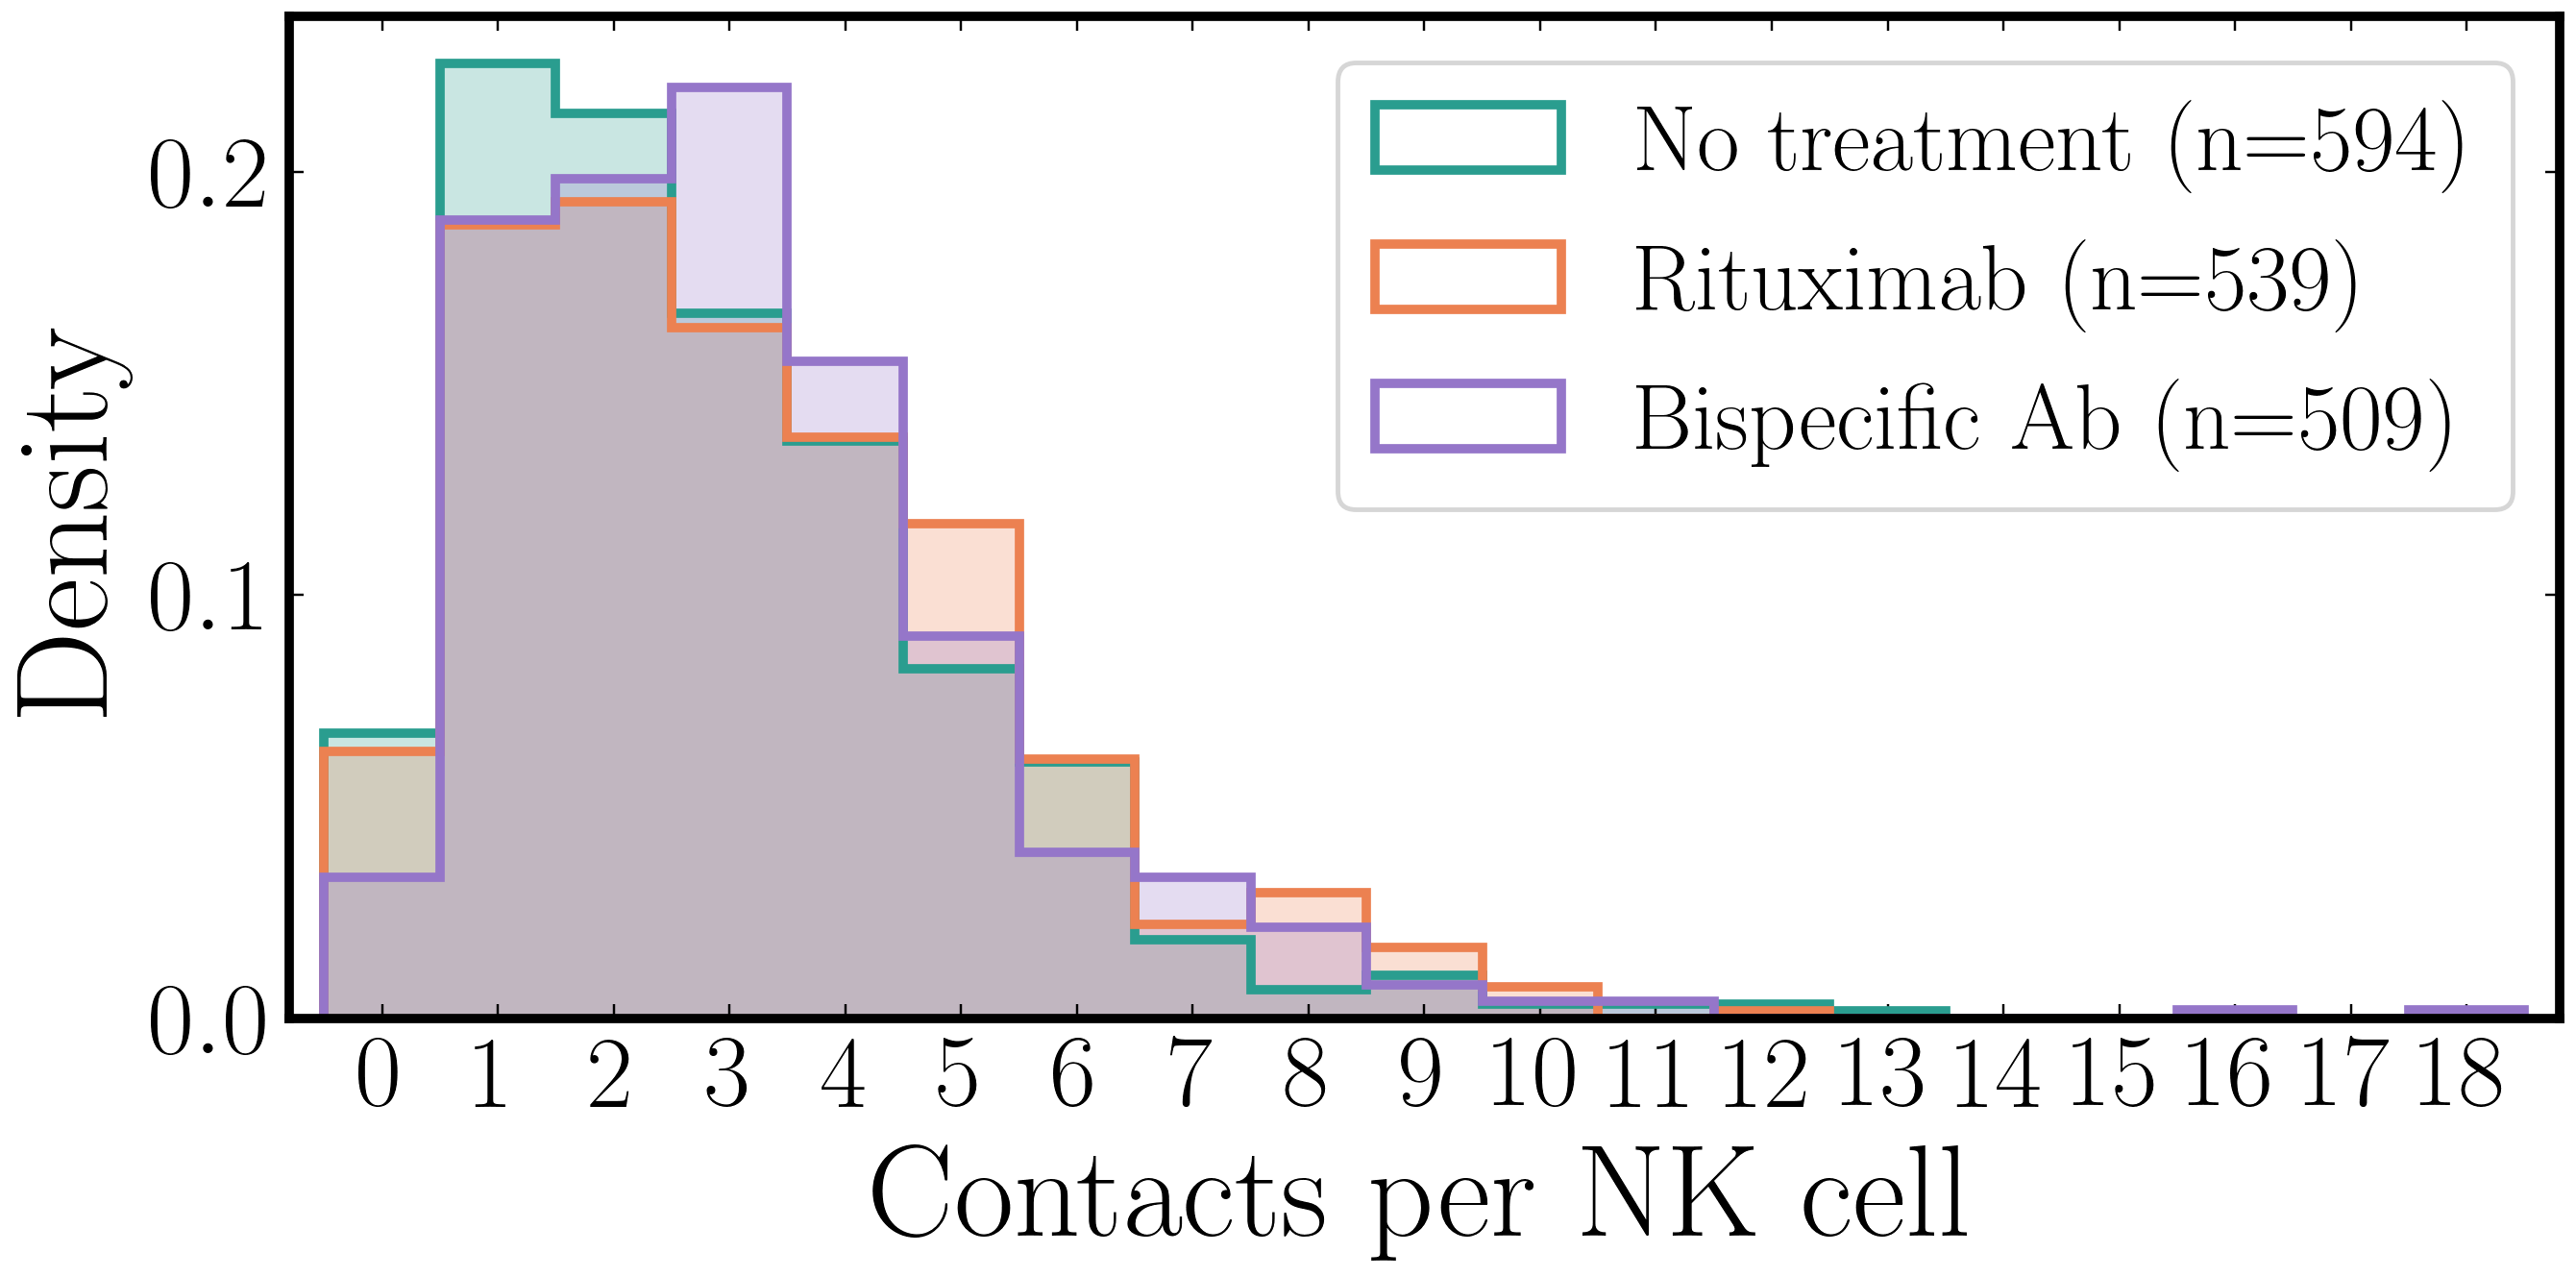

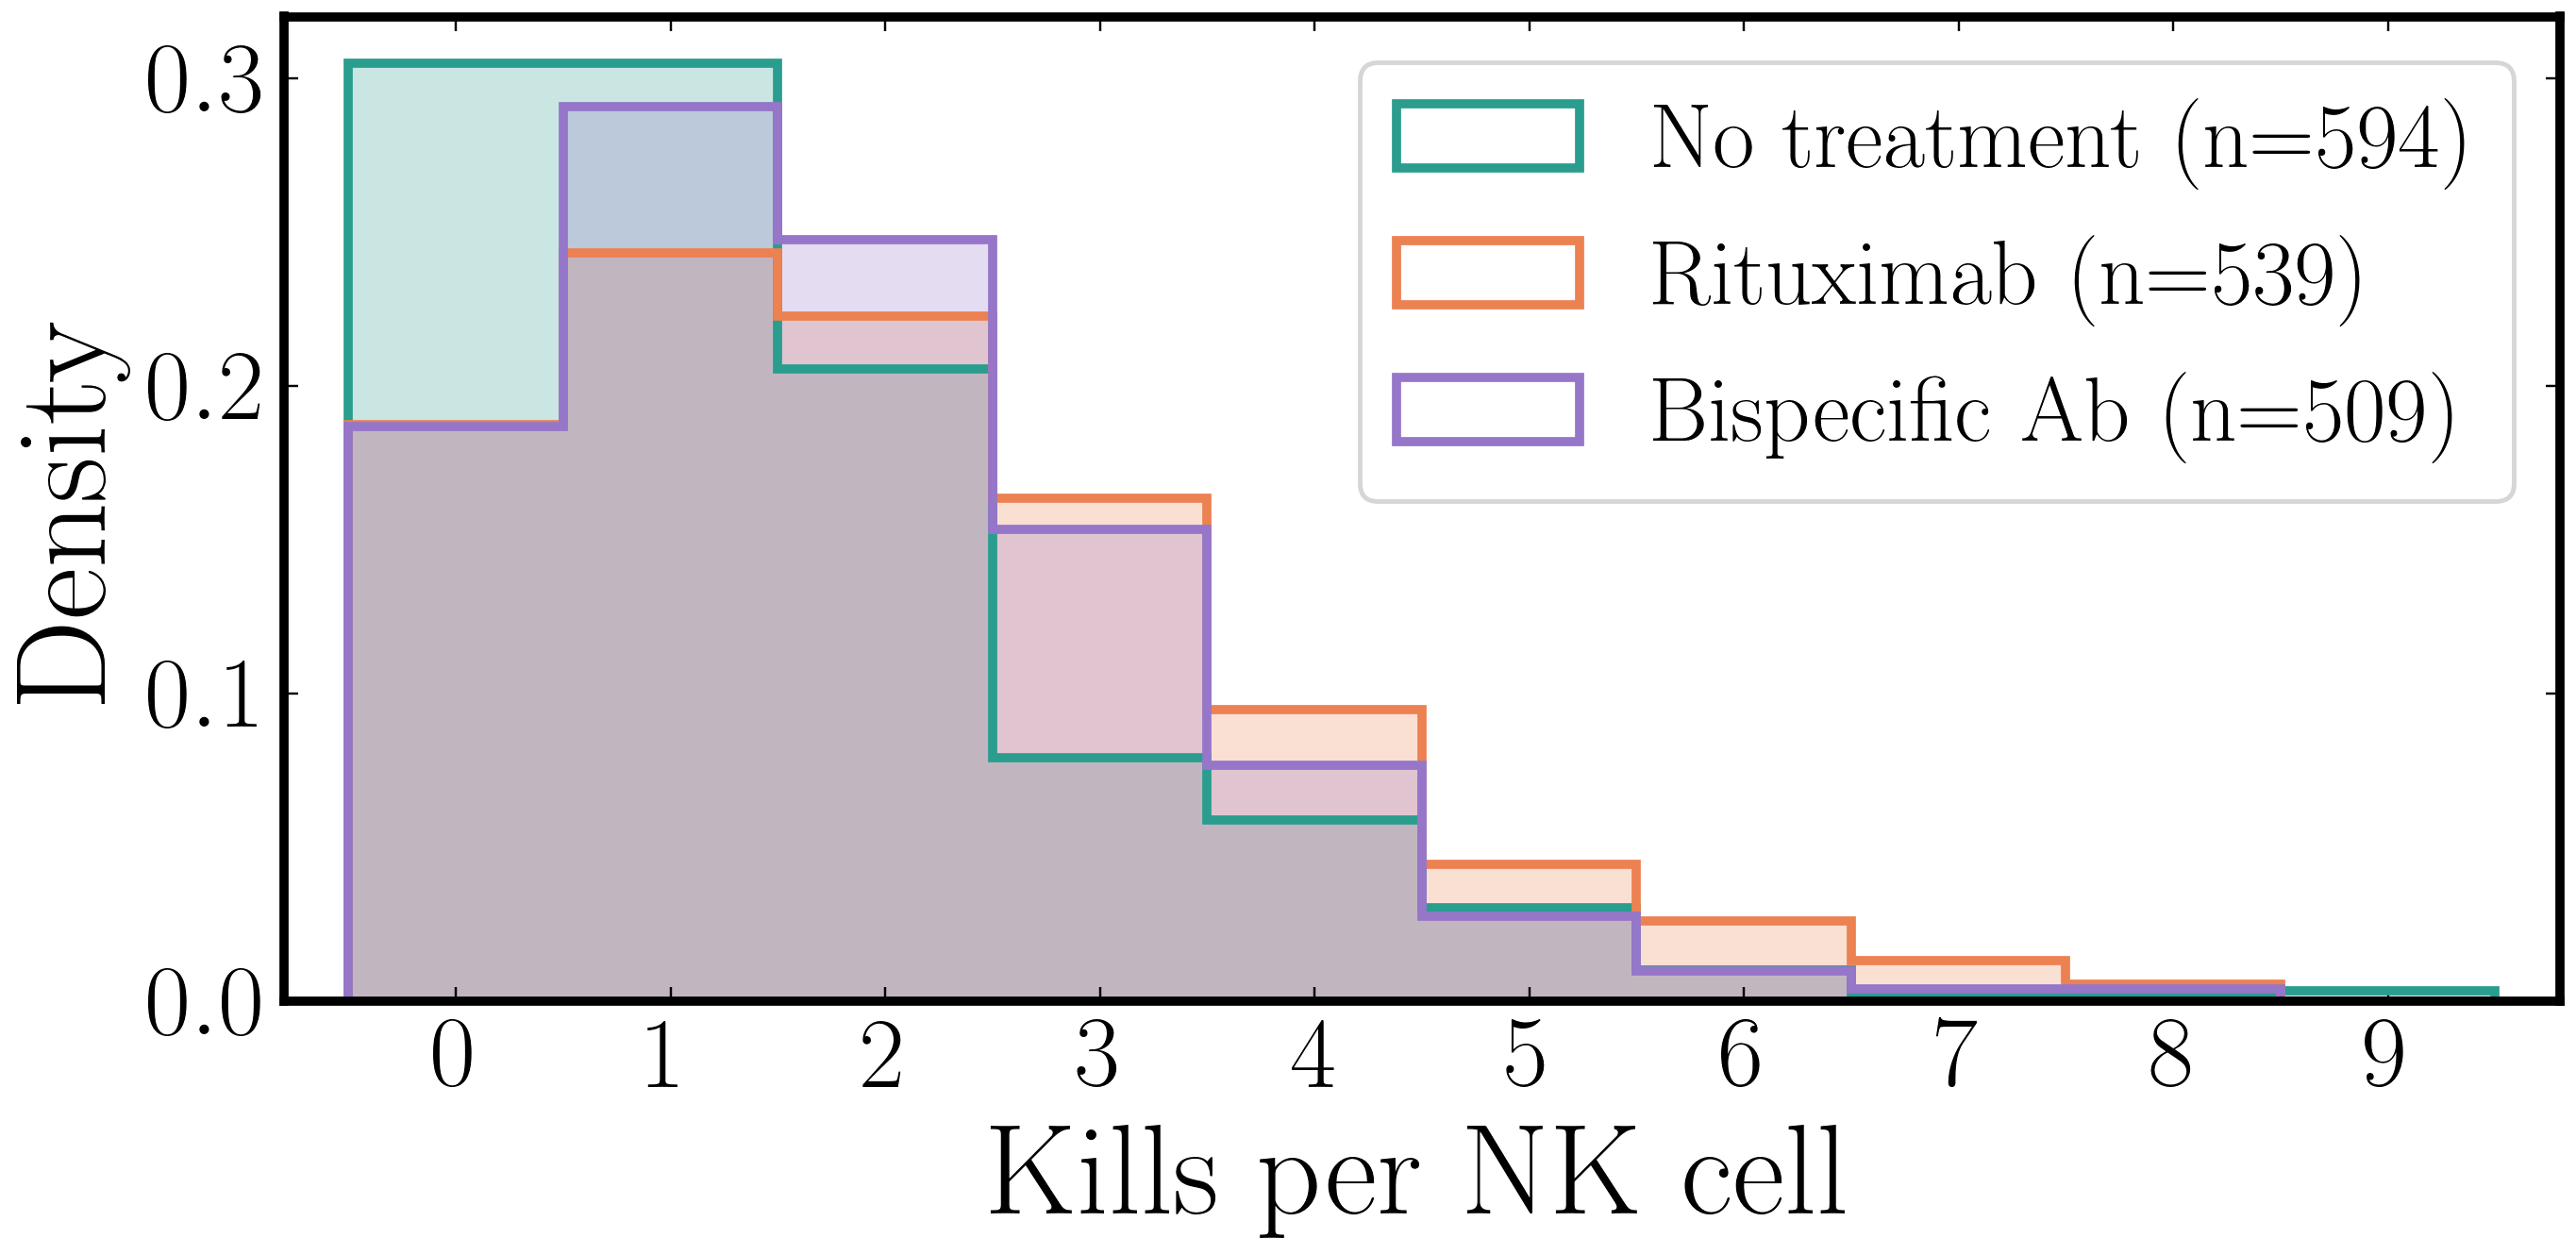

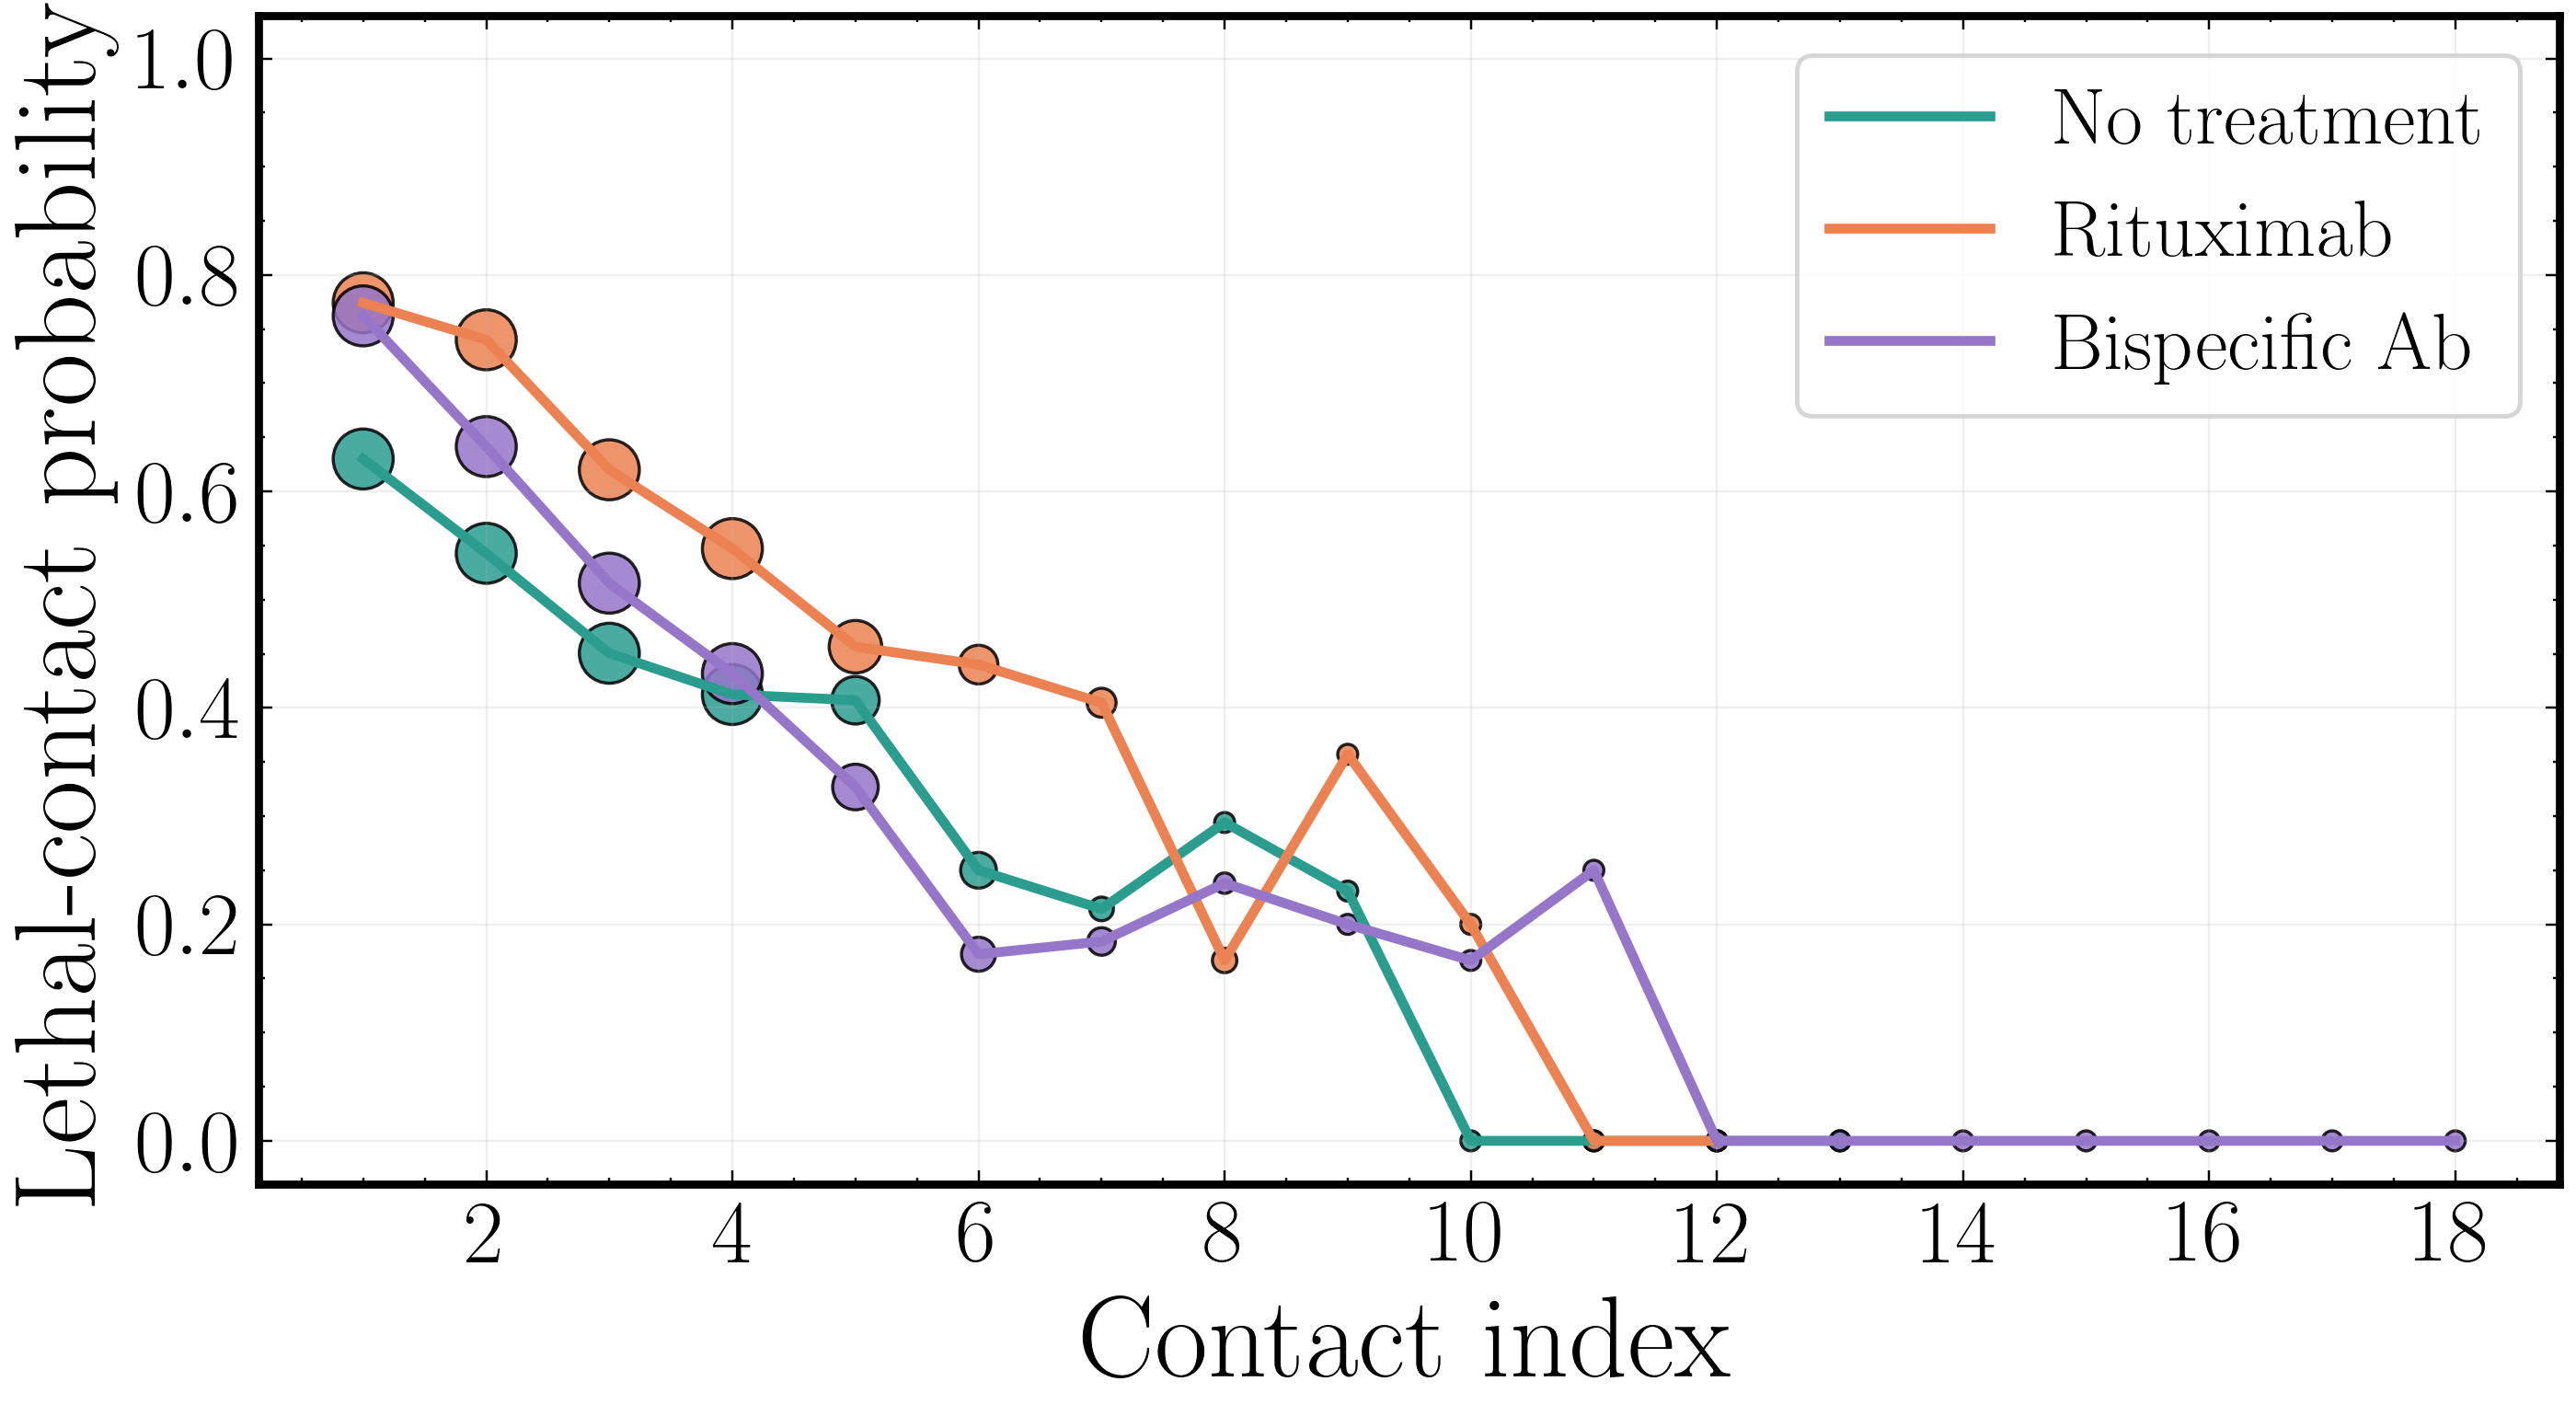

PosixPath('/Users/marsian/PhD_LifeSciRes/Orca/section_4/figures/analysis_1/lethal_probability_by_contact_index.svg')

In [5]:
plot_empirical_count_distributions(cells, show=True)
plot_lethal_probability_by_contact_index(cells, show=True)


## Decision trajectories and final-count heatmaps


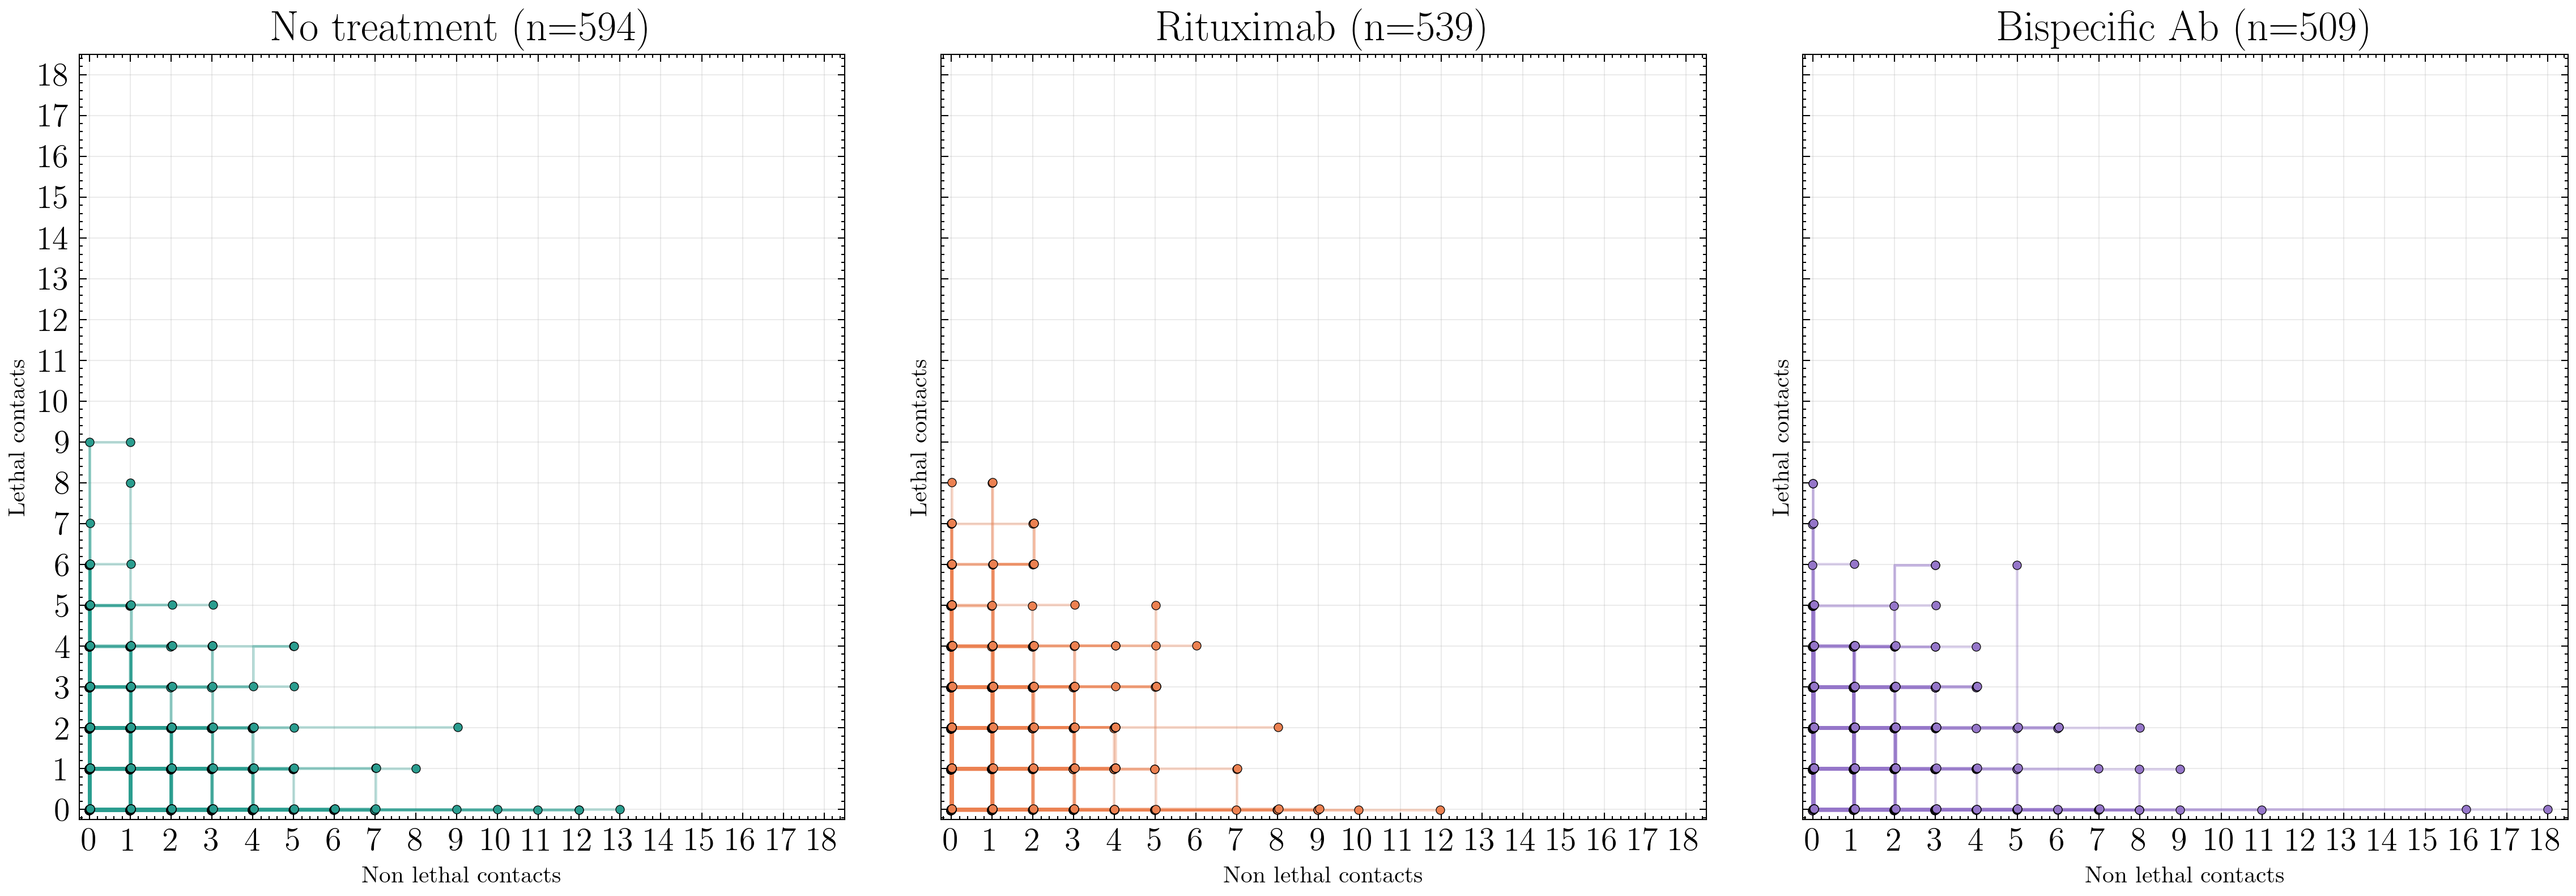

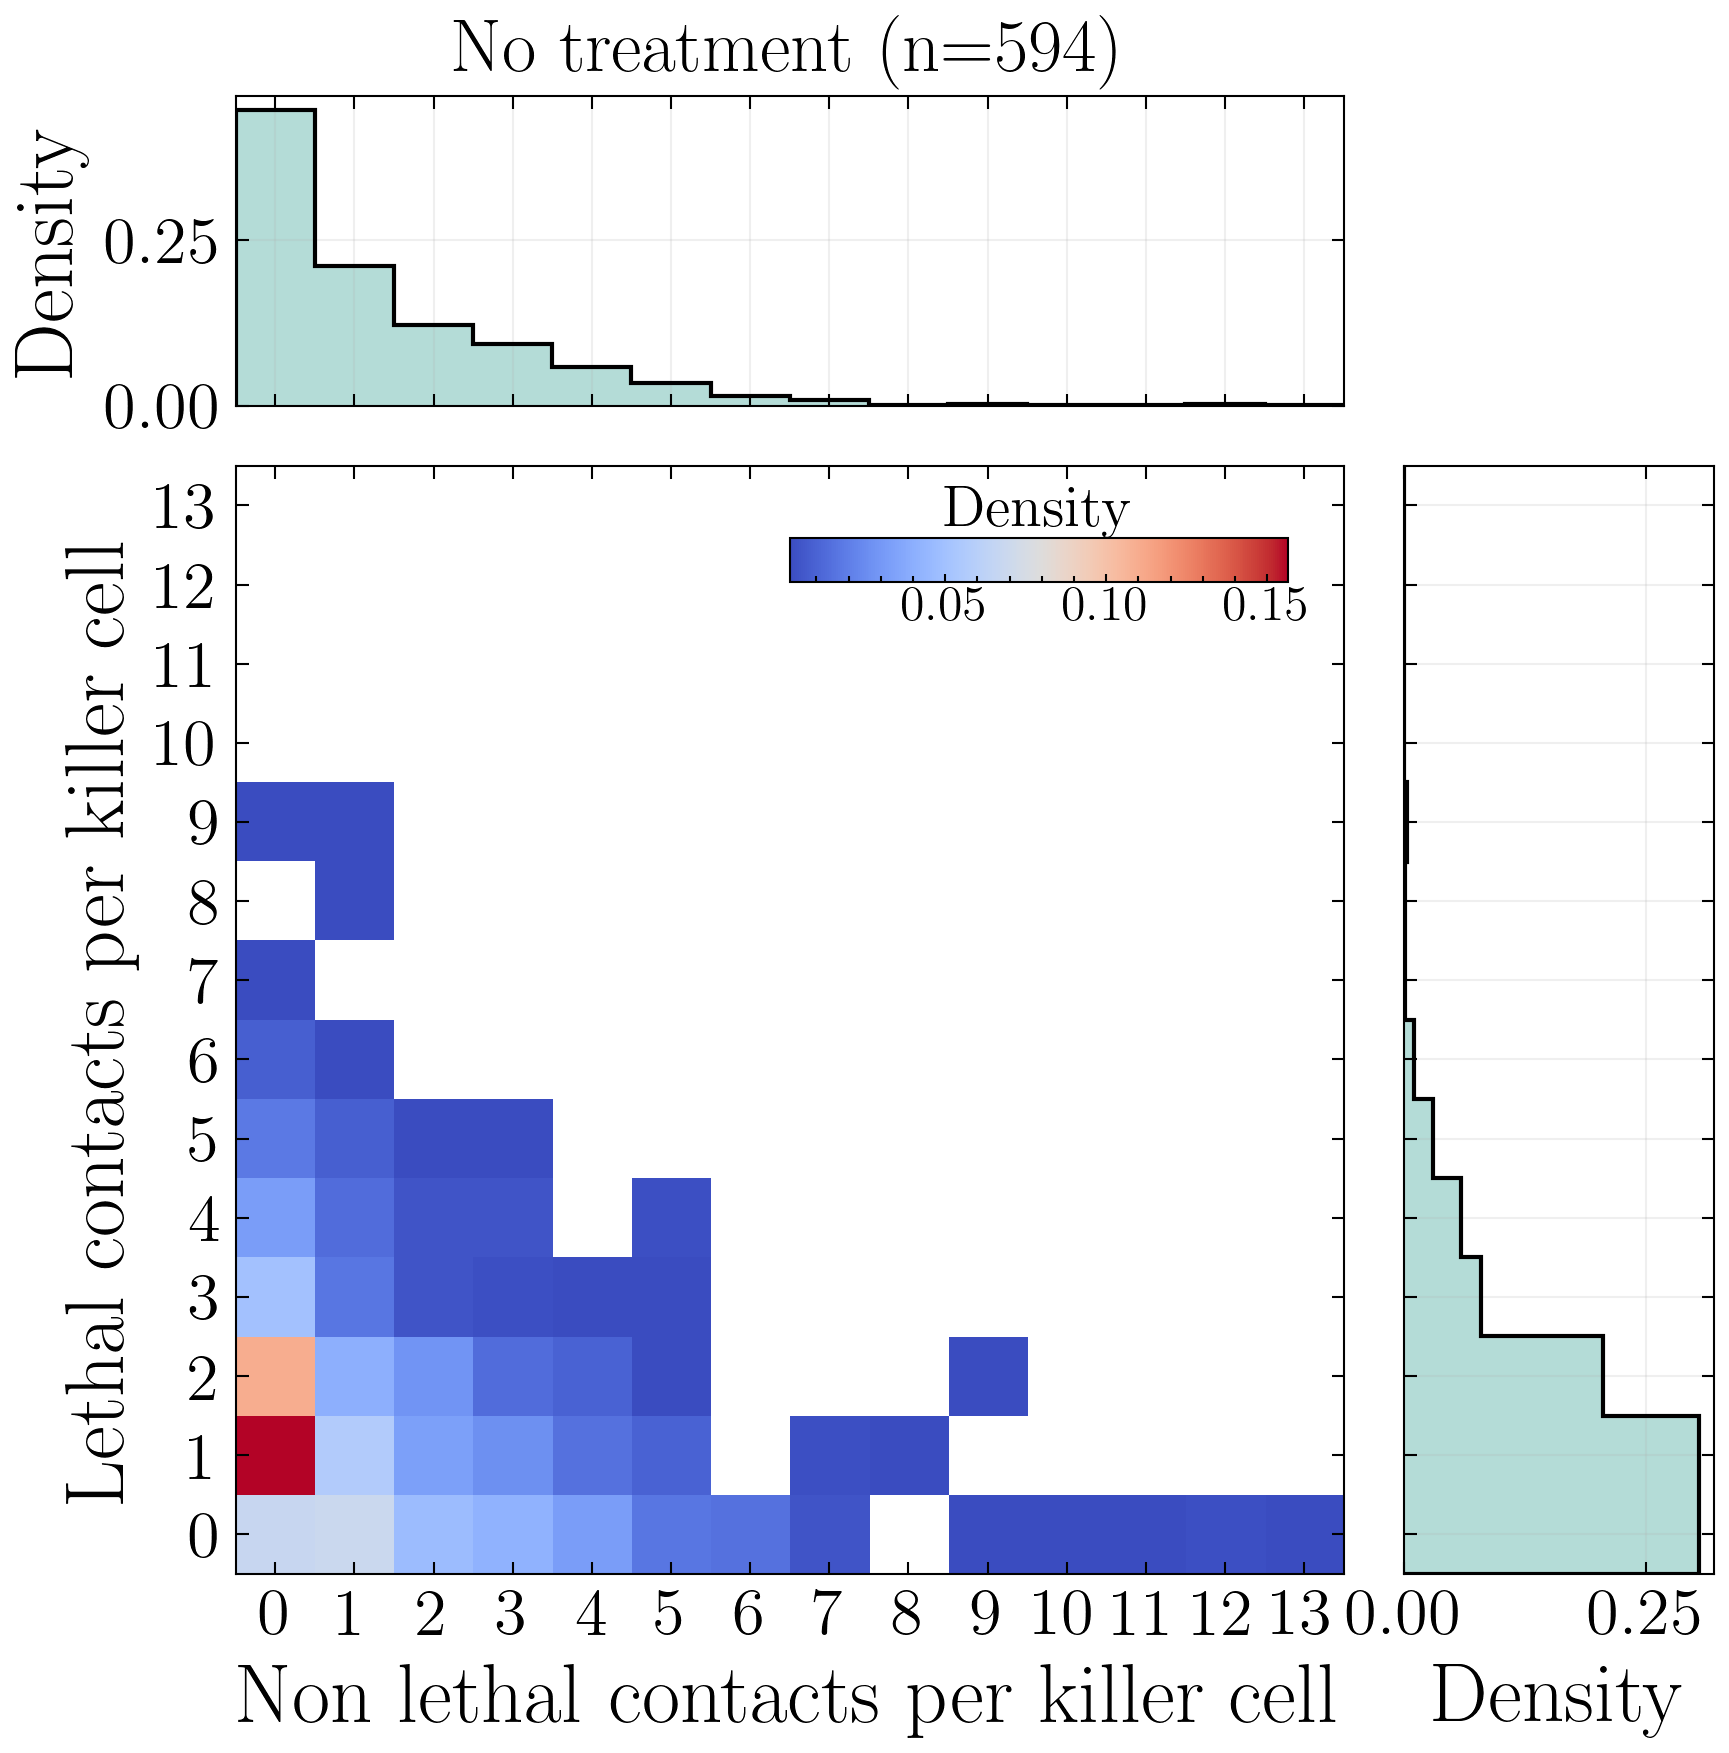

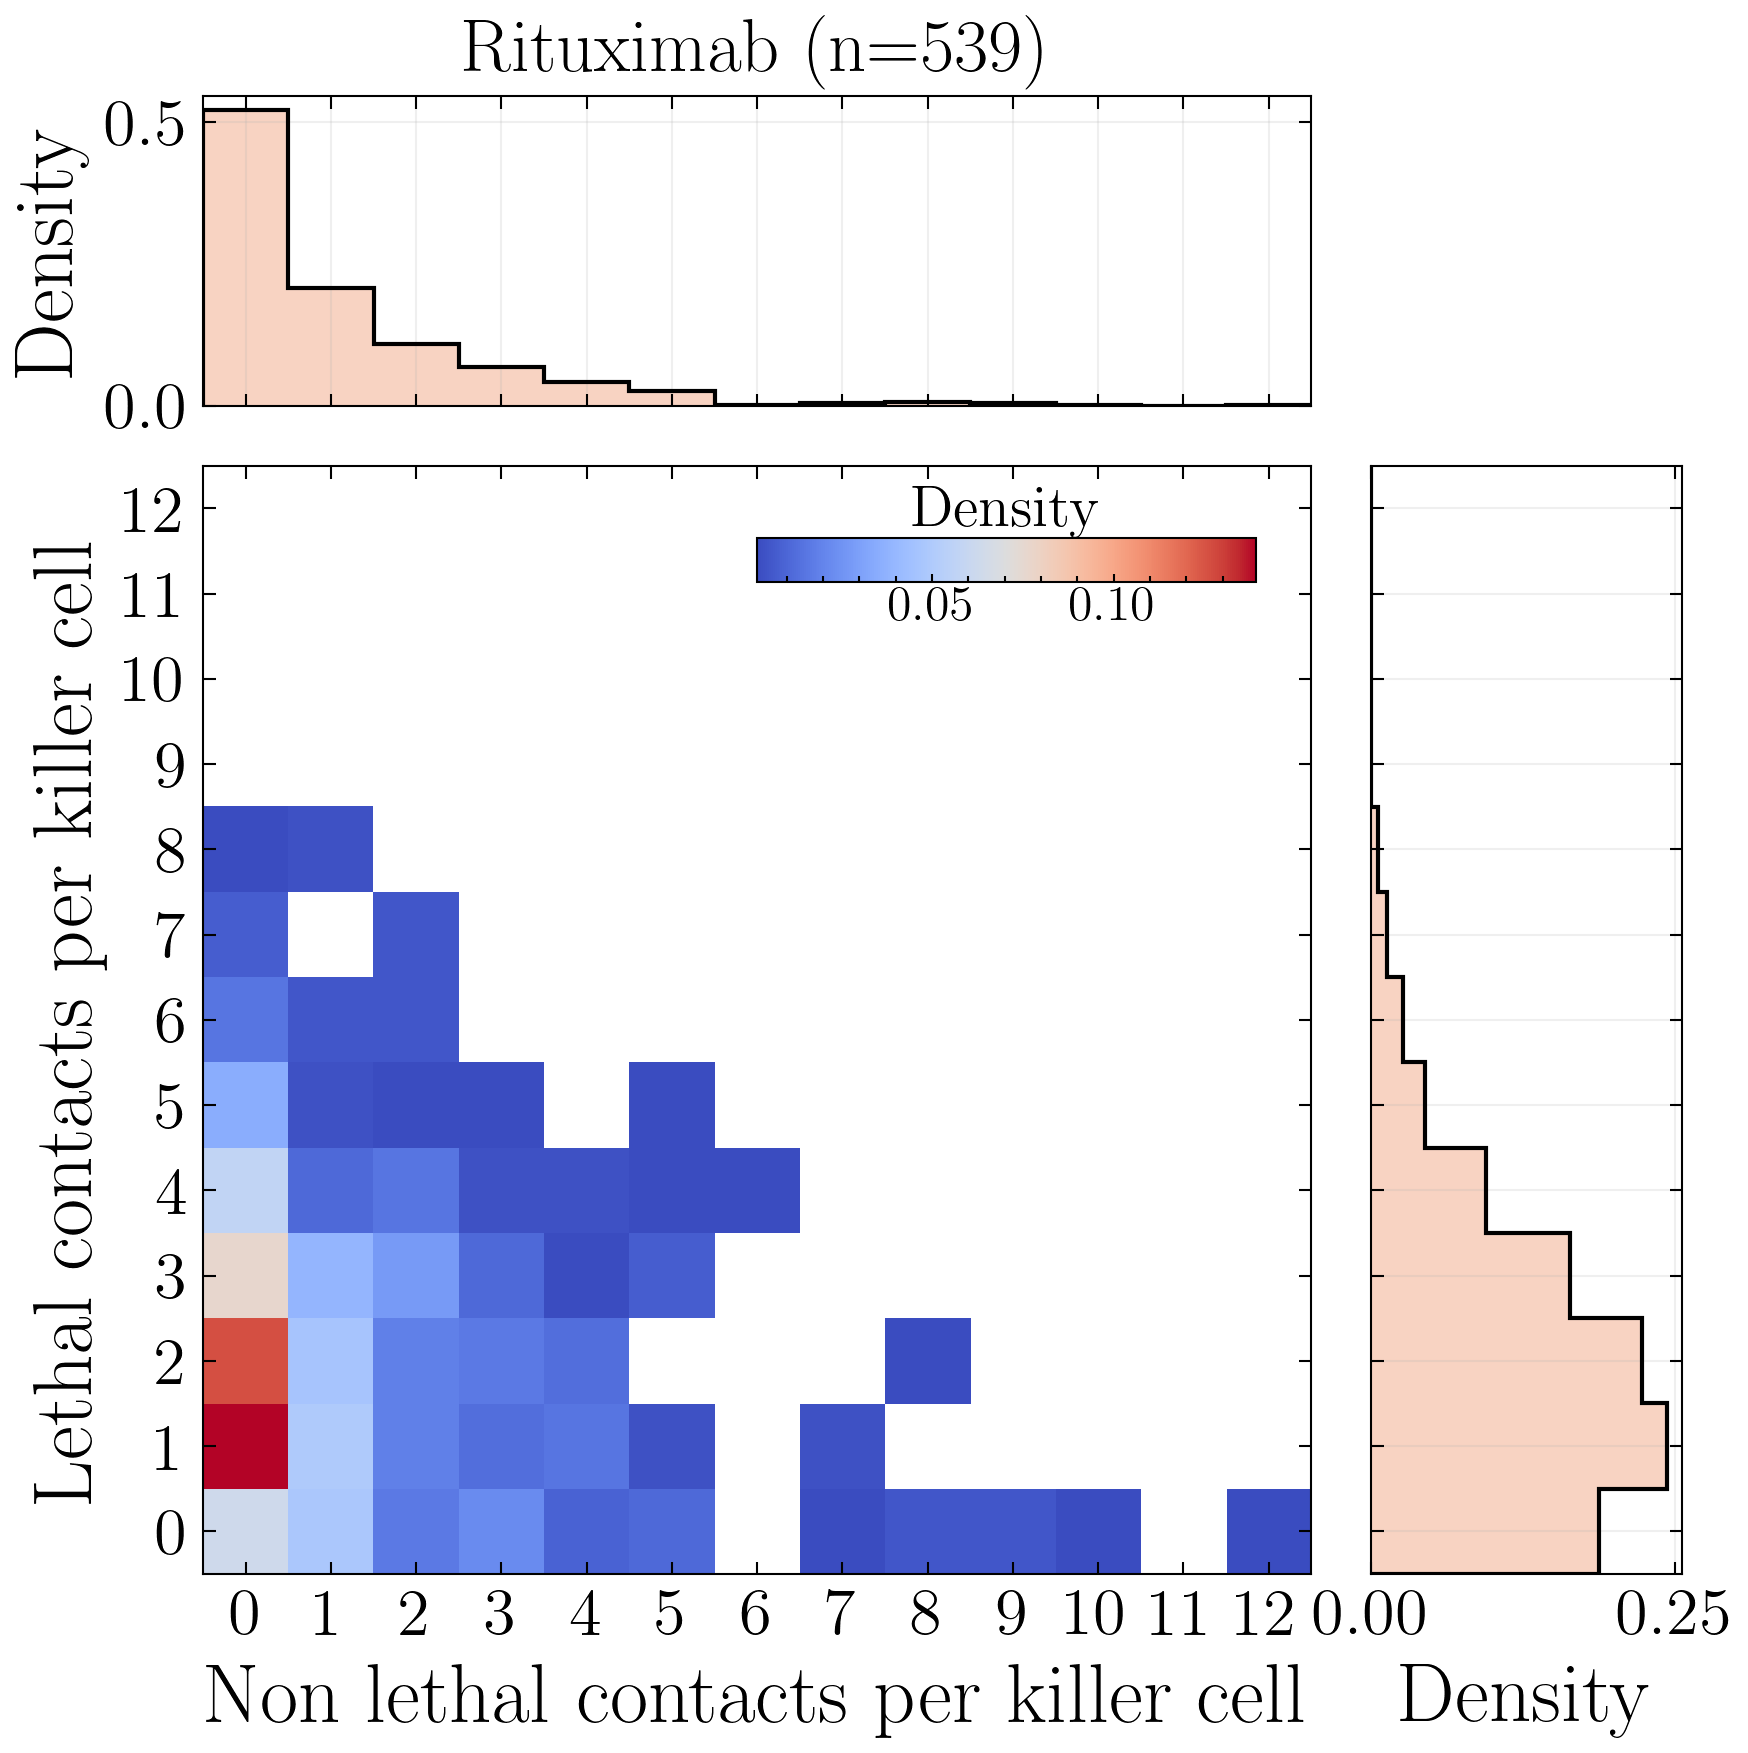

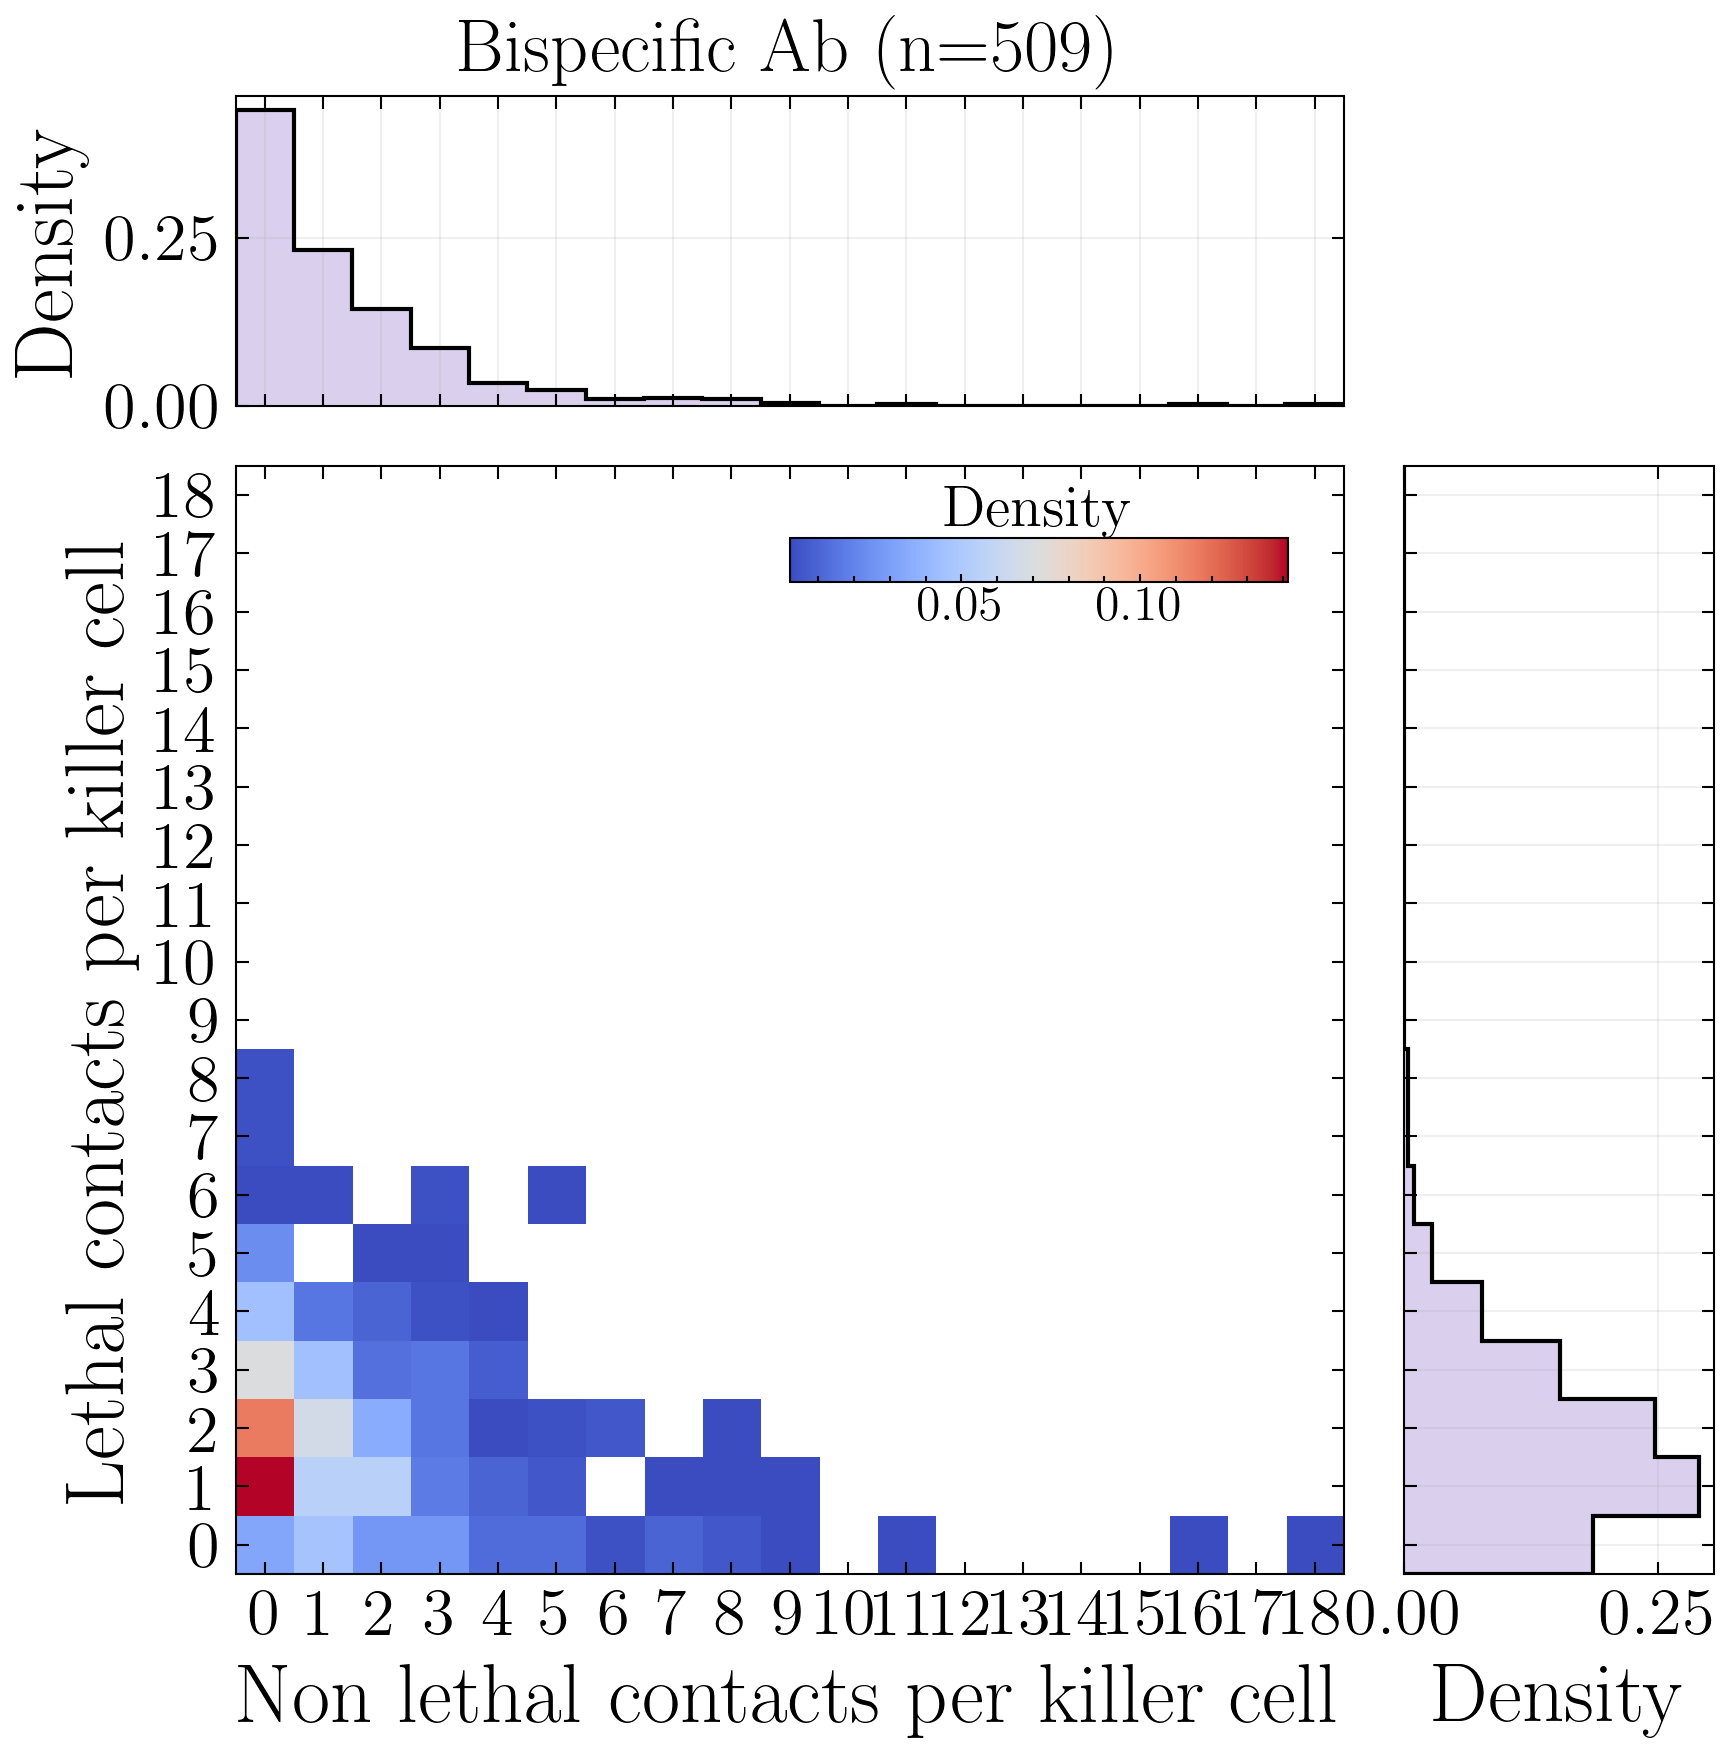

,condition,x_mean,y_mean
0,No treatment,1.425926,1.456229
1,Rituximab,1.133581,2.070501
2,Bispecific Ab,1.373281,1.807466


(PosixPath('/Users/marsian/PhD_LifeSciRes/Orca/section_4/figures/analysis_1/decision_trajectories_by_condition.svg'),
 [PosixPath('/Users/marsian/PhD_LifeSciRes/Orca/section_4/figures/analysis_1/trajectory_heatmap_no_treatment_density.svg'),
  PosixPath('/Users/marsian/PhD_LifeSciRes/Orca/section_4/figures/analysis_1/trajectory_heatmap_rituximab_density.svg'),
  PosixPath('/Users/marsian/PhD_LifeSciRes/Orca/section_4/figures/analysis_1/trajectory_heatmap_bispecific_ab_density.svg')])

In [13]:
trajectory_path = plot_decision_maps_by_condition(cells, show=True)
heatmap_paths, heatmap_stats = plot_traj_heatmaps_by_condition(cells, mode="density", show=True)

display(heatmap_stats)
trajectory_path, heatmap_paths


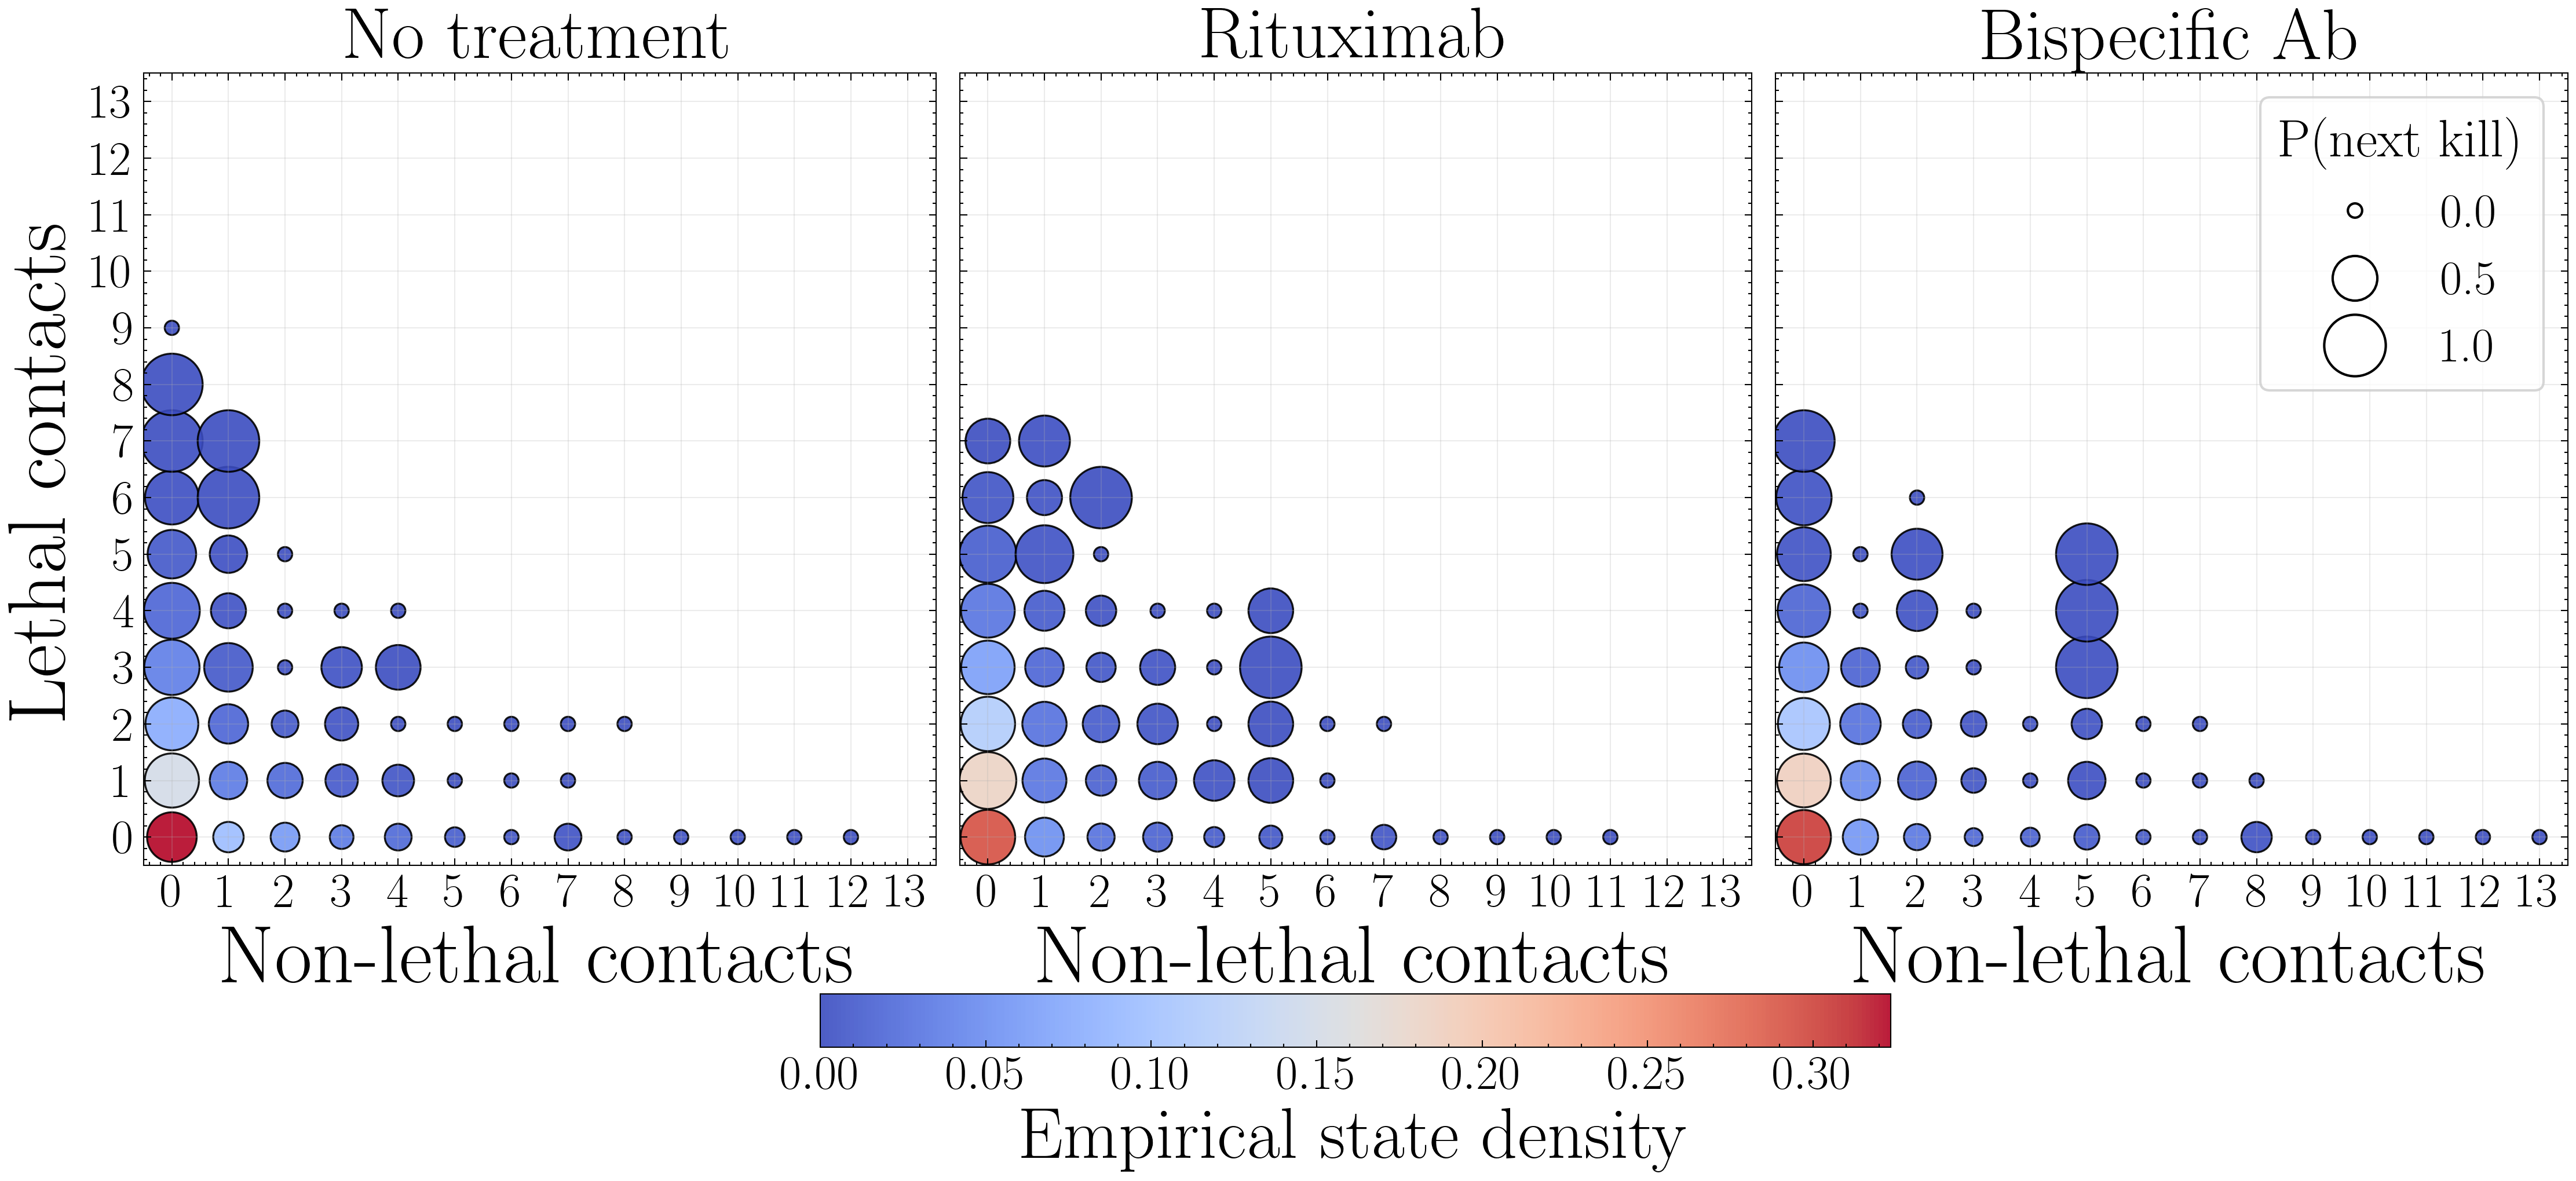

,condition_label,x_before,y_before,n,next_kill_probability,n_condition_events,state_density
0,No treatment,0,0,554,0.629964,1712,0.323598
1,No treatment,0,1,256,0.761719,1712,0.149533
2,No treatment,0,2,130,0.723077,1712,0.075935
3,No treatment,0,3,64,0.796875,1712,0.037383
4,No treatment,0,4,32,0.812500,1712,0.018692
...,...,...,...,...,...,...,...
143,Bispecific Ab,13,0,2,0.000000,1619,0.001235
144,Bispecific Ab,14,0,2,0.000000,1619,0.001235
145,Bispecific Ab,15,0,2,0.000000,1619,0.001235
146,Bispecific Ab,16,0,1,0.000000,1619,0.000618


PosixPath('/Users/marsian/PhD_LifeSciRes/Orca/section_4/figures/analysis_1/empirical_next_kill_state_maps_by_condition.svg')

In [14]:
from matplotlib.colors import Normalize


def empirical_next_kill_state_frame(
    cells: pd.DataFrame,
    *,
    conditions: Sequence[str] = CONDITION_ORDER,
) -> pd.DataFrame:
    events = event_history_frame(cells)

    if events.empty:
        return pd.DataFrame(
            columns=[
                "condition_label",
                "x_before",
                "y_before",
                "n",
                "n_condition_events",
                "state_density",
                "next_kill_probability",
            ]
        )

    events = events[events["condition_label"].isin(conditions)].copy()

    state_df = (
        events.groupby(["condition_label", "x_before", "y_before"], as_index=False)
        .agg(
            n=("z", "size"),
            next_kill_probability=("z", "mean"),
        )
    )

    totals = (
        events.groupby("condition_label")["z"]
        .size()
        .rename("n_condition_events")
        .reset_index()
    )

    state_df = state_df.merge(totals, on="condition_label", how="left")
    state_df["state_density"] = state_df["n"] / state_df["n_condition_events"]

    state_df["condition_label"] = pd.Categorical(
        state_df["condition_label"],
        categories=list(conditions),
        ordered=True,
    )

    return state_df.sort_values(["condition_label", "x_before", "y_before"]).reset_index(drop=True)


def plot_empirical_next_kill_state_maps_by_condition(
    cells: pd.DataFrame,
    *,
    conditions: Sequence[str] = CONDITION_ORDER,
    figure_root: Path = FIGURE_ROOT,
    cmap: str = "coolwarm",
    min_size: float = 35,
    max_size: float = 650,
    min_events: int = 1,
    show: bool = False,
) -> tuple[Path | None, pd.DataFrame]:
    state_df = empirical_next_kill_state_frame(cells, conditions=conditions)

    if min_events > 1:
        state_df = state_df[state_df["n"] >= min_events].copy()

    if state_df.empty:
        return None, state_df

    # max_count = int(cells["contact_count"].max()) if len(cells) else 0
    max_count = 13
    norm = Normalize(vmin=0, vmax=float(state_df["state_density"].max()))

    fig, axes = plt.subplots(
        1,
        len(conditions),
        figsize=(6 * len(conditions), 8),
        dpi=300,
        sharex=True,
        sharey=True,
        # constrained_layout=True,
        gridspec_kw={"wspace": 0.03},
    )
    axes = np.atleast_1d(axes)

    scatter = None

    for ax, condition in zip(axes, conditions):
        sub = state_df[state_df["condition_label"] == condition]

        sizes = min_size + (
            max_size - min_size
        ) * sub["next_kill_probability"].to_numpy(dtype=float)

        scatter = ax.scatter(
            sub["x_before"],
            sub["y_before"],
            c=sub["state_density"],
            s=sizes,
            cmap=cmap,
            norm=norm,
            edgecolor="black",
            linewidth=0.8,
            alpha=0.9,
        )

        n_events = int(sub["n"].sum()) if len(sub) else 0
        ax.set_title(f"{condition}", fontsize=30)
        ax.set_xlabel("Non-lethal contacts", fontsize=34)
        ax.set_xlim(-0.5, max_count + 0.5)
        ax.set_ylim(-0.5, max_count + 0.5)
        ax.set_aspect("equal")
        ax.grid(True, alpha=0.25)
        ax.tick_params(axis="both", labelsize=20)
        ax.xaxis.set_major_locator(MultipleLocator(1))
        ax.yaxis.set_major_locator(MultipleLocator(1))

    axes[0].set_ylabel("Lethal contacts", fontsize=34)

    cbar = fig.colorbar(scatter, ax=axes, orientation="horizontal", fraction=0.05, pad=0.12)
    cbar.set_label("Empirical state density", fontsize=30)
    cbar.ax.tick_params(labelsize=20)

    legend_probs = [0.0, 0.5, 1.0]
    legend_handles = [
        plt.Line2D(
            [],
            [],
            marker="o",
            linestyle="",
            markersize=np.sqrt(min_size + (max_size - min_size) * p),
            markerfacecolor="white",
            markeredgecolor="black",
            label=f"{p:.1f}",
        )
        for p in legend_probs
    ]

    axes[-1].legend(
        handles=legend_handles,
        title="P(next kill)",
        loc="upper right",
        frameon=True,
        fontsize=20,
        title_fontsize=22,
    )

    figure_root.mkdir(parents=True, exist_ok=True)
    out_path = figure_root / "empirical_next_kill_state_maps_by_condition.svg"
    fig.savefig(out_path, format="svg", bbox_inches="tight", transparent=True)

    if show:
        plt.show()
    else:
        plt.close(fig)

    return out_path, state_df


state_map_path, state_map_stats = plot_empirical_next_kill_state_maps_by_condition(
    cells,
    show=True,
)

display(state_map_stats)
state_map_path

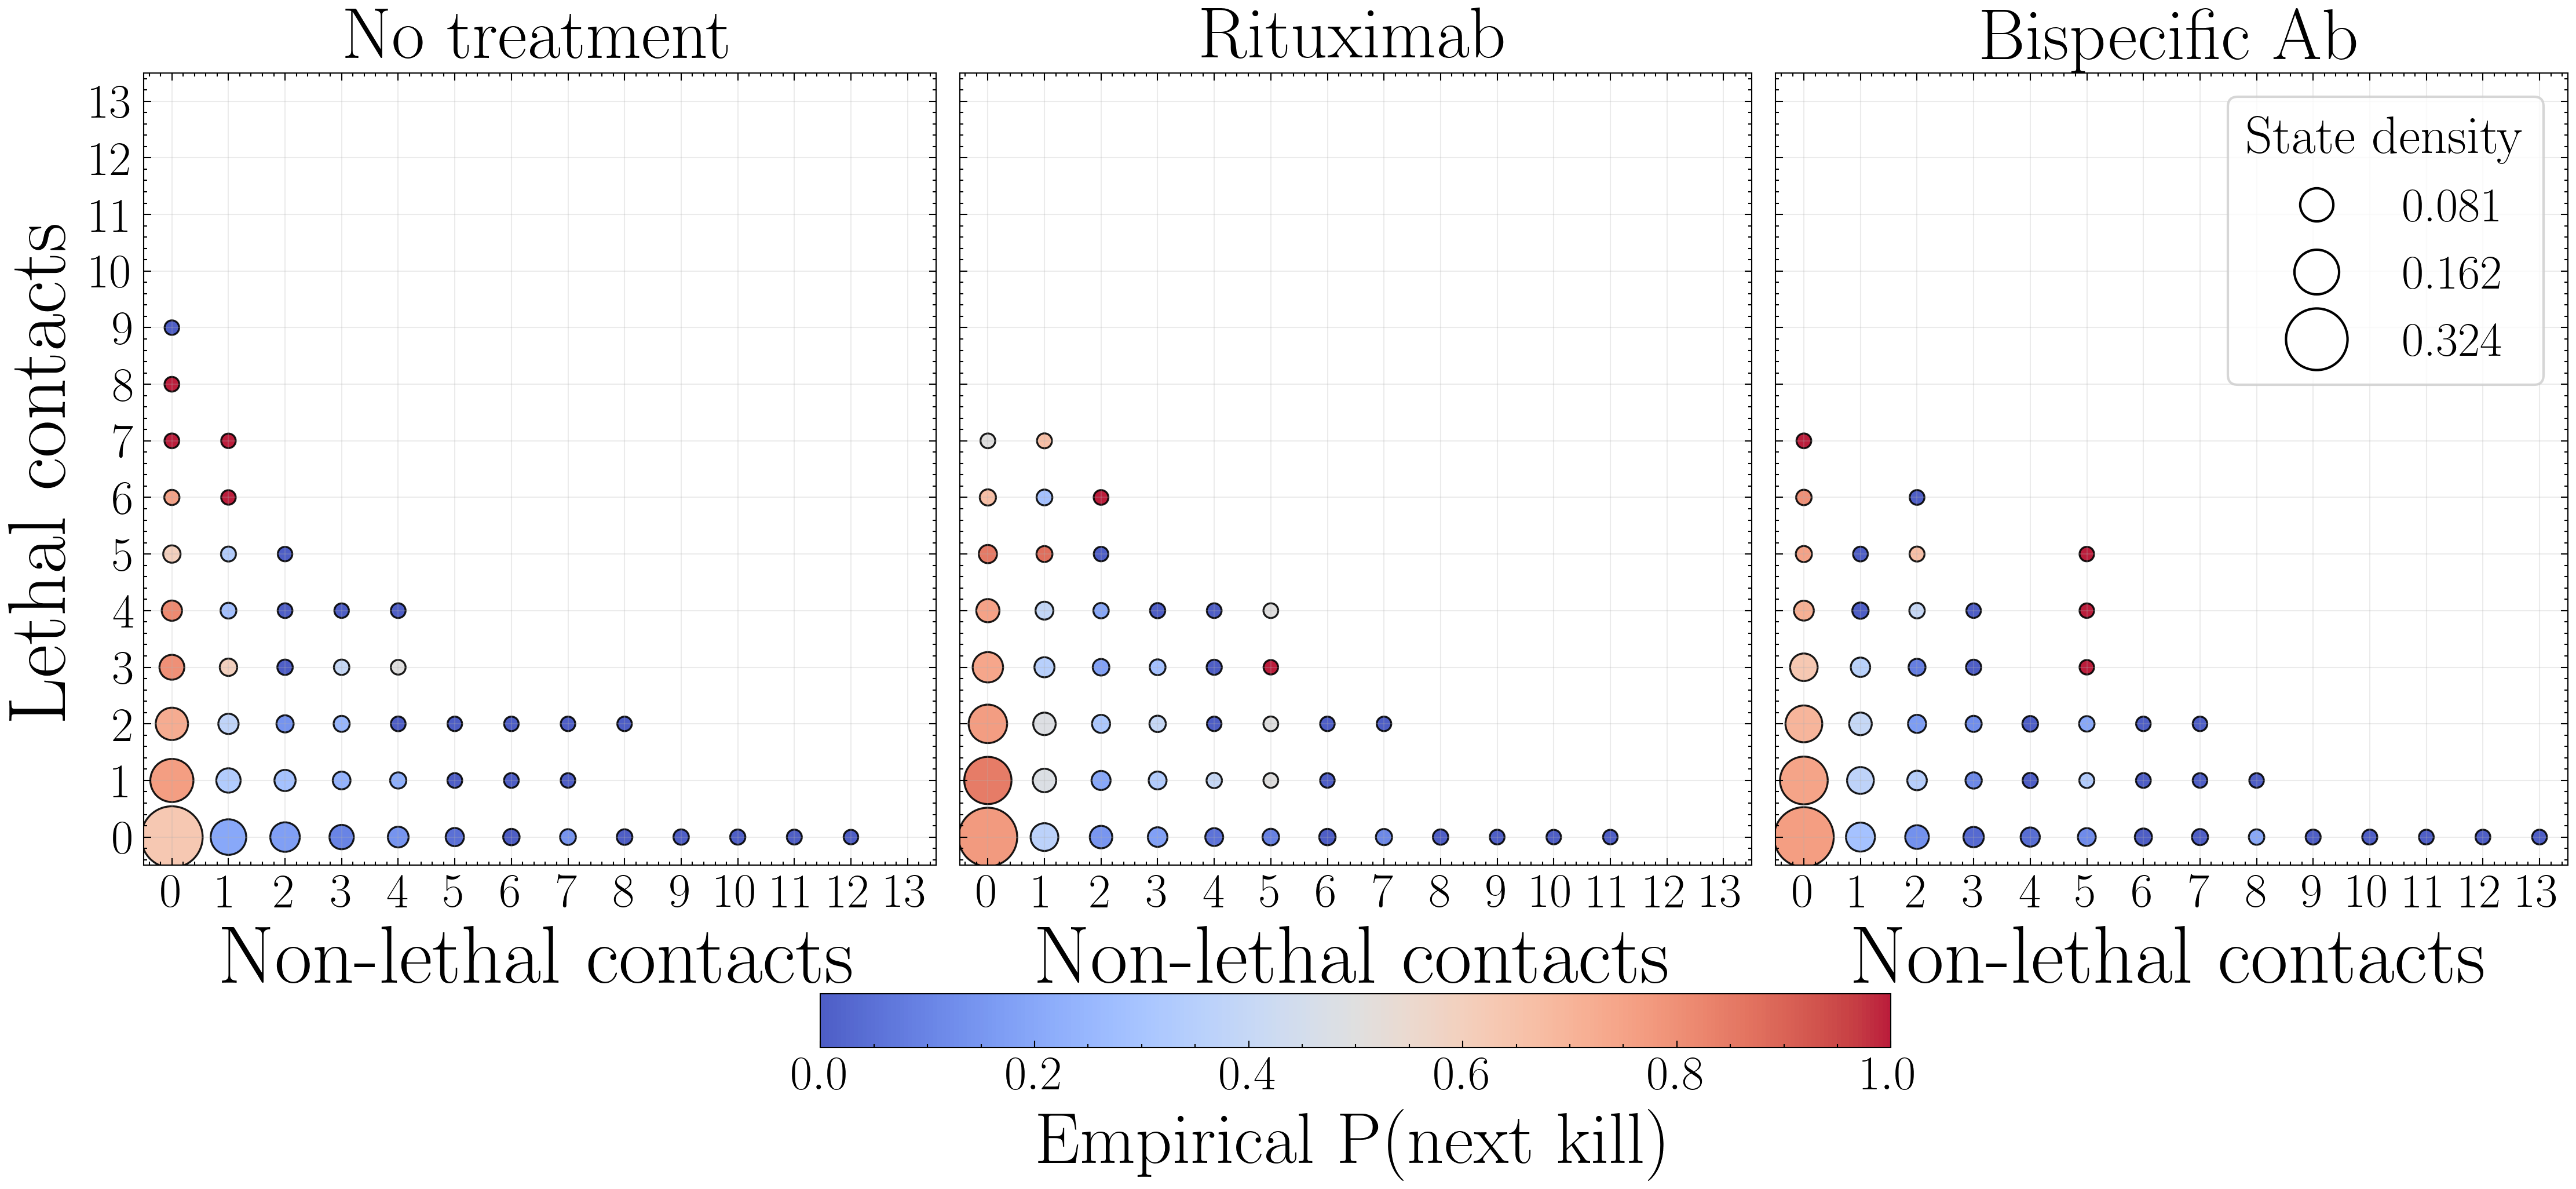

,condition_label,x_before,y_before,n,next_kill_probability,n_condition_events,state_density
0,No treatment,0,0,554,0.629964,1712,0.323598
1,No treatment,0,1,256,0.761719,1712,0.149533
2,No treatment,0,2,130,0.723077,1712,0.075935
3,No treatment,0,3,64,0.796875,1712,0.037383
4,No treatment,0,4,32,0.812500,1712,0.018692
...,...,...,...,...,...,...,...
143,Bispecific Ab,13,0,2,0.000000,1619,0.001235
144,Bispecific Ab,14,0,2,0.000000,1619,0.001235
145,Bispecific Ab,15,0,2,0.000000,1619,0.001235
146,Bispecific Ab,16,0,1,0.000000,1619,0.000618


PosixPath('/Users/marsian/PhD_LifeSciRes/Orca/section_4/figures/analysis_1/empirical_next_kill_probability_state_maps_by_condition.svg')

In [15]:
def plot_empirical_next_kill_probability_maps_by_condition(
    cells: pd.DataFrame,
    *,
    conditions: Sequence[str] = CONDITION_ORDER,
    figure_root: Path = FIGURE_ROOT,
    cmap: str = "coolwarm",
    min_size: float = 35,
    max_size: float = 650,
    min_events: int = 1,
    show: bool = False,
) -> tuple[Path | None, pd.DataFrame]:
    state_df = empirical_next_kill_state_frame(cells, conditions=conditions)

    if min_events > 1:
        state_df = state_df[state_df["n"] >= min_events].copy()

    if state_df.empty:
        return None, state_df

    max_count = 13
    max_density = float(state_df["state_density"].max())
    prob_norm = Normalize(vmin=0, vmax=1)

    fig, axes = plt.subplots(
        1,
        len(conditions),
        figsize=(6 * len(conditions), 8),
        dpi=300,
        sharex=True,
        sharey=True,
        gridspec_kw={"wspace": 0.03},
    )
    axes = np.atleast_1d(axes)

    scatter = None

    for ax, condition in zip(axes, conditions):
        sub = state_df[state_df["condition_label"] == condition]

        density_scaled = sub["state_density"].to_numpy(dtype=float) / max_density
        sizes = min_size + (max_size - min_size) * density_scaled

        scatter = ax.scatter(
            sub["x_before"],
            sub["y_before"],
            c=sub["next_kill_probability"],
            s=sizes,
            cmap=cmap,
            norm=prob_norm,
            edgecolor="black",
            linewidth=0.8,
            alpha=0.9,
        )

        ax.set_title(condition, fontsize=30)
        ax.set_xlabel("Non-lethal contacts", fontsize=34)
        ax.set_xlim(-0.5, max_count + 0.5)
        ax.set_ylim(-0.5, max_count + 0.5)
        ax.set_aspect("equal")
        ax.grid(True, alpha=0.25)
        ax.tick_params(axis="both", labelsize=20)
        ax.xaxis.set_major_locator(MultipleLocator(1))
        ax.yaxis.set_major_locator(MultipleLocator(1))

    axes[0].set_ylabel("Lethal contacts", fontsize=34)

    cbar = fig.colorbar(scatter, ax=axes, orientation="horizontal", fraction=0.05, pad=0.12)
    cbar.set_label("Empirical P(next kill)", fontsize=30)
    cbar.ax.tick_params(labelsize=20)

    legend_densities = [0.25 * max_density, 0.5 * max_density, max_density]
    legend_handles = [
        plt.Line2D(
            [],
            [],
            marker="o",
            linestyle="",
            markersize=np.sqrt(min_size + (max_size - min_size) * (d / max_density)),
            markerfacecolor="white",
            markeredgecolor="black",
            label=f"{d:.3f}",
        )
        for d in legend_densities
    ]

    axes[-1].legend(
        handles=legend_handles,
        title="State density",
        loc="upper right",
        frameon=True,
        fontsize=20,
        title_fontsize=22,
    )

    figure_root.mkdir(parents=True, exist_ok=True)
    out_path = figure_root / "empirical_next_kill_probability_state_maps_by_condition.svg"
    fig.savefig(out_path, format="svg", bbox_inches="tight", transparent=True)

    if show:
        plt.show()
    else:
        plt.close(fig)

    return out_path, state_df


prob_map_path, prob_map_stats = plot_empirical_next_kill_probability_maps_by_condition(
    cells,
    show=True,
)

display(prob_map_stats)
prob_map_path

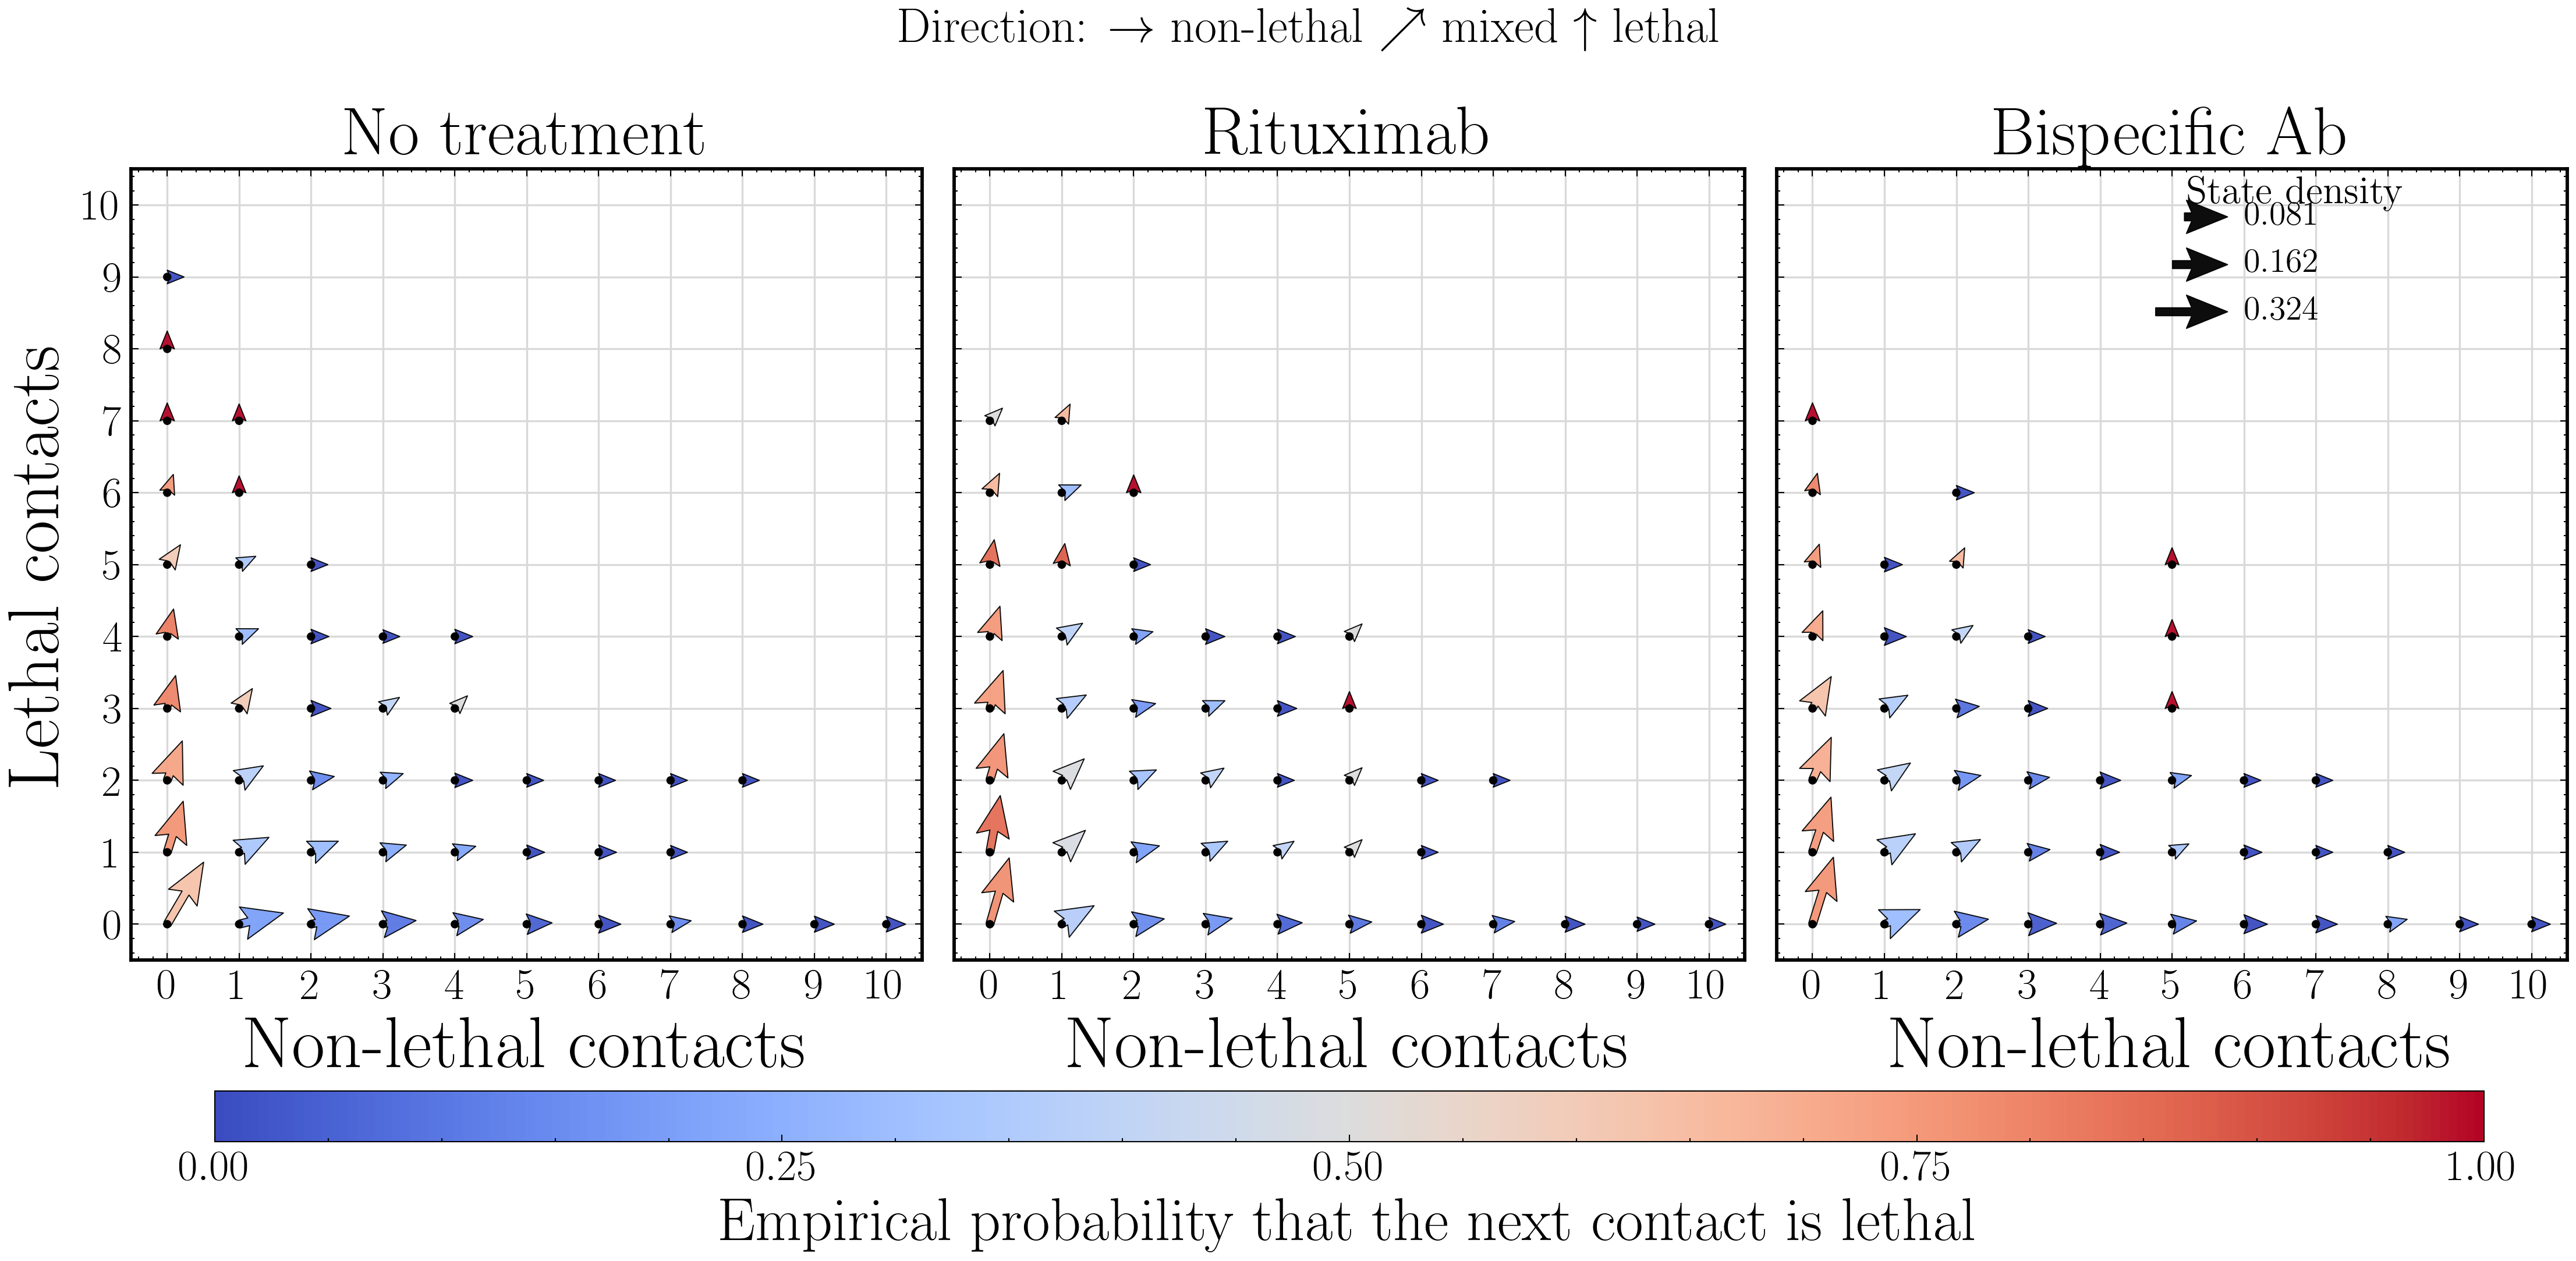

,condition_label,x_before,y_before,n,next_kill_probability,n_condition_events,state_density
0,No treatment,0,0,554,0.629964,1712,0.323598
1,No treatment,0,1,256,0.761719,1712,0.149533
2,No treatment,0,2,130,0.723077,1712,0.075935
3,No treatment,0,3,64,0.796875,1712,0.037383
4,No treatment,0,4,32,0.812500,1712,0.018692
...,...,...,...,...,...,...,...
143,Bispecific Ab,13,0,2,0.000000,1619,0.001235
144,Bispecific Ab,14,0,2,0.000000,1619,0.001235
145,Bispecific Ab,15,0,2,0.000000,1619,0.001235
146,Bispecific Ab,16,0,1,0.000000,1619,0.000618


PosixPath('/Users/marsian/PhD_LifeSciRes/Orca/section_4/figures/analysis_1/empirical_next_kill_arrow_maps_by_condition.svg')

In [20]:
from pathlib import Path
from typing import Sequence

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from matplotlib.ticker import MultipleLocator


def event_history_frame(cells: pd.DataFrame) -> pd.DataFrame:
    """Convert cell contact histories into event-level observations."""
    rows = []

    for _, row in cells.iterrows():
        x_before = 0
        y_before = 0

        for event_index, z in enumerate(row["history"], start=1):
            z = int(z)

            rows.append(
                {
                    "condition": row["condition"],
                    "condition_label": row["condition_label"],
                    "Cell": row["Cell"],
                    "event_index": event_index,
                    "x_before": x_before,
                    "y_before": y_before,
                    "z": z,
                }
            )

            if z == 1:
                y_before += 1
            else:
                x_before += 1

    return pd.DataFrame(rows)


def empirical_next_kill_state_frame(
    cells: pd.DataFrame,
    *,
    conditions: Sequence[str] = CONDITION_ORDER,
) -> pd.DataFrame:
    """Calculate density and next-kill probability for every history state."""
    events = event_history_frame(cells)

    output_columns = [
        "condition_label",
        "x_before",
        "y_before",
        "n",
        "n_condition_events",
        "state_density",
        "next_kill_probability",
    ]

    if events.empty:
        return pd.DataFrame(columns=output_columns)

    events = events[
        events["condition_label"].isin(conditions)
    ].copy()

    if events.empty:
        return pd.DataFrame(columns=output_columns)

    state_df = (
        events.groupby(
            ["condition_label", "x_before", "y_before"],
            as_index=False,
            observed=True,
        )
        .agg(
            n=("z", "size"),
            next_kill_probability=("z", "mean"),
        )
    )

    totals = (
        events.groupby(
            "condition_label",
            observed=True,
        )["z"]
        .size()
        .rename("n_condition_events")
        .reset_index()
    )

    state_df = state_df.merge(
        totals,
        on="condition_label",
        how="left",
    )

    state_df["state_density"] = (
        state_df["n"]
        / state_df["n_condition_events"]
    )

    state_df["condition_label"] = pd.Categorical(
        state_df["condition_label"],
        categories=list(conditions),
        ordered=True,
    )

    return (
        state_df.sort_values(
            ["condition_label", "x_before", "y_before"]
        )
        .reset_index(drop=True)
    )


def plot_empirical_next_kill_arrow_maps_by_condition(
    cells: pd.DataFrame,
    *,
    conditions: Sequence[str] = CONDITION_ORDER,
    figure_root: Path = FIGURE_ROOT,
    cmap: str = "coolwarm",

    # Arrow-length controls
    min_arrow_length: float = 0.12,
    max_arrow_length: float = 0.82,
    density_power: float = 0.5,

    # Arrow-thickness controls
    arrow_width: float = 0.010,
    head_width: float = 4.2,
    head_length: float = 5.2,

    # Plot controls
    min_events: int = 1,
    axis_max: float | None = 10,
    show: bool = False,
) -> tuple[Path | None, pd.DataFrame]:
    """
    Plot empirical next-event behaviour at each history state.

    Direction:
        right = next contact is likely non-lethal
        up    = next contact is likely lethal

    Length:
        empirical state density

    Colour:
        empirical probability that the next contact is lethal

    density_power:
        1.0 = linear density scaling
        <1  = makes low-density arrows more visible
        >1  = emphasizes high-density states
    """
    if min_arrow_length < 0:
        raise ValueError(
            "min_arrow_length must be non-negative."
        )

    if max_arrow_length <= min_arrow_length:
        raise ValueError(
            "max_arrow_length must be greater than "
            "min_arrow_length."
        )

    if density_power <= 0:
        raise ValueError(
            "density_power must be greater than zero."
        )

    if arrow_width <= 0:
        raise ValueError(
            "arrow_width must be greater than zero."
        )

    if min_events < 1:
        raise ValueError(
            "min_events must be at least 1."
        )

    state_df = empirical_next_kill_state_frame(
        cells,
        conditions=conditions,
    )

    if min_events > 1:
        state_df = state_df[
            state_df["n"] >= min_events
        ].copy()

    if state_df.empty:
        return None, state_df

    max_density = float(
        state_df["state_density"].max()
    )

    if not np.isfinite(max_density) or max_density <= 0:
        return None, state_df

    probability_norm = Normalize(vmin=0, vmax=1)

    if axis_max is None:
        if len(cells) and "contact_count" in cells:
            plot_max = int(cells["contact_count"].max())
        else:
            plot_max = int(
                state_df[["x_before", "y_before"]]
                .to_numpy(dtype=float)
                .max(initial=0)
            )
    else:
        plot_max = float(axis_max)

    fig, axes = plt.subplots(
        1,
        len(conditions),
        figsize=(6 * len(conditions), 7.5),
        dpi=300,
        sharex=True,
        sharey=True,
        gridspec_kw={"wspace": 0.04},
    )

    axes = np.atleast_1d(axes)
    quiver_for_key = None

    for ax, condition in zip(axes, conditions):
        sub = state_df[
            state_df["condition_label"] == condition
        ].copy()

        if not sub.empty:
            probability = sub[
                "next_kill_probability"
            ].to_numpy(dtype=float)

            density = sub[
                "state_density"
            ].to_numpy(dtype=float)

            # Scale densities between 0 and 1.
            relative_density = np.clip(
                density / max_density,
                0,
                1,
            )

            # Map density onto the requested arrow-length range.
            arrow_length = (
                min_arrow_length
                + (
                    max_arrow_length
                    - min_arrow_length
                )
                * relative_density**density_power
            )

            # Expected next-step direction.
            horizontal = 1.0 - probability
            vertical = probability

            # Prevent probability from changing total arrow length.
            direction_norm = np.hypot(
                horizontal,
                vertical,
            )

            horizontal = horizontal / direction_norm
            vertical = vertical / direction_norm

            u = arrow_length * horizontal
            v = arrow_length * vertical

            quiver = ax.quiver(
                sub["x_before"].to_numpy(dtype=float),
                sub["y_before"].to_numpy(dtype=float),
                u,
                v,
                probability,
                cmap=cmap,
                norm=probability_norm,
                angles="xy",
                scale_units="xy",
                scale=1,
                pivot="tail",
                width=arrow_width,
                headwidth=head_width,
                headlength=head_length,
                headaxislength=head_length * 0.87,
                edgecolor="black",
                linewidth=0.45,
                alpha=0.95,
                zorder=3,
            )

            quiver_for_key = quiver

            # Show the exact state from which the arrow begins.
            ax.scatter(
                sub["x_before"],
                sub["y_before"],
                s=12,
                facecolor="black",
                edgecolor="none",
                zorder=4,
            )

        ax.set_title(
            condition,
            fontsize=28,
        )

        ax.set_xlabel(
            "Non-lethal contacts",
            fontsize=30,
        )

        ax.set_xlim(-0.5, plot_max + 0.5)
        ax.set_ylim(-0.5, plot_max + 0.5)
        ax.set_aspect("equal")

        ax.xaxis.set_major_locator(
            MultipleLocator(1)
        )
        ax.yaxis.set_major_locator(
            MultipleLocator(1)
        )

        ax.tick_params(
            axis="both",
            labelsize=18,
        )

        ax.grid(
            True,
            color="0.85",
            linewidth=0.8,
            zorder=0,
        )

        for spine in ax.spines.values():
            spine.set_linewidth(1.4)

    axes[0].set_ylabel(
        "Lethal contacts",
        fontsize=30,
    )

    # LaTeX-compatible direction guide.
    fig.text(
        0.5,
        0.975,
        (
            r"Direction: $\rightarrow$ non-lethal"
            r"     $\nearrow$ mixed"
            r"     $\uparrow$ lethal"
        ),
        ha="center",
        va="top",
        fontsize=20,
    )

    # Killing-probability colour bar.
    colorbar_mappable = ScalarMappable(
        norm=probability_norm,
        cmap=cmap,
    )
    colorbar_mappable.set_array([])

    cbar = fig.colorbar(
        colorbar_mappable,
        ax=axes,
        orientation="horizontal",
        fraction=0.05,
        pad=0.13,
        aspect=45,
    )

    cbar.set_label(
        "Empirical probability that the next contact is lethal",
        fontsize=25,
    )

    cbar.set_ticks(
        [0, 0.25, 0.5, 0.75, 1]
    )

    cbar.ax.tick_params(
        labelsize=18,
    )

    # Arrow-length legend.
    if quiver_for_key is not None:
        key_fractions = [0.25, 0.50, 1.00]
        key_y_positions = [0.94, 0.88, 0.82]

        axes[-1].text(
            0.52,
            0.99,
            "State density",
            transform=axes[-1].transAxes,
            fontsize=16,
            ha="left",
            va="top",
        )

        for fraction, y_position in zip(
            key_fractions,
            key_y_positions,
        ):
            density_value = fraction * max_density

            key_length = (
                min_arrow_length
                + (
                    max_arrow_length
                    - min_arrow_length
                )
                * fraction**density_power
            )

            axes[-1].quiverkey(
                quiver_for_key,
                X=0.57,
                Y=y_position,
                U=key_length,
                label=f"{density_value:.3f}",
                labelpos="E",
                coordinates="axes",
                color="black",
                fontproperties={"size": 14},
            )

    figure_root = Path(figure_root)
    figure_root.mkdir(
        parents=True,
        exist_ok=True,
    )

    out_path = (
        figure_root
        / "empirical_next_kill_arrow_maps_by_condition.svg"
    )

    fig.savefig(
        out_path,
        format="svg",
        bbox_inches="tight",
        transparent=True,
    )

    if show:
        plt.show()
    else:
        plt.close(fig)

    return out_path, state_df

plt.close("all")

arrow_map_path, arrow_map_stats = (
    plot_empirical_next_kill_arrow_maps_by_condition(
        cells,
        min_arrow_length=0.2,
        max_arrow_length=1,
        density_power=0.5,
        arrow_width=0.010,
        head_width=4.2,
        head_length=5.2,
        min_events=1,
        axis_max=10,
        show=True,
    )
)

display(arrow_map_stats)
arrow_map_path

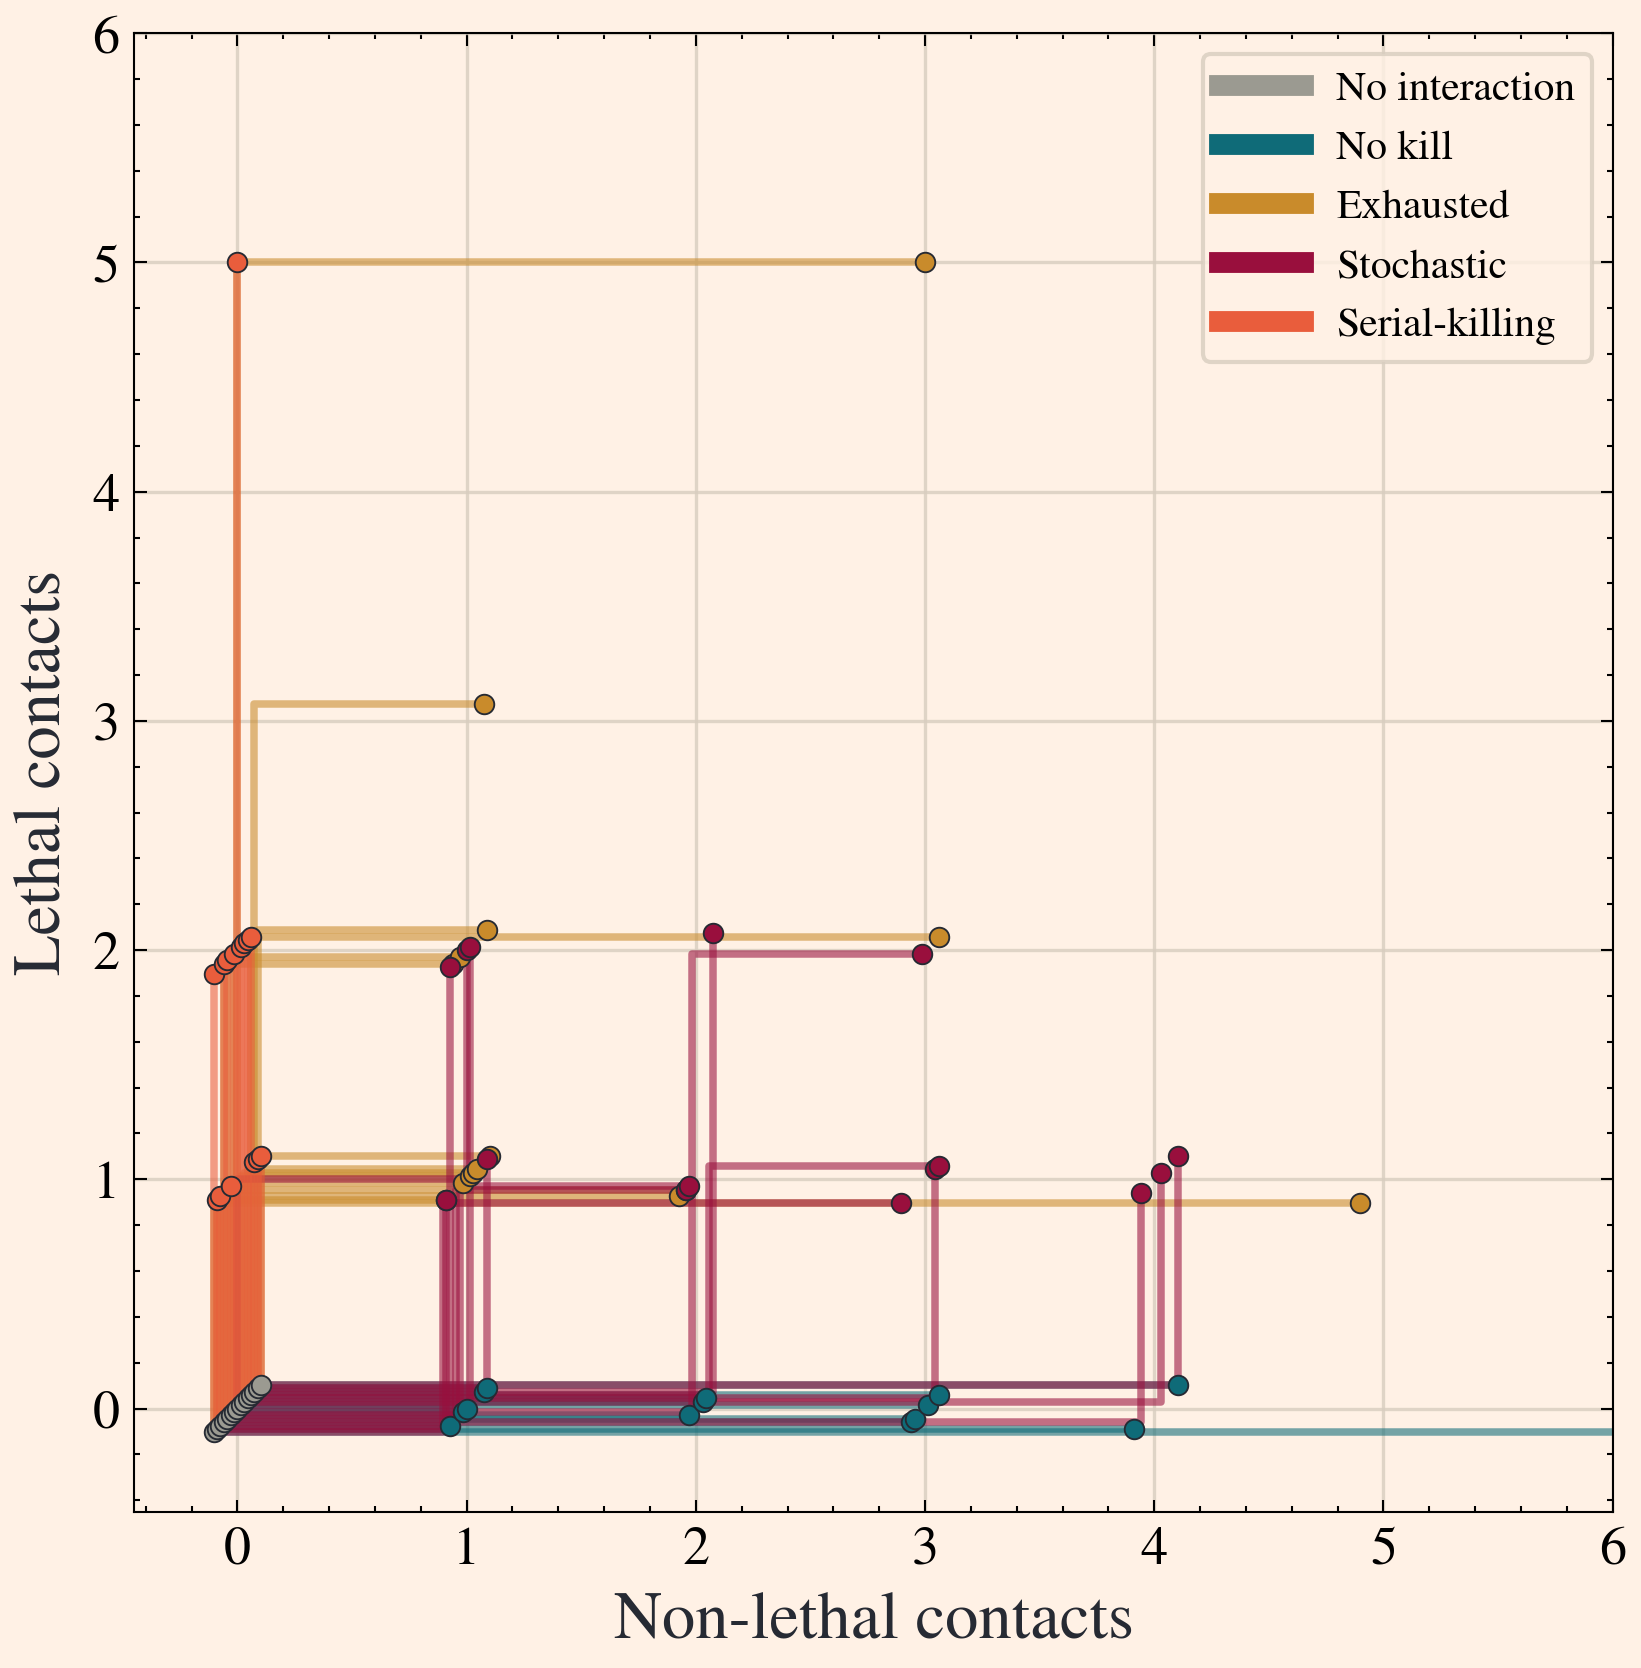

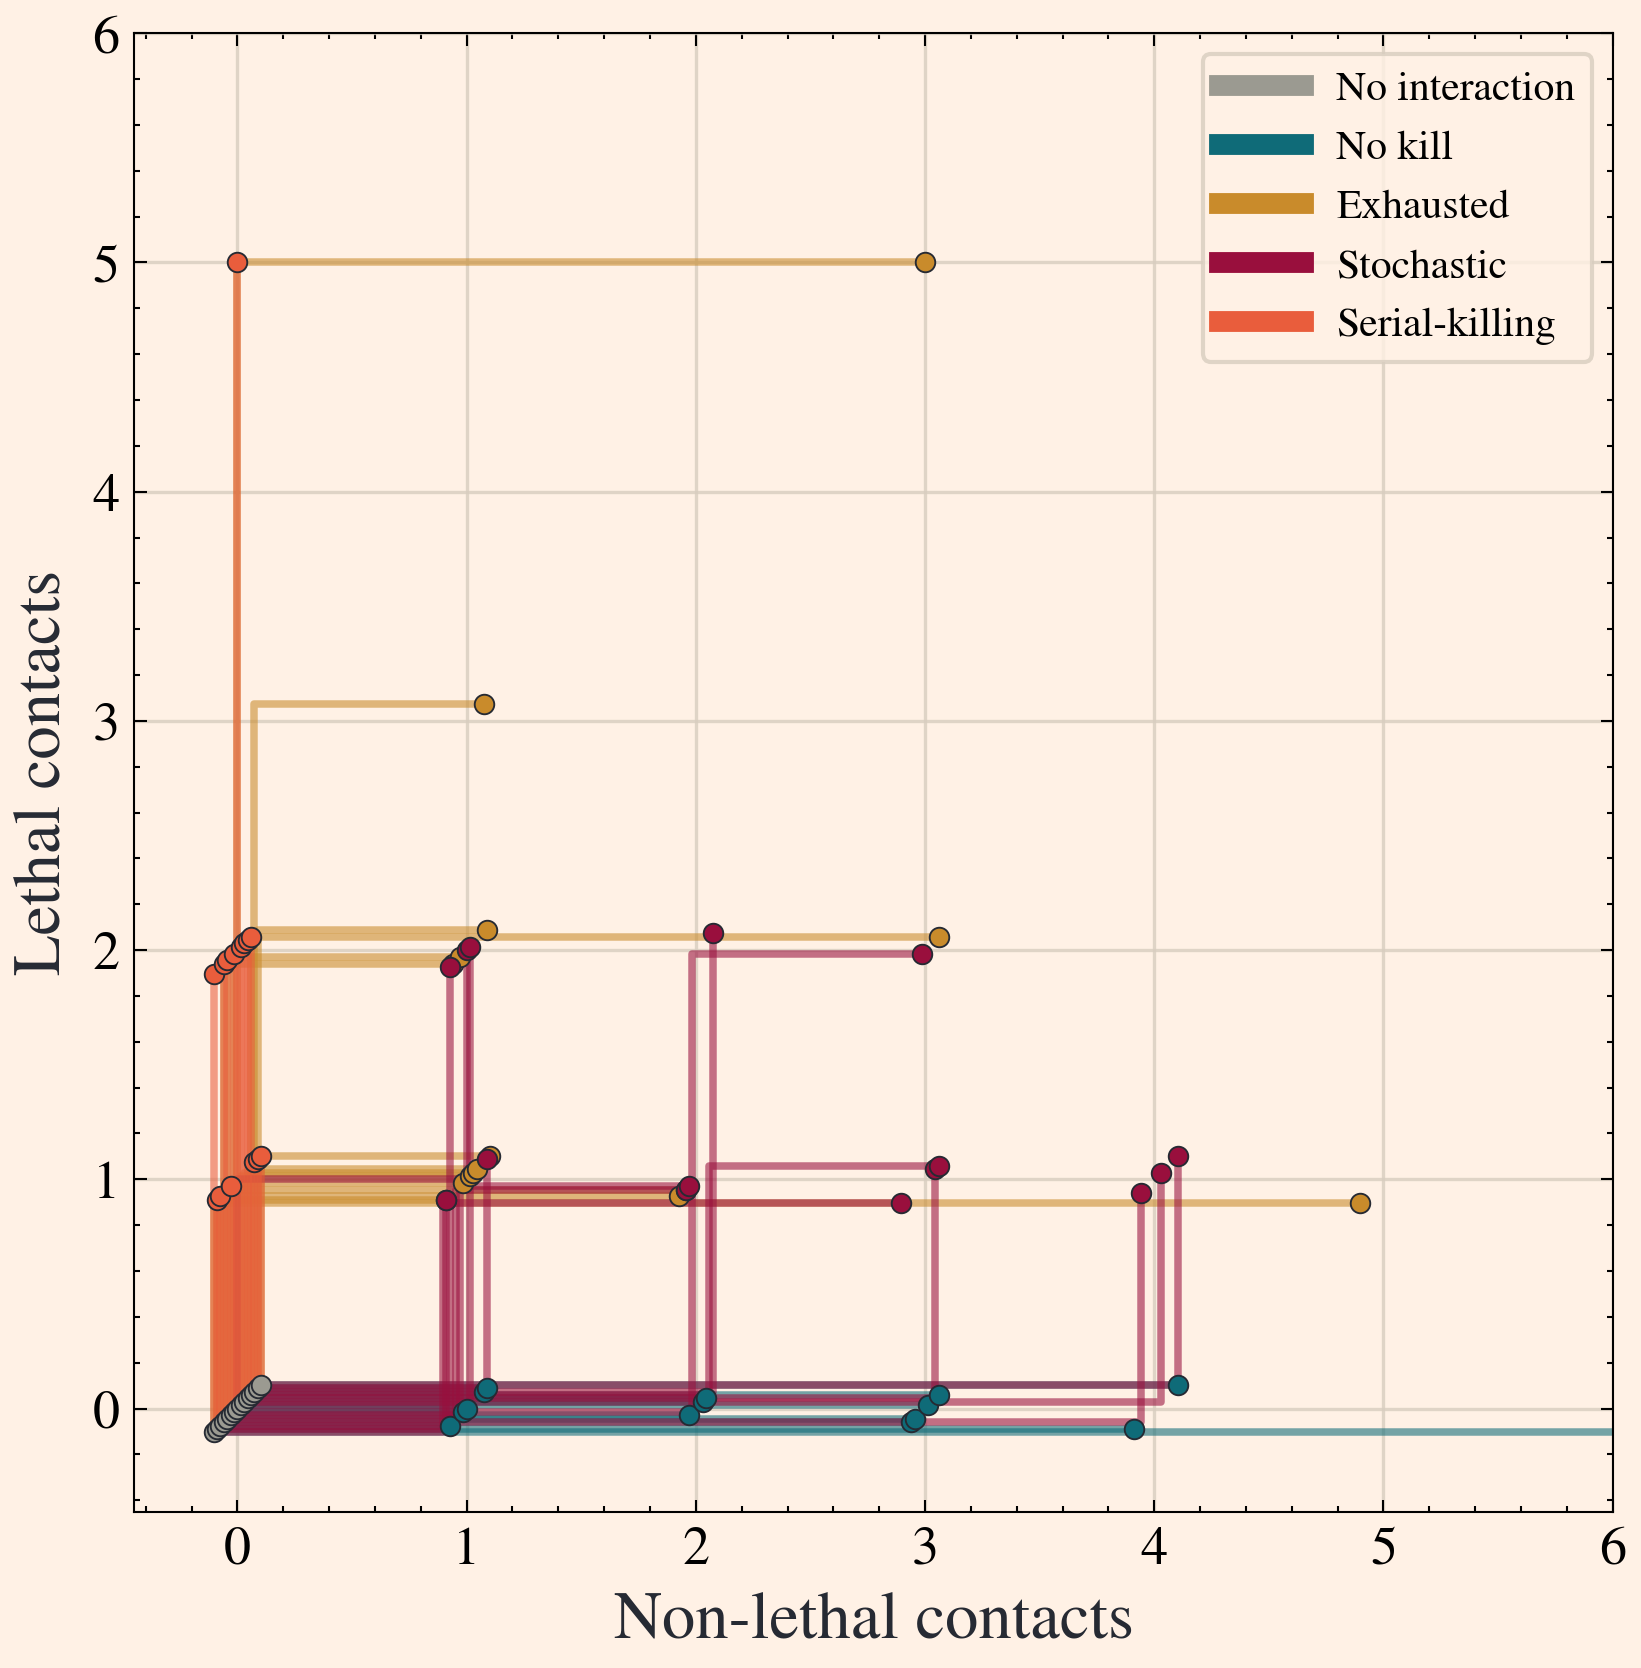

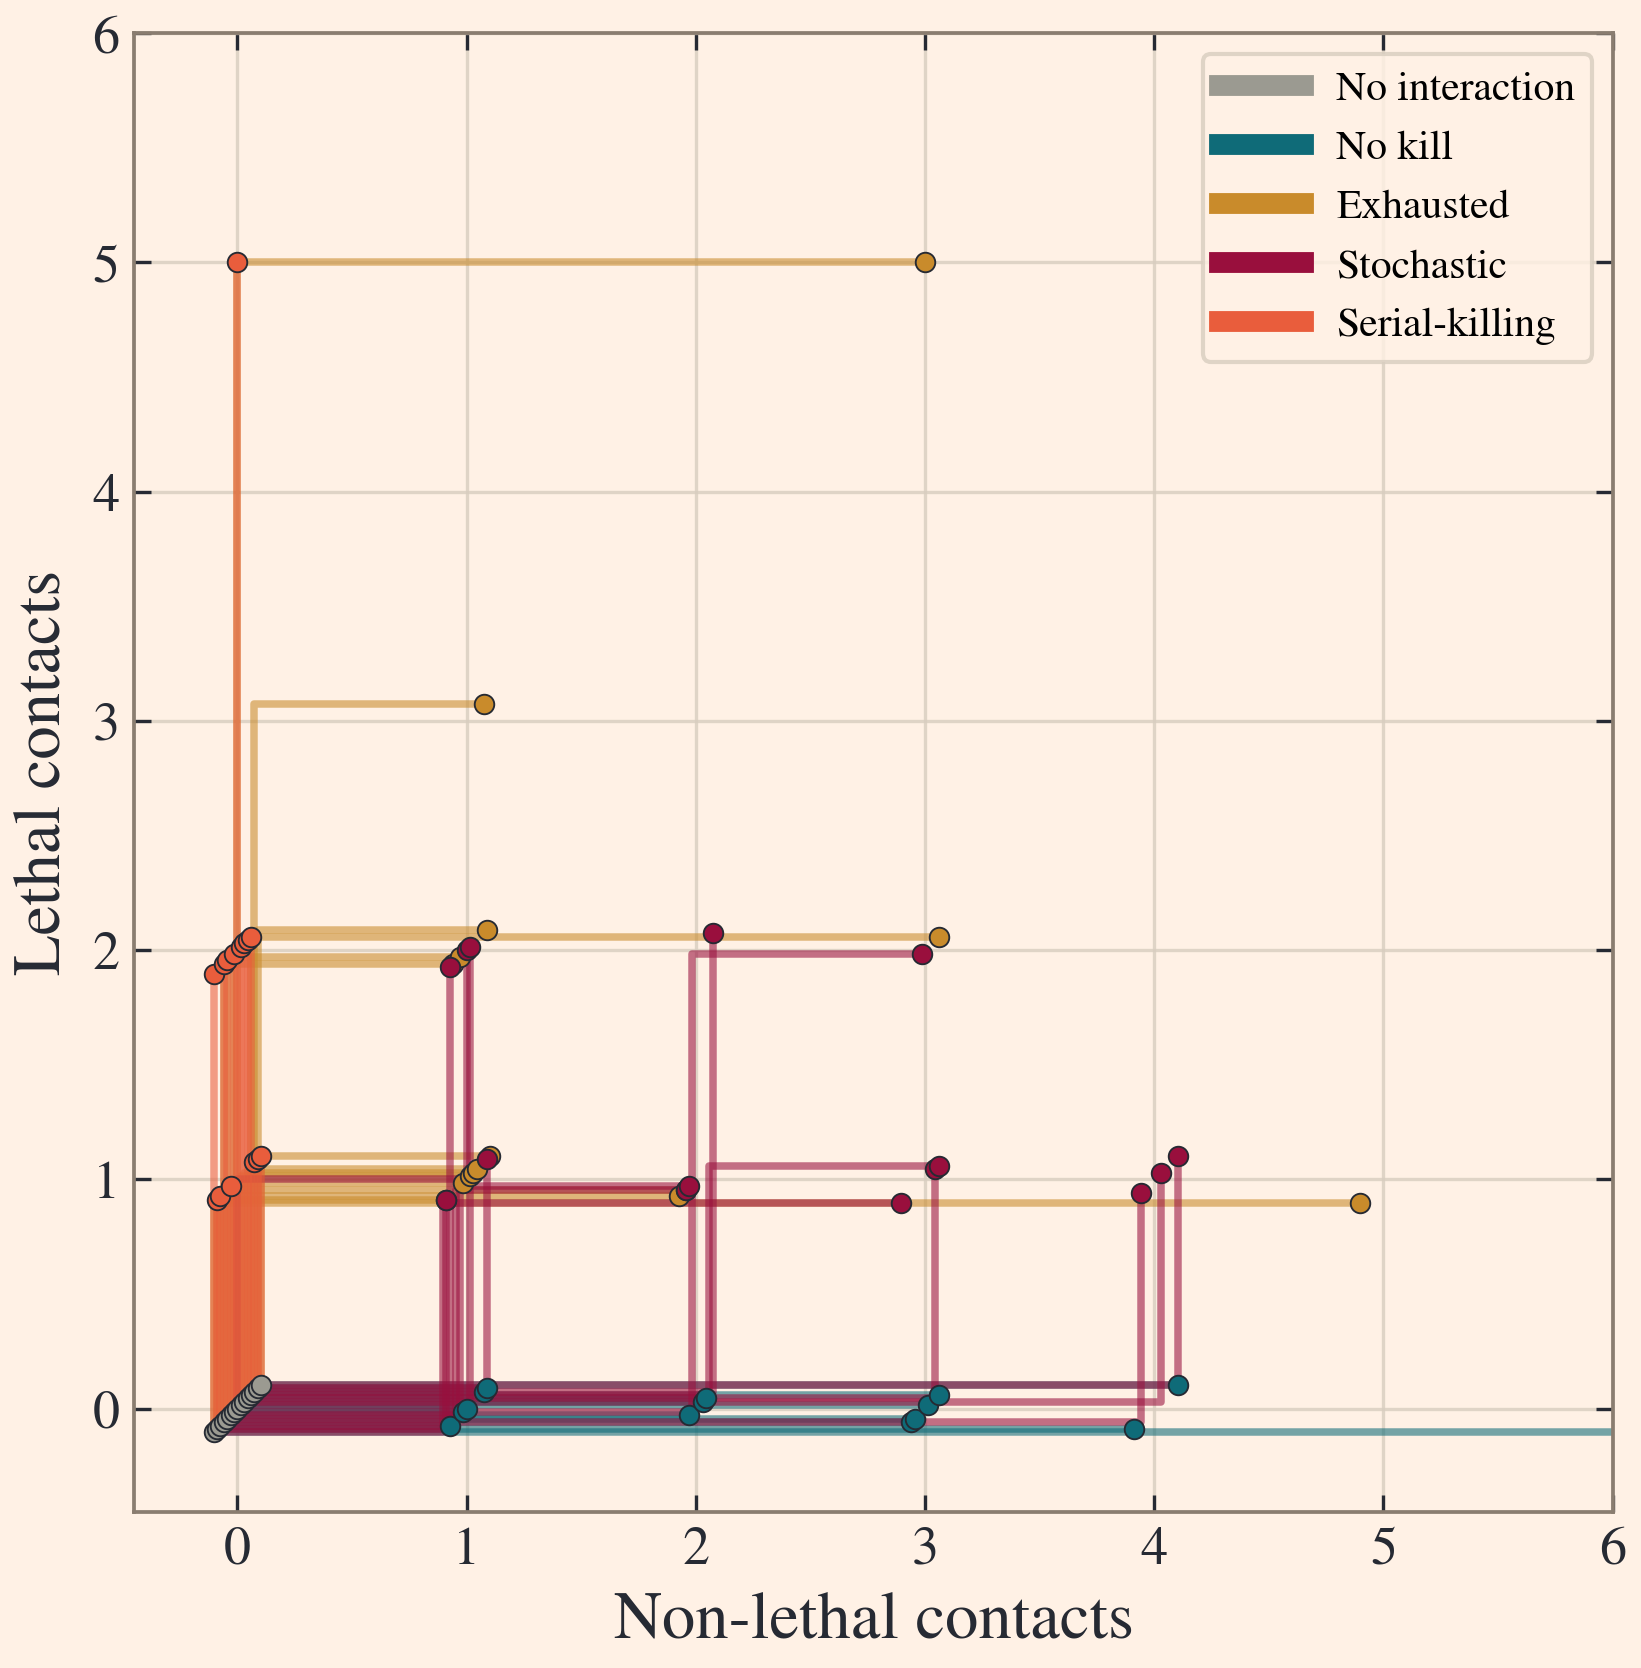

,condition,seed,decision_category,n_total,n_sampled,total_fraction,sampled_fraction
0,No treatment,20260710,No interaction,40,15,0.067340,0.2
1,No treatment,20260710,No kill,141,15,0.237374,0.2
2,No treatment,20260710,Exhausted,97,15,0.163300,0.2
3,No treatment,20260710,Stochastic,91,15,0.153199,0.2
4,No treatment,20260710,Serial-killing,225,15,0.378788,0.2


PosixPath('/Users/marsian/PhD_LifeSciRes/Orca/section_4/figures/analysis_1/decision_trajectories_no_treatment_categorised_ft.svg')

In [20]:
DECISION_CATEGORY_ORDER = [
    "No interaction",
    "No kill",
    "Exhausted",
    "Stochastic",
    "Serial-killing",
]

FT_PAPER = "#FFF1E5"
FT_TEXT = "#262A33"
FT_GRID = "#D8CDBF"
FT_SPINE = "#8A7D70"

FT_DECISION_COLORS = {
    "No interaction": "#9B9A91",
    "No kill": "#0F6B78",
    "Exhausted": "#C98B2B",
    "Stochastic": "#990F3D",
    "Serial-killing": "#E95D3C",
}


def classify_decision_history(history):
    h = tuple(int(z) for z in history)

    if len(h) == 0:
        return "No interaction"
    if sum(h) == 0:
        return "No kill"
    if sum(h) == len(h):
        return "Serial-killing"

    first_nonlethal = h.index(0)

    if all(z == 0 for z in h[first_nonlethal:]):
        return "Exhausted"

    return "Stochastic"


def decision_history_to_path(history):
    history = np.asarray(history, dtype=int)
    path = np.zeros((history.size + 1, 2), dtype=float)

    for i, z in enumerate(history, start=1):
        path[i] = path[i - 1]

        if z == 1:
            path[i, 1] += 1
        else:
            path[i, 0] += 1

    return path


def no_treatment_categorised_frame(cells, condition="No treatment"):
    df = cells.loc[cells["condition_label"].eq(condition)].copy()

    df["decision_category"] = pd.Categorical(
        [classify_decision_history(h) for h in df["history"]],
        categories=DECISION_CATEGORY_ORDER,
        ordered=True,
    )
    df["n_lethal"] = [int(np.sum(h)) for h in df["history"]]
    df["n_nonlethal"] = [int(len(h) - np.sum(h)) for h in df["history"]]

    return df


def seeded_stratified_subsample(df, *, seed=20260710, max_per_category=25, max_cells=None):
    rng = np.random.default_rng(seed)

    if max_per_category is not None:
        parts = []

        for category in DECISION_CATEGORY_ORDER:
            sub = df.loc[df["decision_category"].eq(category)]

            if sub.empty:
                continue

            take = min(max_per_category, len(sub))
            chosen = rng.choice(sub.index.to_numpy(), size=take, replace=False)
            parts.append(df.loc[chosen])

        if not parts:
            return df.iloc[0:0].copy()

        return pd.concat(parts, axis=0).sample(frac=1, random_state=seed).reset_index(drop=True)

    if max_cells is None or len(df) <= max_cells:
        return df.sample(frac=1, random_state=seed).reset_index(drop=True)

    chosen = rng.choice(df.index.to_numpy(), size=max_cells, replace=False)
    return df.loc[chosen].sample(frac=1, random_state=seed).reset_index(drop=True)


def plot_no_treatment_categorised_decision_map(
    cells,
    *,
    seed=20260710,
    max_per_category=15,
    condition="No treatment",
    figure_root=FIGURE_ROOT,
    figsize=(6.6, 6.4),
    dpi=300,
    offset_scale=4.5,
    alpha=0.58,
    lw=1.8,
    s=22,
    axis_max=None,
    show=False,
):
    no_treatment = no_treatment_categorised_frame(cells, condition=condition)

    sampled = seeded_stratified_subsample(
        no_treatment,
        seed=seed,
        max_per_category=max_per_category,
    )

    stats = pd.DataFrame({"decision_category": DECISION_CATEGORY_ORDER})
    total_counts = (
        no_treatment["decision_category"]
        .astype(str)
        .value_counts()
        .rename_axis("decision_category")
        .rename("n_total")
        .reset_index()
    )
    sampled_counts = (
        sampled["decision_category"]
        .astype(str)
        .value_counts()
        .rename_axis("decision_category")
        .rename("n_sampled")
        .reset_index()
    )

    stats = (
        stats.merge(total_counts, on="decision_category", how="left")
        .merge(sampled_counts, on="decision_category", how="left")
        .fillna({"n_total": 0, "n_sampled": 0})
    )
    stats["n_total"] = stats["n_total"].astype(int)
    stats["n_sampled"] = stats["n_sampled"].astype(int)
    stats["total_fraction"] = stats["n_total"] / max(len(no_treatment), 1)
    stats["sampled_fraction"] = stats["n_sampled"] / max(len(sampled), 1)
    stats.insert(0, "condition", condition)
    stats.insert(1, "seed", seed)

    if no_treatment.empty:
        return None, stats

    max_count = int(no_treatment["contact_count"].max()) if axis_max is None else int(axis_max)

    with plt.rc_context(
        {
            "text.usetex": False,
            "mathtext.fontset": "stix",
            "font.family": "STIXGeneral",
            "axes.titlesize": 18,
            "axes.labelsize": 16,
            "xtick.labelsize": 13,
            "ytick.labelsize": 13,
            "legend.fontsize": 10,
        }
    ):
        fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
        fig.patch.set_facecolor(FT_PAPER)
        ax.set_facecolor(FT_PAPER)
        ax.set_axisbelow(True)

        for category_idx, category in enumerate(DECISION_CATEGORY_ORDER):
            sub = sampled.loc[sampled["decision_category"].eq(category)]
            sub = sub.sample(frac=1, random_state=seed + category_idx).reset_index(drop=True)
            n_cells = len(sub)

            if n_cells == 0:
                continue

            color = FT_DECISION_COLORS[category]

            for i, row in sub.iterrows():
                path = decision_history_to_path(row["history"])
                offset = (i - (n_cells - 1) / 2) / (offset_scale * max(n_cells, 1))
                path = path + offset

                ax.plot(
                    path[:, 0],
                    path[:, 1],
                    color=color,
                    alpha=alpha,
                    lw=lw,
                    solid_capstyle="round",
                    zorder=2,
                )
                ax.scatter(
                    path[-1, 0],
                    path[-1, 1],
                    color=color,
                    s=s,
                    edgecolor=FT_TEXT,
                    linewidth=0.45,
                    zorder=4,
                )

        handles = []

        for category in DECISION_CATEGORY_ORDER:
            row = stats.loc[stats["decision_category"].eq(category)].iloc[0]

            if row["n_total"] == 0:
                continue

            handles.append(
                plt.Line2D(
                    [],
                    [],
                    color=FT_DECISION_COLORS[category],
                    lw=5,
                    label=f"{category}",
                )
            )

        ax.legend(
            handles=handles,
            # title="Category",
            loc="upper right",
            frameon=True,
            facecolor=FT_PAPER,
            edgecolor=FT_GRID,
            title_fontsize=11,
        )


        # ax.set_title(f"{condition} decision trajectories", loc="left", color=FT_TEXT, pad=10)
        ax.set_xlabel("Non-lethal contacts", color=FT_TEXT)
        ax.set_ylabel("Lethal contacts", color=FT_TEXT)
        ax.set_xlim(-0.45, 6)
        ax.set_ylim(-0.45, 6)
        ax.set_aspect("equal")
        ax.grid(True, color=FT_GRID, linewidth=0.8, alpha=0.8)

        ax.xaxis.set_major_locator(MultipleLocator(1))
        ax.yaxis.set_major_locator(MultipleLocator(1))
        ax.tick_params(axis="both", colors=FT_TEXT, width=0.8, length=4)
        ax.xaxis.set_minor_locator(NullLocator())
        ax.yaxis.set_minor_locator(NullLocator())
        ax.tick_params(which="minor", bottom=False, left=False, top=False, right=False)
        
        for spine in ax.spines.values():
            spine.set_color(FT_SPINE)
            spine.set_linewidth(0.9)

        figure_root.mkdir(parents=True, exist_ok=True)
        out_path = figure_root / "decision_trajectories_no_treatment_categorised_ft.svg"
        png_path = figure_root / "decision_trajectories_no_treatment_categorised_ft.png"

        fig.savefig(out_path, format="svg", bbox_inches="tight", facecolor=fig.get_facecolor())
        fig.savefig(png_path, format="png", bbox_inches="tight", facecolor=fig.get_facecolor())

        if show:
            plt.show()
        else:
            plt.close(fig)

    return out_path, stats


no_treatment_decision_path, no_treatment_decision_stats = plot_no_treatment_categorised_decision_map(
    cells,
    seed=20260710,
    max_per_category=15,
    show=True,
)

display(no_treatment_decision_stats)
no_treatment_decision_path

## Cached SMC inference results

The notebook reads saved outputs only. To generate or resume them, run:

```bash
python3 section_4/scripts/run_analysis_1_inference.py
```

For a quick aggregate rebuild from existing per-model CSVs, run:

```bash
python3 section_4/scripts/run_analysis_1_inference.py --collect-only
```


In [9]:
logml_df = collect_cached_log_evidence()
posterior_data = load_cached_posteriors()

print(f"Cached log-evidence rows: {len(logml_df)}")
print(f"Cached posterior files: {len(posterior_data)}")
logml_df


Cached log-evidence rows: 12
Cached posterior files: 12


,condition,model,log_evidence
0,No treatment,homogeneous_history_independent,-2407.781514
1,No treatment,homogeneous_history_dependent,-2215.368300
2,No treatment,heterogeneous_history_independent,-2229.868874
3,No treatment,heterogeneous_history_dependent,-2193.545395
4,Rituximab,homogeneous_history_independent,-2275.880597
5,Rituximab,homogeneous_history_dependent,-2107.523644
6,Rituximab,heterogeneous_history_independent,-2149.545194
7,Rituximab,heterogeneous_history_dependent,-2088.192049
8,Bispecific Ab,homogeneous_history_independent,-2167.124287
9,Bispecific Ab,homogeneous_history_dependent,-1974.529508


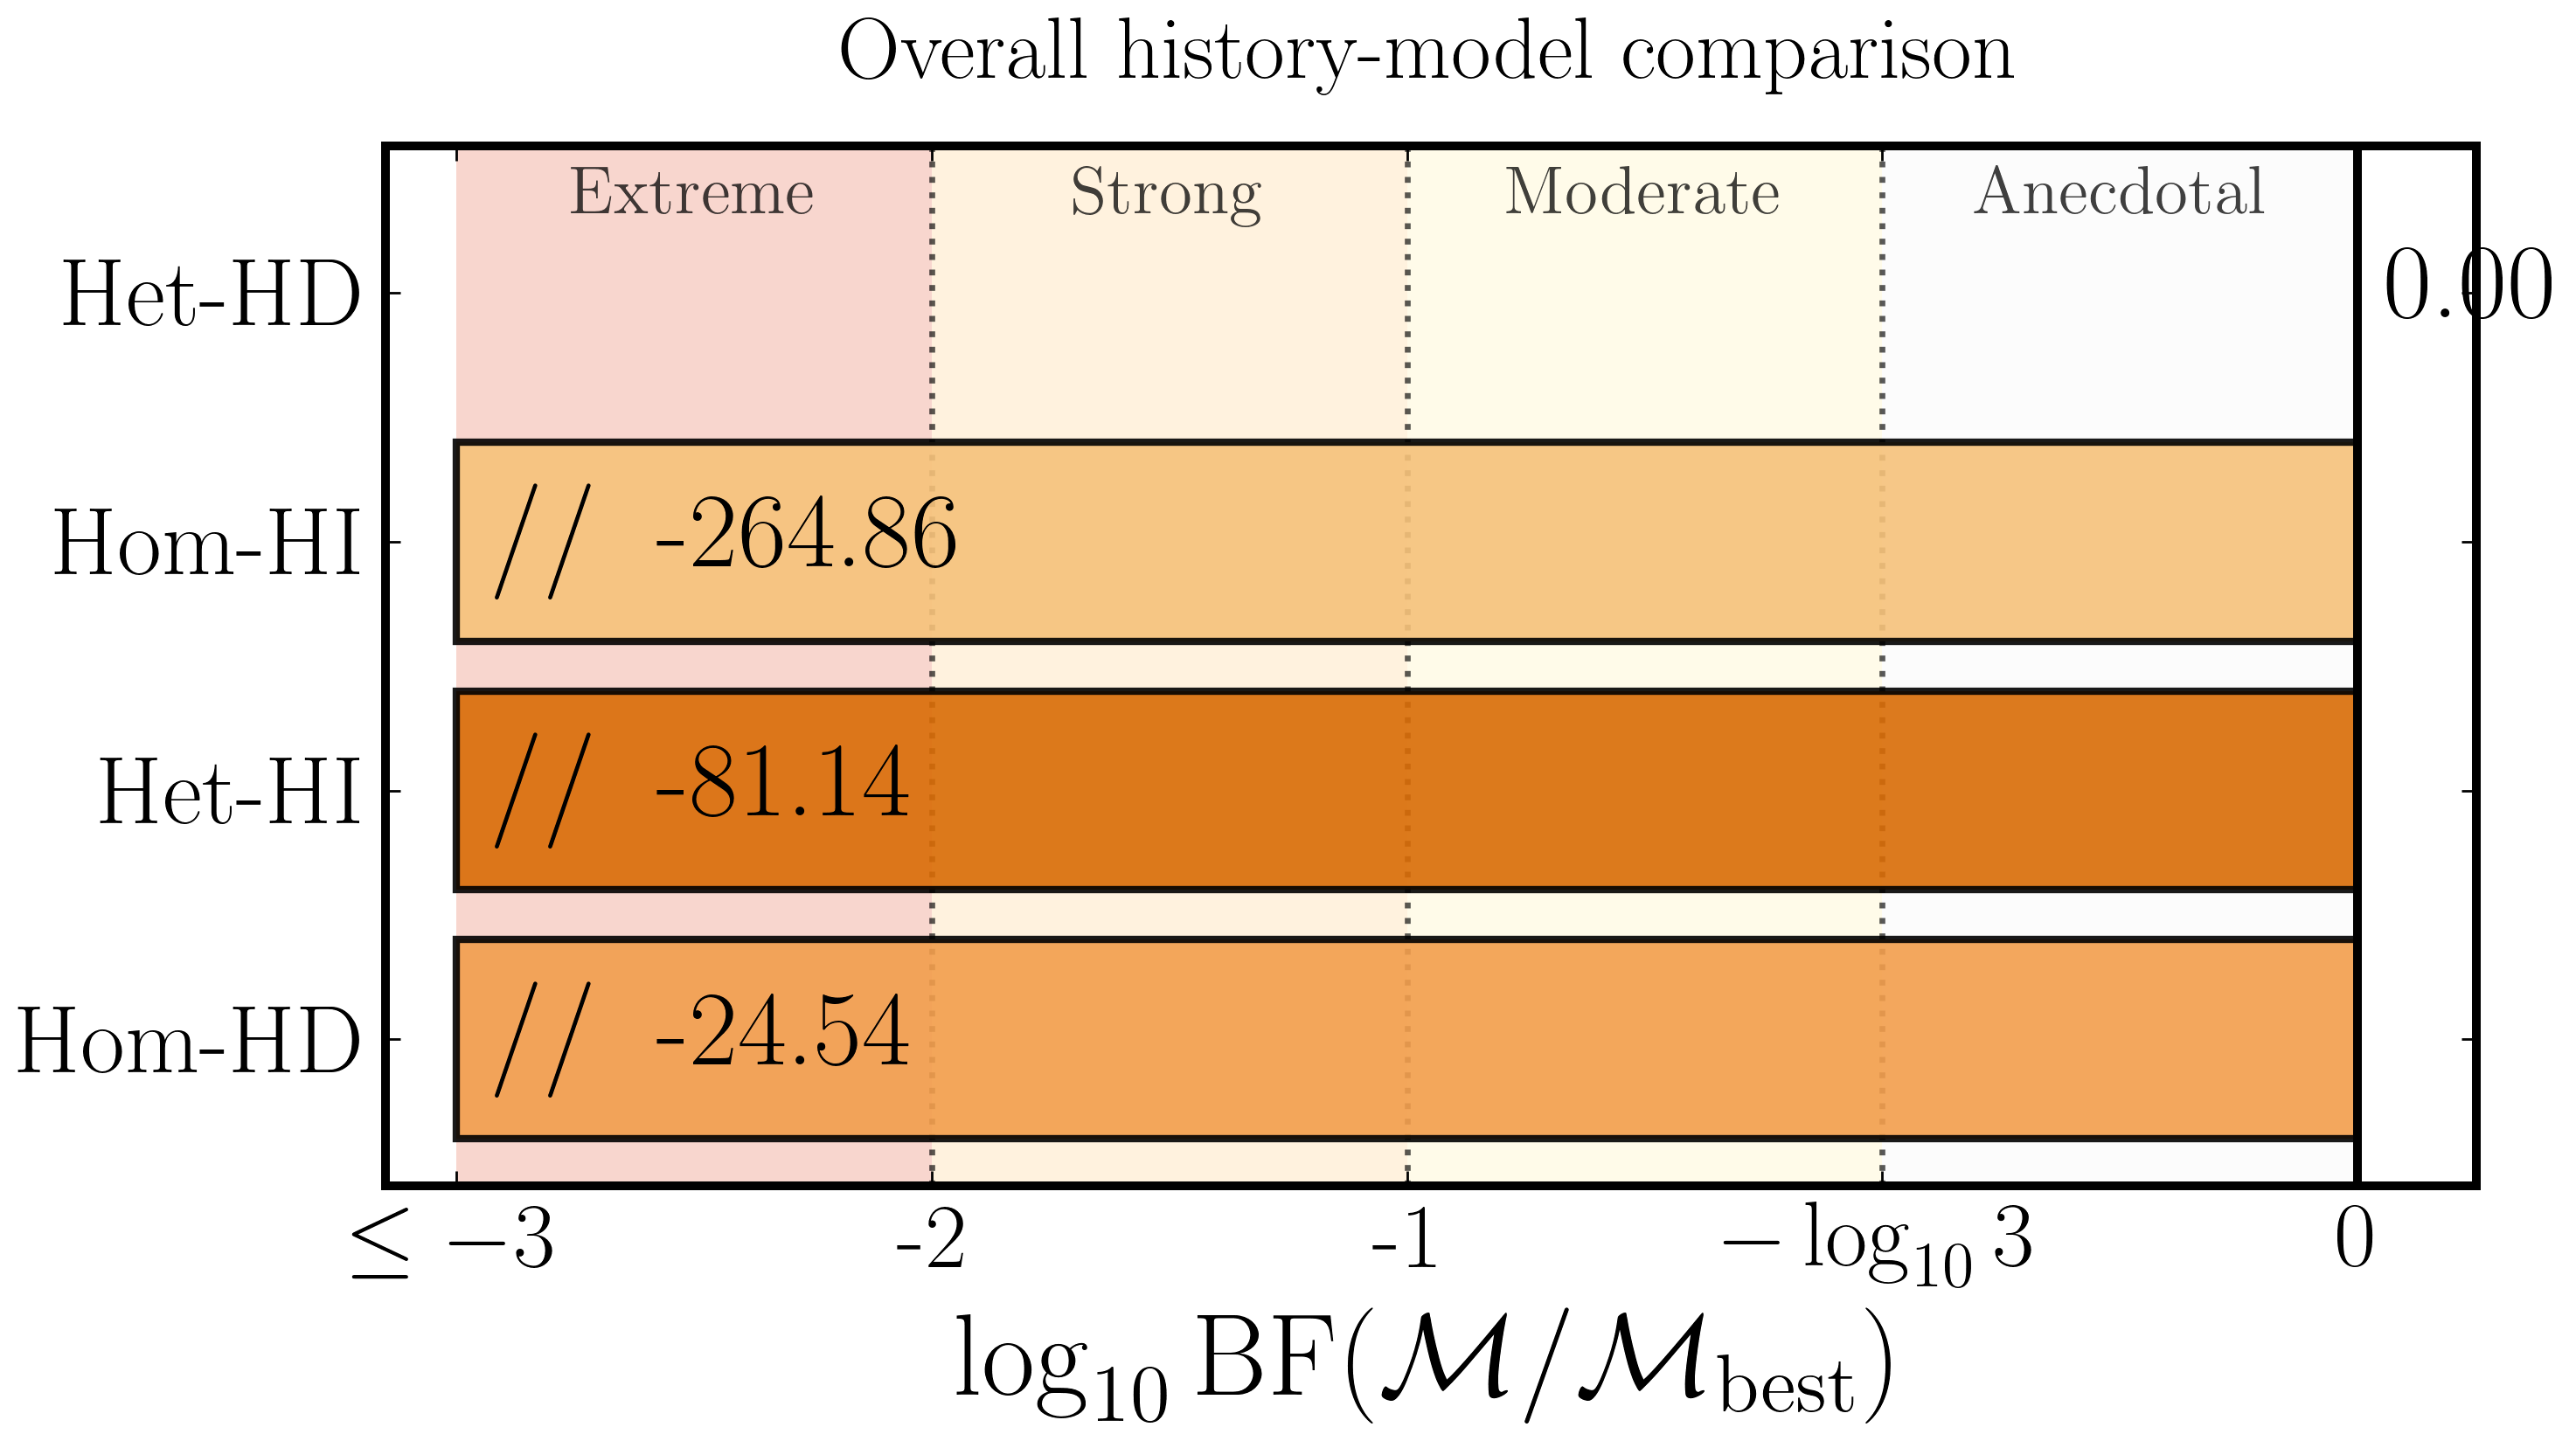

,condition,model,log_evidence
11,Bispecific Ab,heterogeneous_history_dependent,-1959.175404
9,Bispecific Ab,homogeneous_history_dependent,-1974.529508
10,Bispecific Ab,heterogeneous_history_independent,-2048.333796
8,Bispecific Ab,homogeneous_history_independent,-2167.124287
3,No treatment,heterogeneous_history_dependent,-2193.545395
1,No treatment,homogeneous_history_dependent,-2215.368300
2,No treatment,heterogeneous_history_independent,-2229.868874
0,No treatment,homogeneous_history_independent,-2407.781514
7,Rituximab,heterogeneous_history_dependent,-2088.192049
5,Rituximab,homogeneous_history_dependent,-2107.523644


,model,total_log_evidence,n_conditions,delta_log_evidence_vs_best,log10_BF_model_vs_best,log10_BF_best_vs_model,BF_best_vs_model,model_display
0,heterogeneous_history_dependent,-6240.912847,3,0.000000,0.000000,-0.000000,1.000000e+00,Het-HD
1,homogeneous_history_dependent,-6297.421452,3,-56.508605,-24.541375,24.541375,3.478367e+24,Hom-HD
2,heterogeneous_history_independent,-6427.747865,3,-186.835017,-81.141417,81.141417,1.384896e+81,Het-HI
3,homogeneous_history_independent,-6850.786398,3,-609.873550,-264.864718,264.864718,7.323481e+264,Hom-HI


In [10]:
if not logml_df.empty:
    bf_condition_df, overall_df = write_evidence_plots(logml_df, show=True)
    display(logml_df.sort_values(["condition", "log_evidence"], ascending=[True, False]))
    display(overall_df)
else:
    bf_condition_df = None
    overall_df = None
    print("No cached evidence found yet. Run the inference script first.")


## Posterior plots from cached NetCDF files


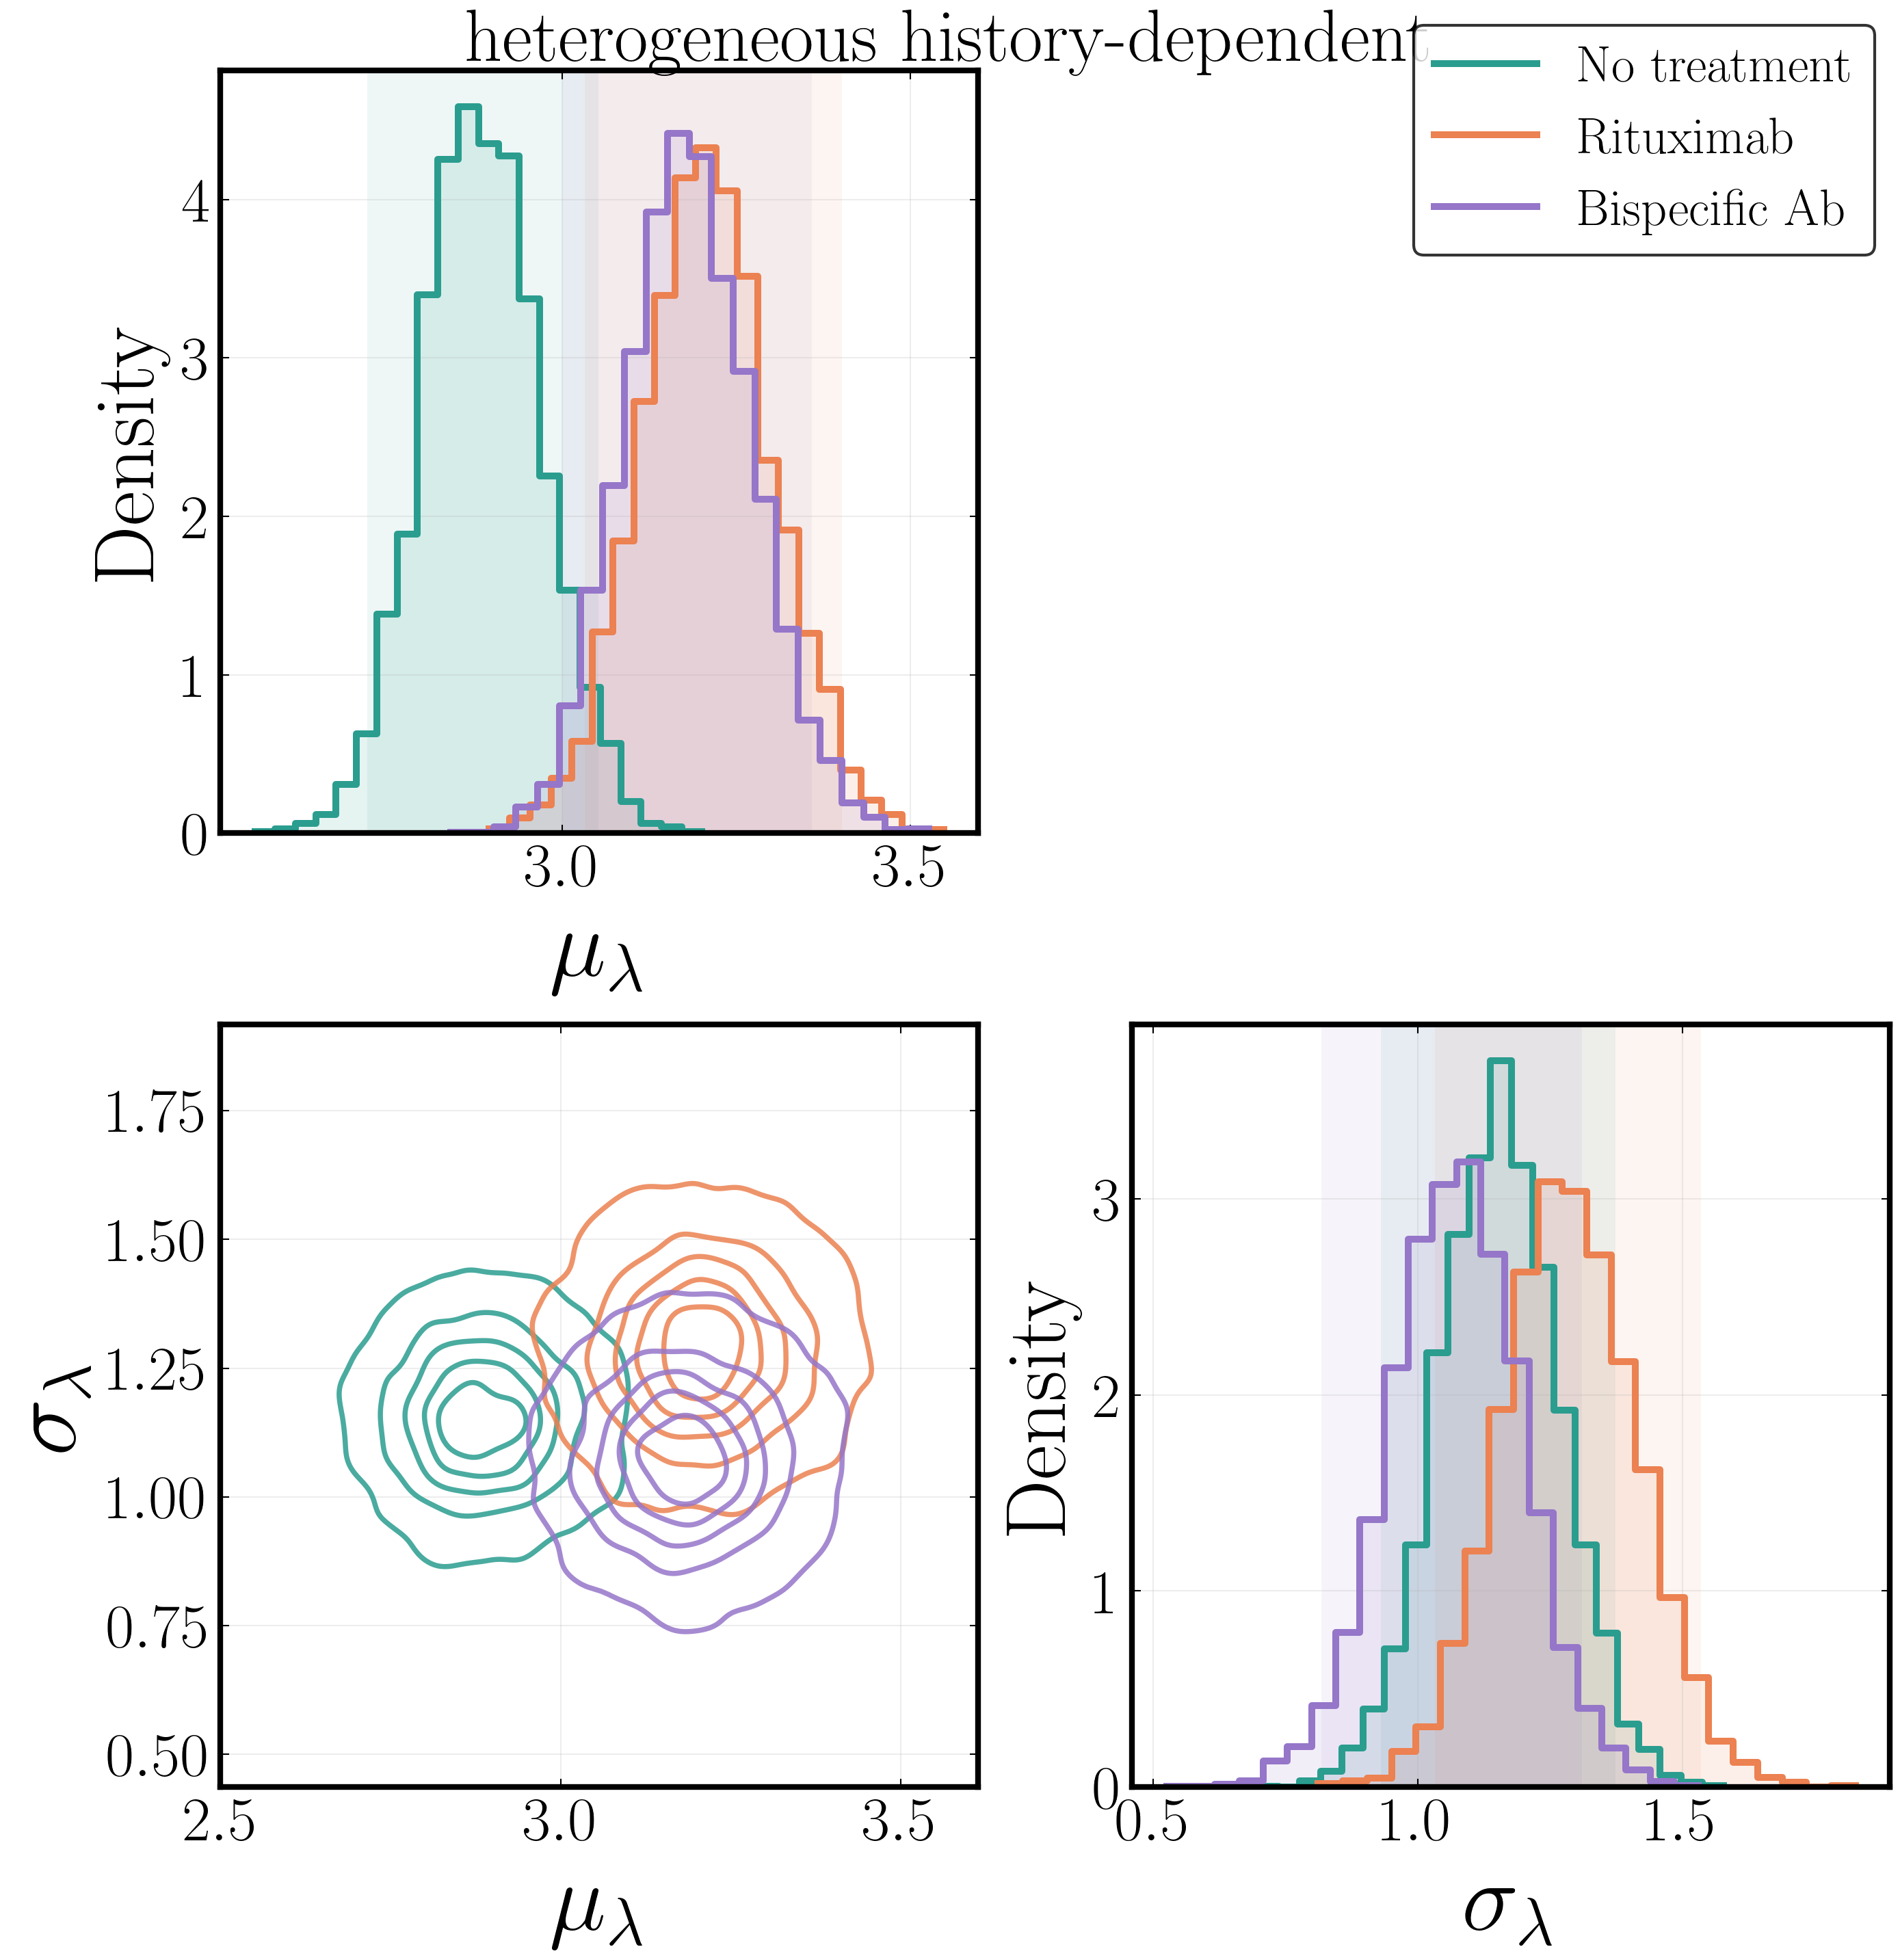

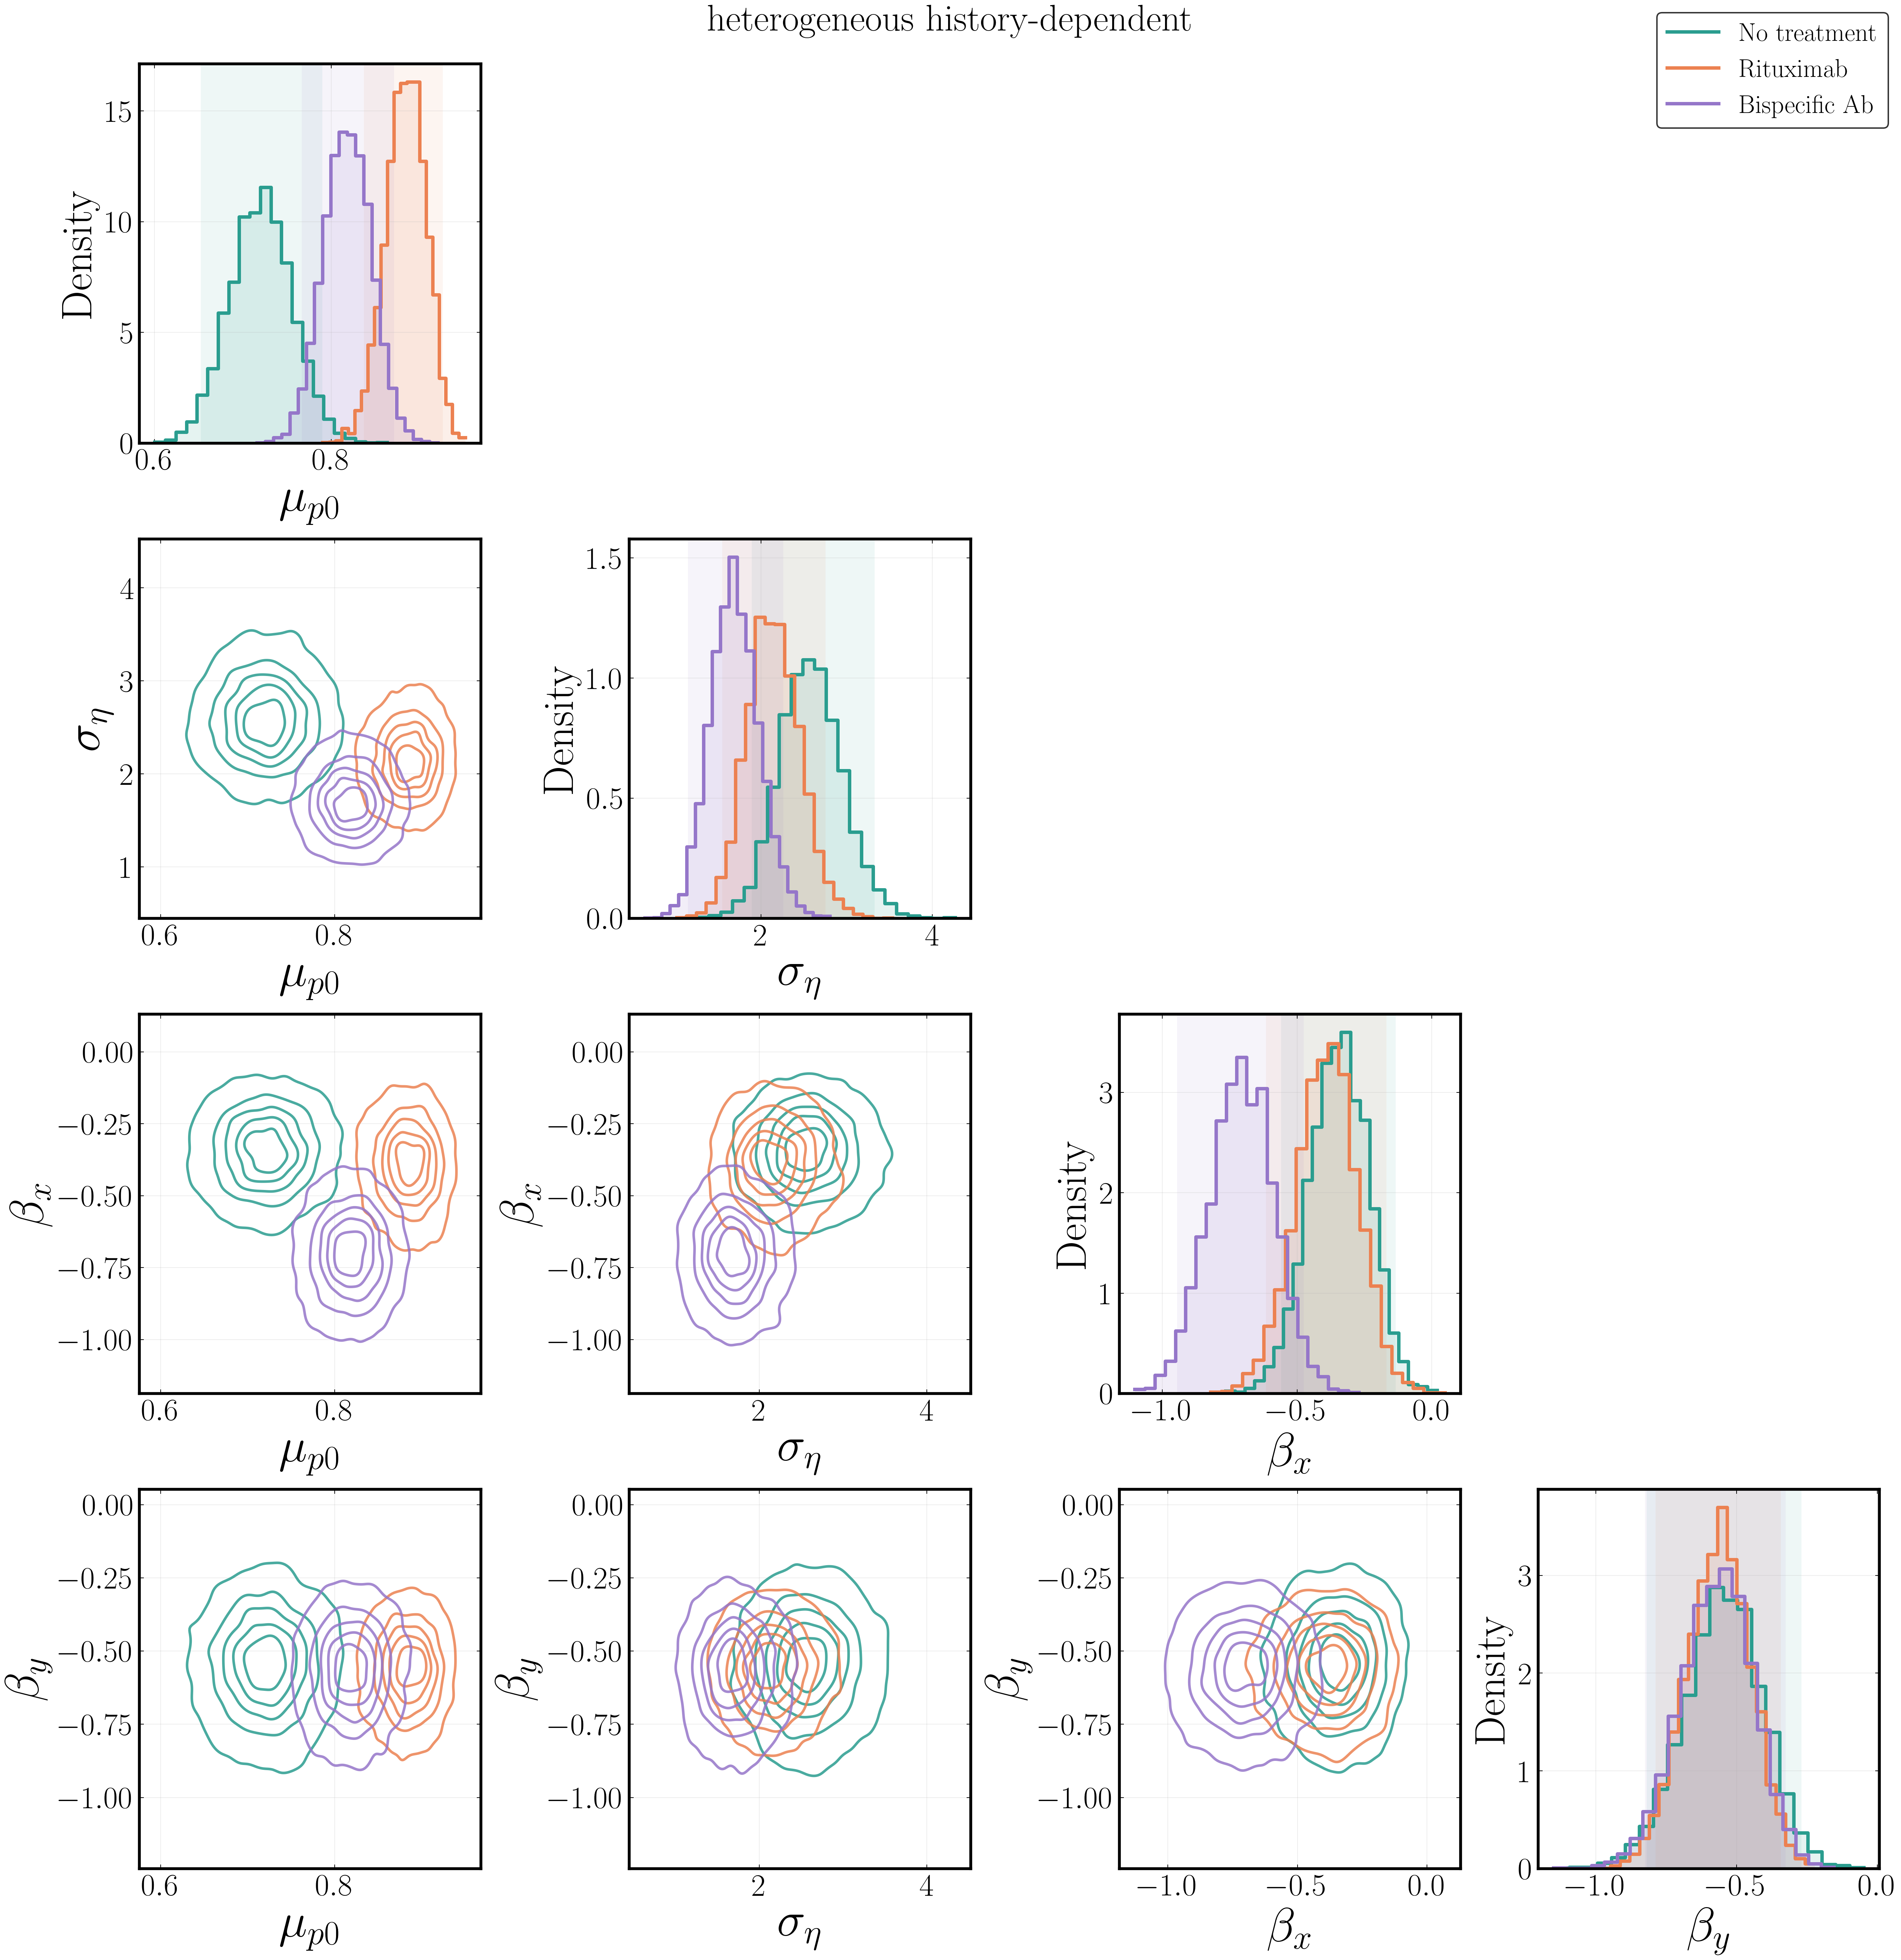

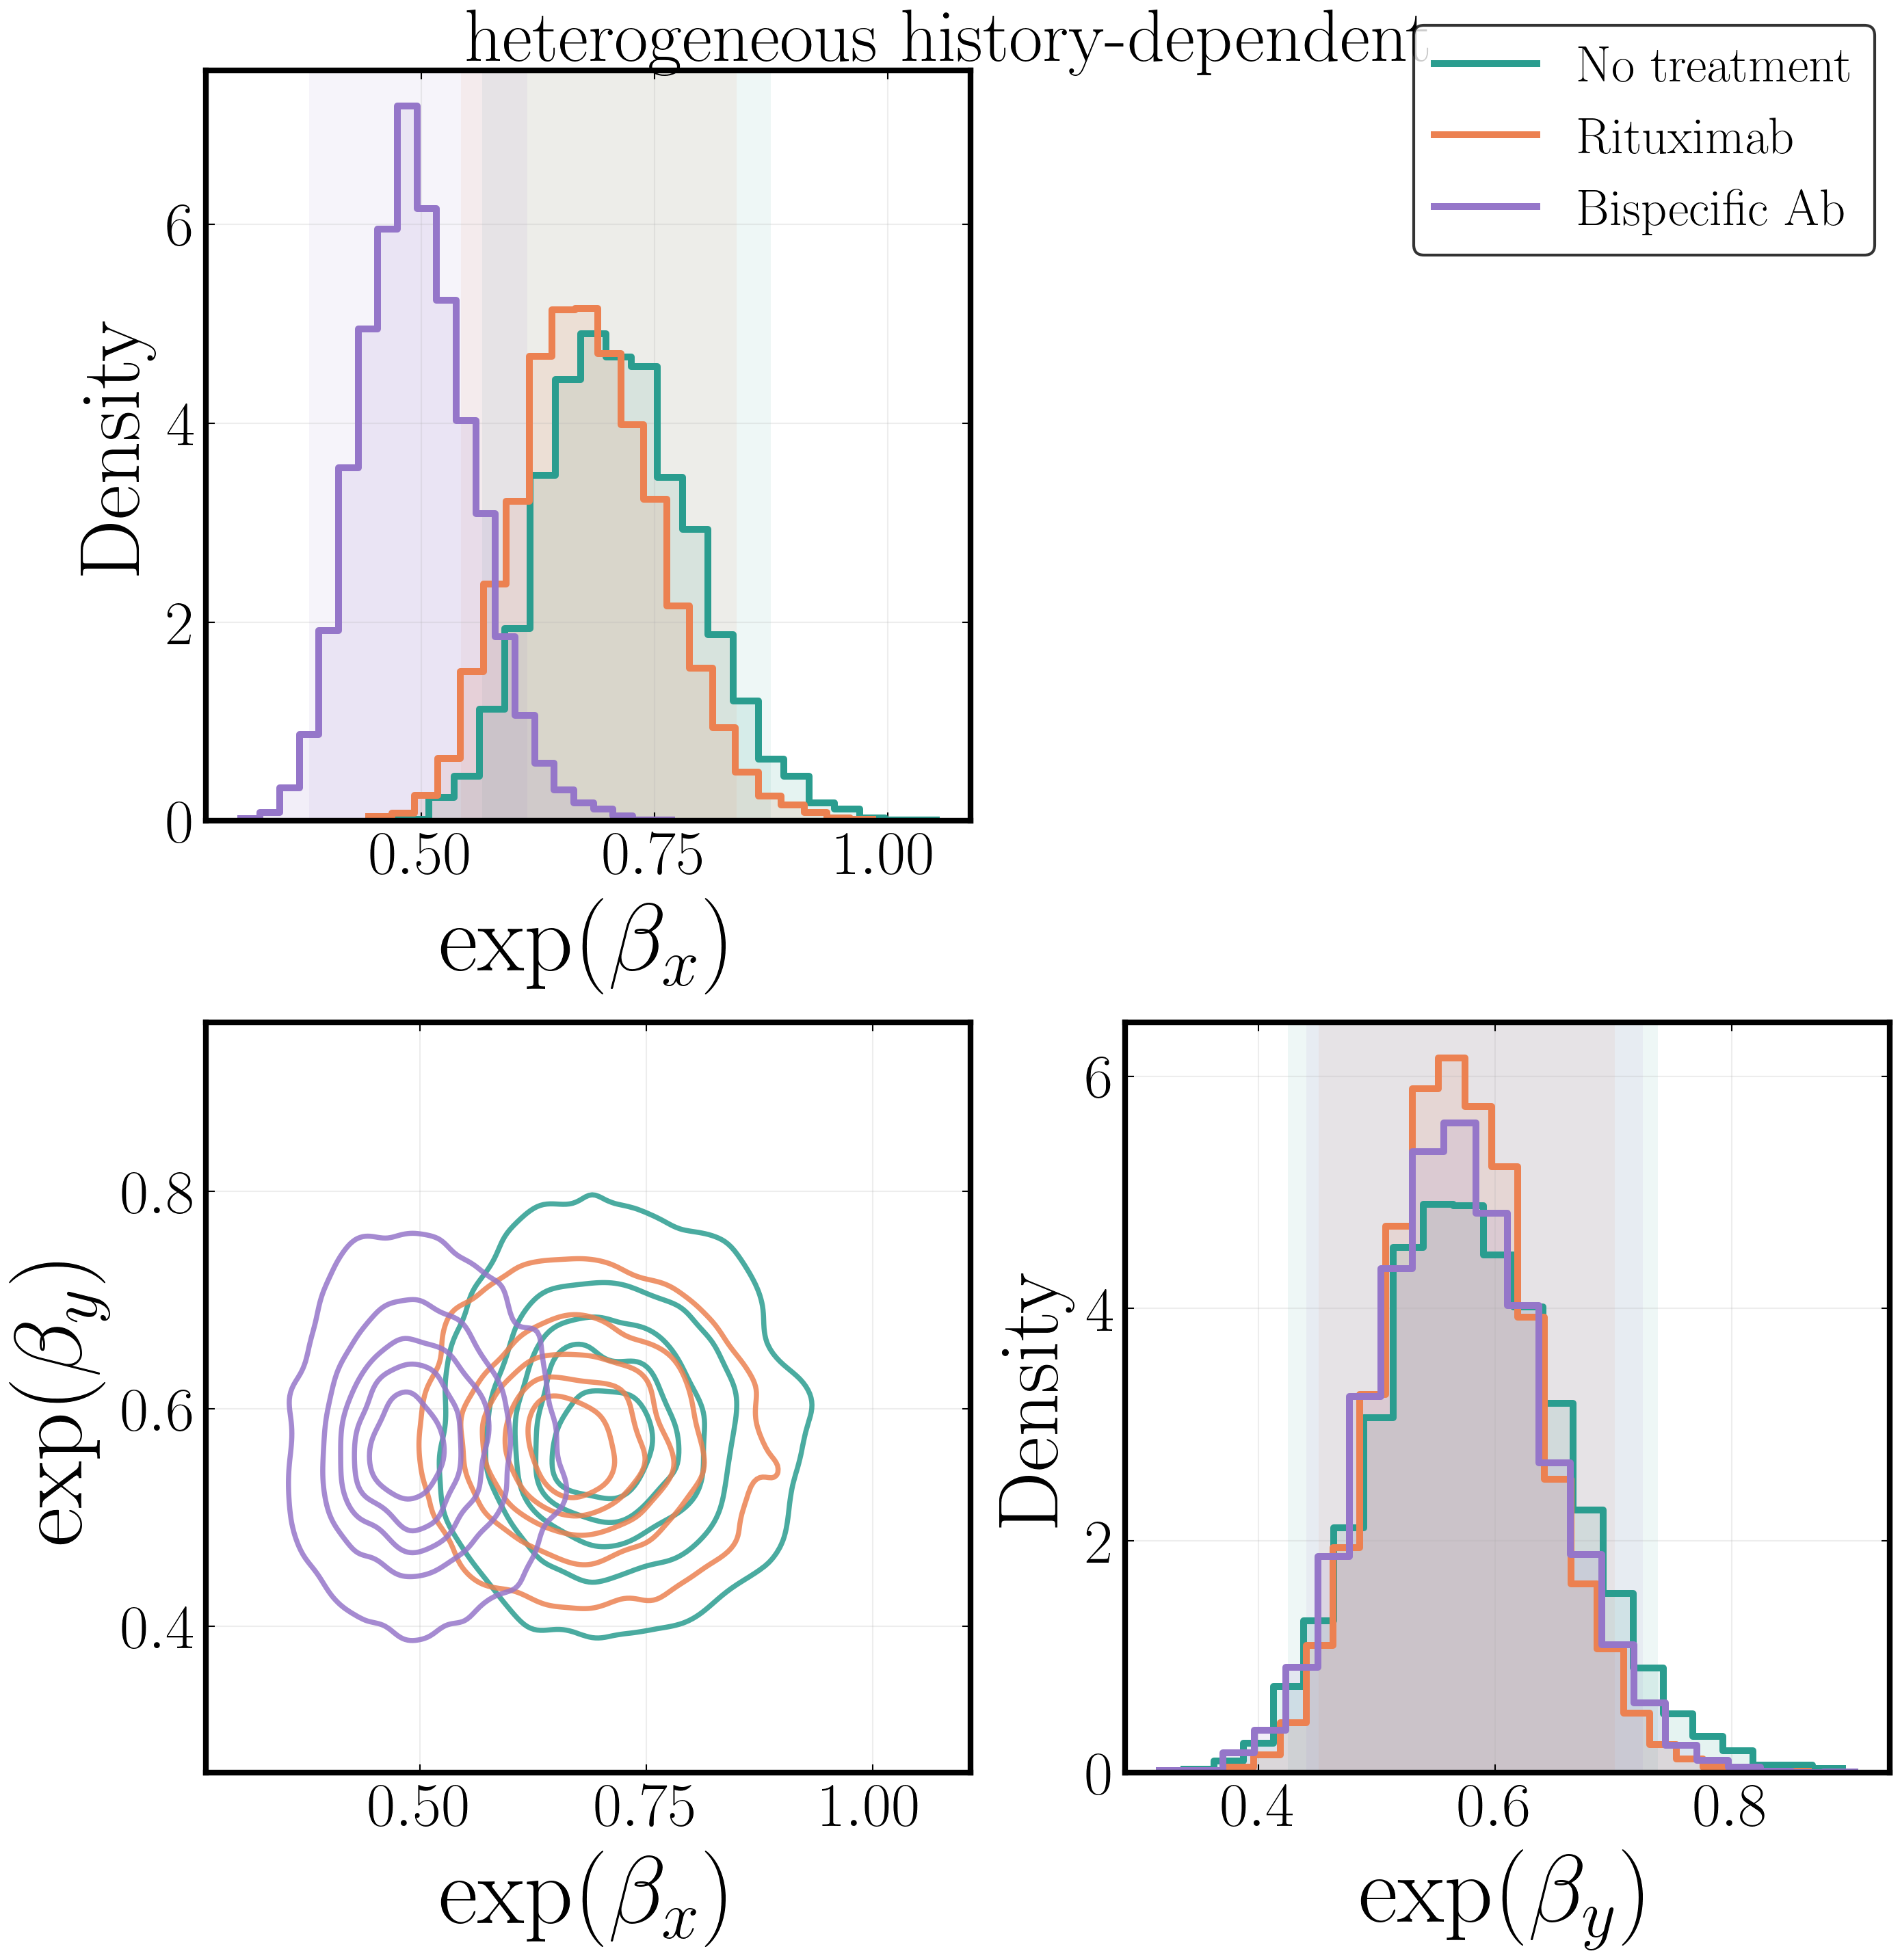

In [11]:
has_full_model = all(
    (condition, FULL_MODEL) in posterior_data
    for condition in CONDITION_ORDER
)

if has_full_model:
    run_posterior_plots(posterior_data, show=True)
else:
    missing = [
        condition
        for condition in CONDITION_ORDER
        if (condition, FULL_MODEL) not in posterior_data
    ]
    print("Full-model posteriors are not cached for:", missing)


/var/folders/rr/16wv6ts1785fz6_2qhr5bc2m0000gn/T/ipykernel_20100/4267170508.py:183: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_joint.legend(frameon=True, fontsize=16)


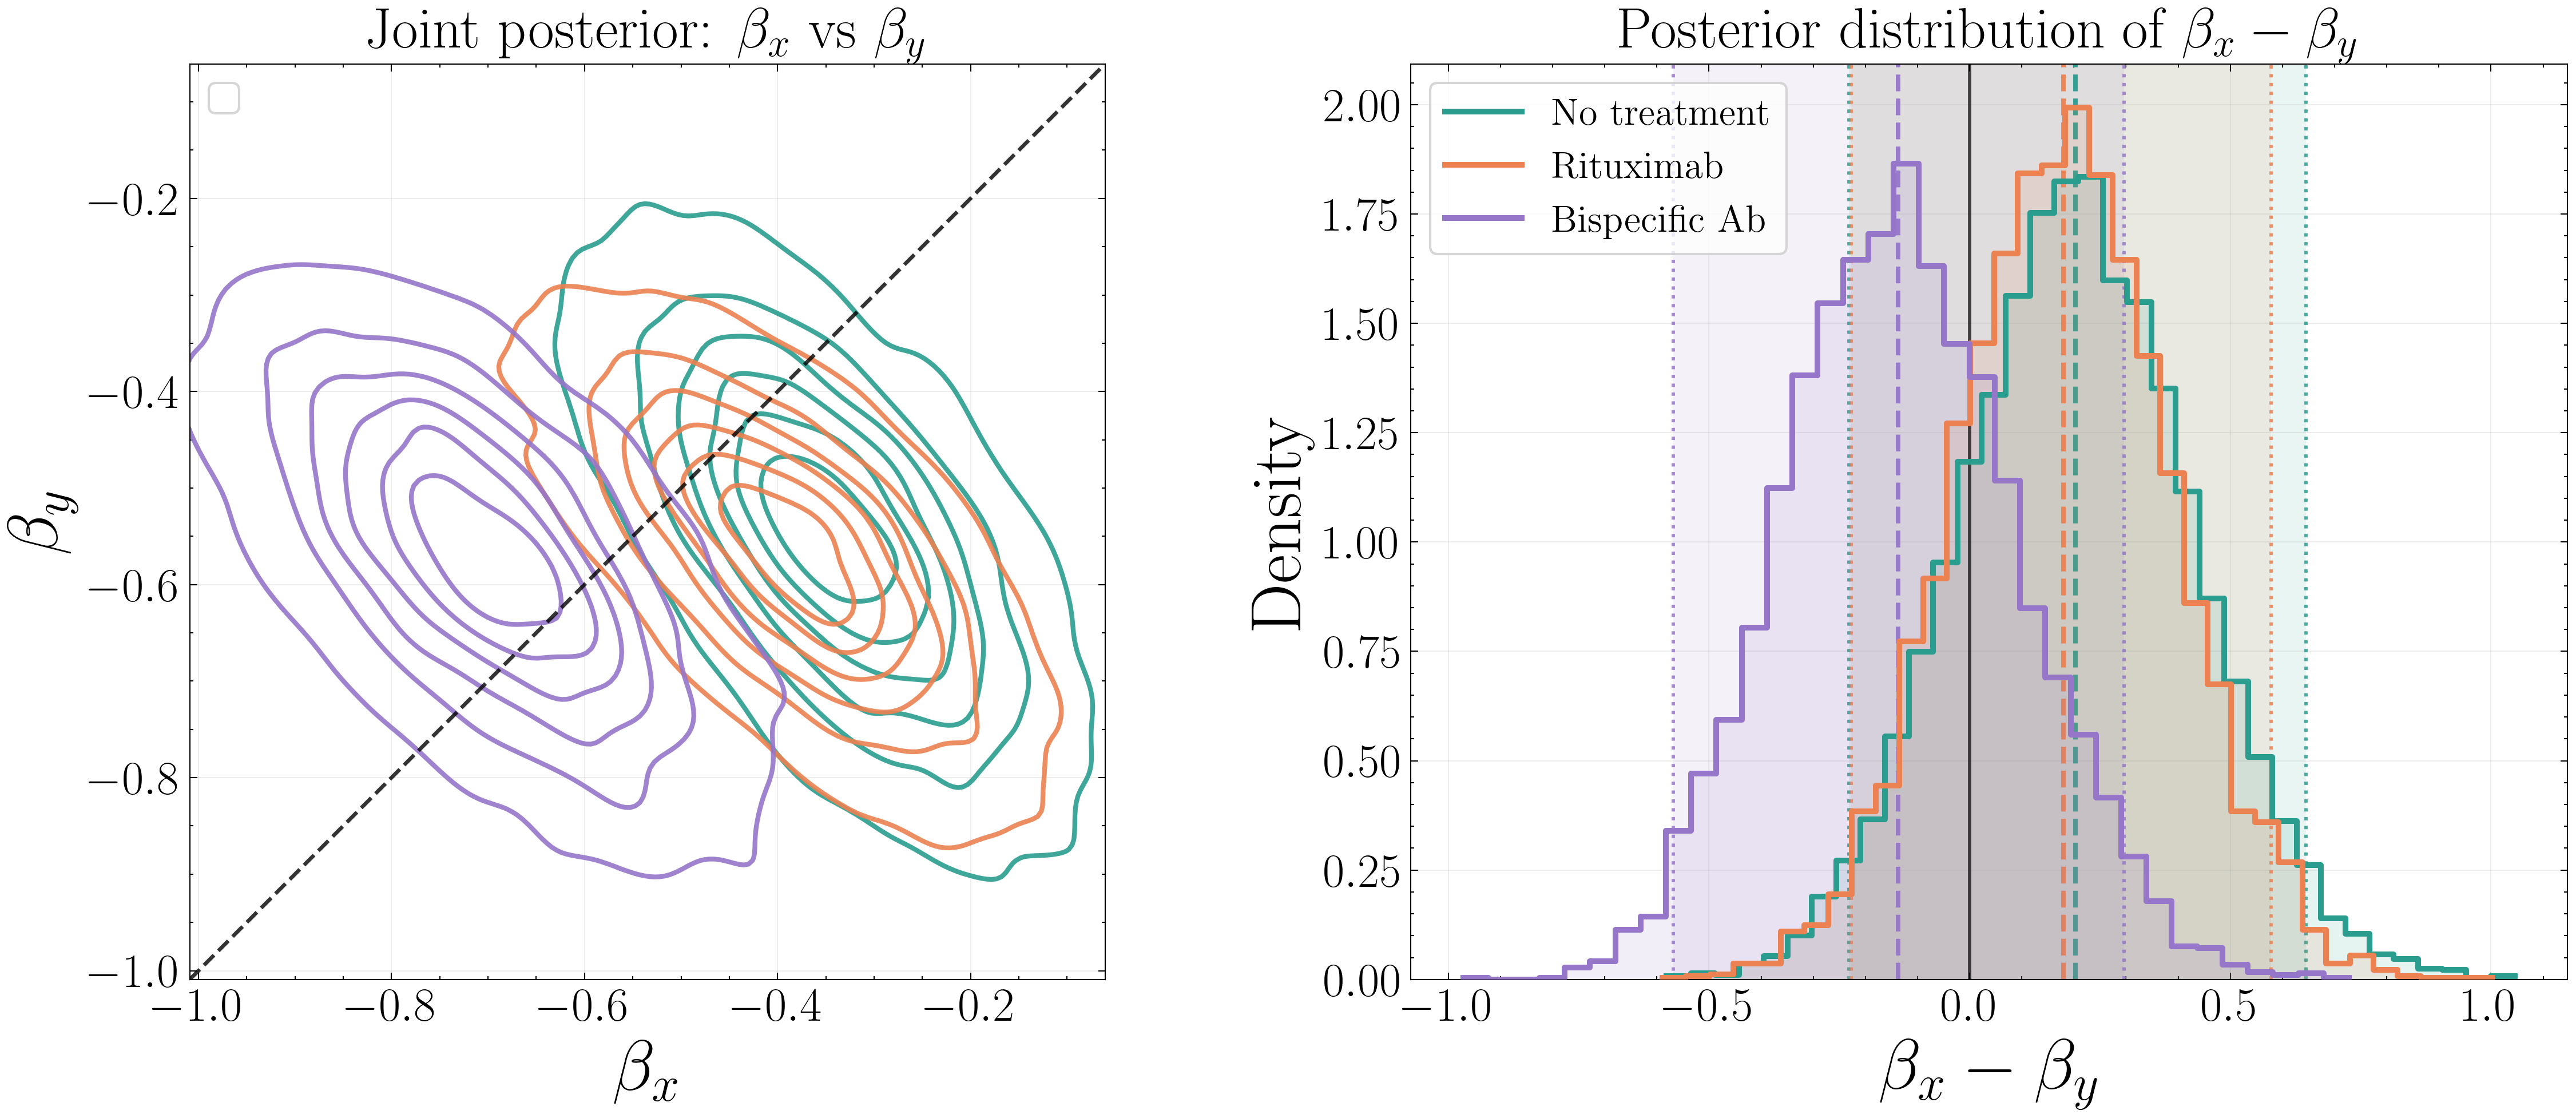

,condition,mean,median,std,hdi_2.5%,hdi_97.5%,p_beta_x_minus_beta_y_gt_0
0,No treatment,0.205034,0.203053,0.223948,-0.231176,0.645566,0.820833
1,Rituximab,0.178513,0.180102,0.205498,-0.227074,0.578262,0.805333
2,Bispecific Ab,-0.131807,-0.137192,0.224359,-0.567993,0.296633,0.277000


PosixPath('/Users/marsian/PhD_LifeSciRes/Orca/section_4/figures/analysis_1/beta_x_beta_y_joint_and_difference_hdi.svg')

In [13]:
def beta_xy_posterior_frame(
    posterior_data: dict,
    *,
    model_name: str = FULL_MODEL,
    conditions: Sequence[str] = CONDITION_ORDER,
    sample_size: int = 6000,
    seed: int = 23,
) -> pd.DataFrame:
    rows = []
    rng = np.random.default_rng(seed)

    for condition in conditions:
        key = (condition, model_name)

        if key not in posterior_data:
            continue

        idata = posterior_data[key]

        if "beta_x" not in idata.posterior or "beta_y" not in idata.posterior:
            continue

        beta_x = idata.posterior["beta_x"].stack(sample=("chain", "draw")).values.ravel()
        beta_y = idata.posterior["beta_y"].stack(sample=("chain", "draw")).values.ravel()

        beta_x = np.asarray(beta_x, dtype=float)
        beta_y = np.asarray(beta_y, dtype=float)

        keep = np.isfinite(beta_x) & np.isfinite(beta_y)
        beta_x = beta_x[keep]
        beta_y = beta_y[keep]

        if sample_size is not None and beta_x.size > sample_size:
            idx = rng.choice(beta_x.size, sample_size, replace=False)
            beta_x = beta_x[idx]
            beta_y = beta_y[idx]

        rows.append(
            pd.DataFrame(
                {
                    "condition": condition,
                    "beta_x": beta_x,
                    "beta_y": beta_y,
                    "beta_x_minus_beta_y": beta_x - beta_y,
                }
            )
        )

    if not rows:
        return pd.DataFrame(columns=["condition", "beta_x", "beta_y", "beta_x_minus_beta_y"])

    return pd.concat(rows, ignore_index=True)


def plot_beta_xy_joint_and_difference(
    posterior_data: dict,
    *,
    model_name: str = FULL_MODEL,
    conditions: Sequence[str] = CONDITION_ORDER,
    colors: dict[str, str] = CONDITION_COLORS,
    figure_root: Path = FIGURE_ROOT,
    sample_size: int = 6000,
    bins: int = 35,
    hdi_prob: float = 0.95,
    show: bool = False,
) -> tuple[Path | None, pd.DataFrame, pd.DataFrame]:
    beta_df = beta_xy_posterior_frame(
        posterior_data,
        model_name=model_name,
        conditions=conditions,
        sample_size=sample_size,
    )

    if beta_df.empty:
        return None, beta_df, pd.DataFrame()

    fig, axes = plt.subplots(1, 2, figsize=(15, 6.5), dpi=300, constrained_layout=True)
    ax_joint, ax_diff = axes

    lim_values = beta_df[["beta_x", "beta_y"]].to_numpy().ravel()
    lo, hi = np.nanpercentile(lim_values, [0.5, 99.5])
    pad = 0.08 * (hi - lo)
    lo, hi = lo - pad, hi + pad

    summary_rows = []

    for condition in conditions:
        sub = beta_df[beta_df["condition"] == condition]

        if sub.empty:
            continue

        color = colors.get(condition, "black")
        diff = sub["beta_x_minus_beta_y"].to_numpy(dtype=float)

        hdi_low, hdi_high = az.hdi(diff, hdi_prob=hdi_prob)
        mean = float(np.mean(diff))
        median = float(np.median(diff))
        std = float(np.std(diff, ddof=1))

        summary_rows.append(
            {
                "condition": condition,
                "mean": mean,
                "median": median,
                "std": std,
                f"hdi_{(1 - hdi_prob) / 2:.1%}": float(hdi_low),
                f"hdi_{1 - (1 - hdi_prob) / 2:.1%}": float(hdi_high),
                "p_beta_x_minus_beta_y_gt_0": float(np.mean(diff > 0)),
            }
        )

        sns.kdeplot(
            data=sub,
            x="beta_x",
            y="beta_y",
            ax=ax_joint,
            color=color,
            levels=7,
            linewidths=2.0,
            fill=False,
            alpha=0.9,
            label=condition,
        )

        ax_diff.axvspan(
            hdi_low,
            hdi_high,
            color=color,
            alpha=0.10,
            linewidth=0,
            zorder=0,
        )

        sns.histplot(
            diff,
            bins=bins,
            stat="density",
            element="step",
            fill=True,
            alpha=0.12,
            color=color,
            ax=ax_diff,
            linewidth=0,
            zorder=2,
        )
        sns.histplot(
            diff,
            bins=bins,
            stat="density",
            element="step",
            fill=False,
            color=color,
            ax=ax_diff,
            linewidth=2.4,
            label=condition,
            zorder=3,
        )

        ax_diff.axvline(median, color=color, linewidth=1.9, linestyle="--", alpha=0.95)
        ax_diff.axvline(hdi_low, color=color, linewidth=1.4, linestyle=":", alpha=0.85)
        ax_diff.axvline(hdi_high, color=color, linewidth=1.4, linestyle=":", alpha=0.85)

    ax_joint.plot([lo, hi], [lo, hi], color="black", linestyle="--", linewidth=1.6, alpha=0.8)
    ax_joint.axvline(0, color="black", linewidth=1.0, alpha=0.35)
    ax_joint.axhline(0, color="black", linewidth=1.0, alpha=0.35)
    ax_joint.set_xlim(lo, hi)
    ax_joint.set_ylim(lo, hi)
    ax_joint.set_aspect("equal", adjustable="box")
    ax_joint.set_xlabel(r"$\beta_x$", fontsize=30)
    ax_joint.set_ylabel(r"$\beta_y$", fontsize=30)
    ax_joint.set_title(r"Joint posterior: $\beta_x$ vs $\beta_y$", fontsize=24)

    ax_diff.axvline(0, color="black", linewidth=1.4, alpha=0.7)
    ax_diff.set_xlabel(r"$\beta_x - \beta_y$", fontsize=30)
    ax_diff.set_ylabel("Density", fontsize=30)
    ax_diff.set_title(r"Posterior distribution of $\beta_x - \beta_y$", fontsize=24)

    for ax in axes:
        ax.tick_params(axis="both", labelsize=20)
        ax.grid(alpha=0.22)

    ax_joint.legend(frameon=True, fontsize=16)
    ax_diff.legend(frameon=True, fontsize=16)

    figure_root.mkdir(parents=True, exist_ok=True)
    out_path = figure_root / "beta_x_beta_y_joint_and_difference_hdi.svg"
    fig.savefig(out_path, format="svg", bbox_inches="tight", transparent=True)

    if show:
        plt.show()
    else:
        plt.close(fig)

    summary_df = pd.DataFrame(summary_rows)

    return out_path, beta_df, summary_df


beta_xy_path, beta_xy_df, beta_xy_summary = plot_beta_xy_joint_and_difference(
    posterior_data,
    show=True,
)

display(beta_xy_summary)
beta_xy_path

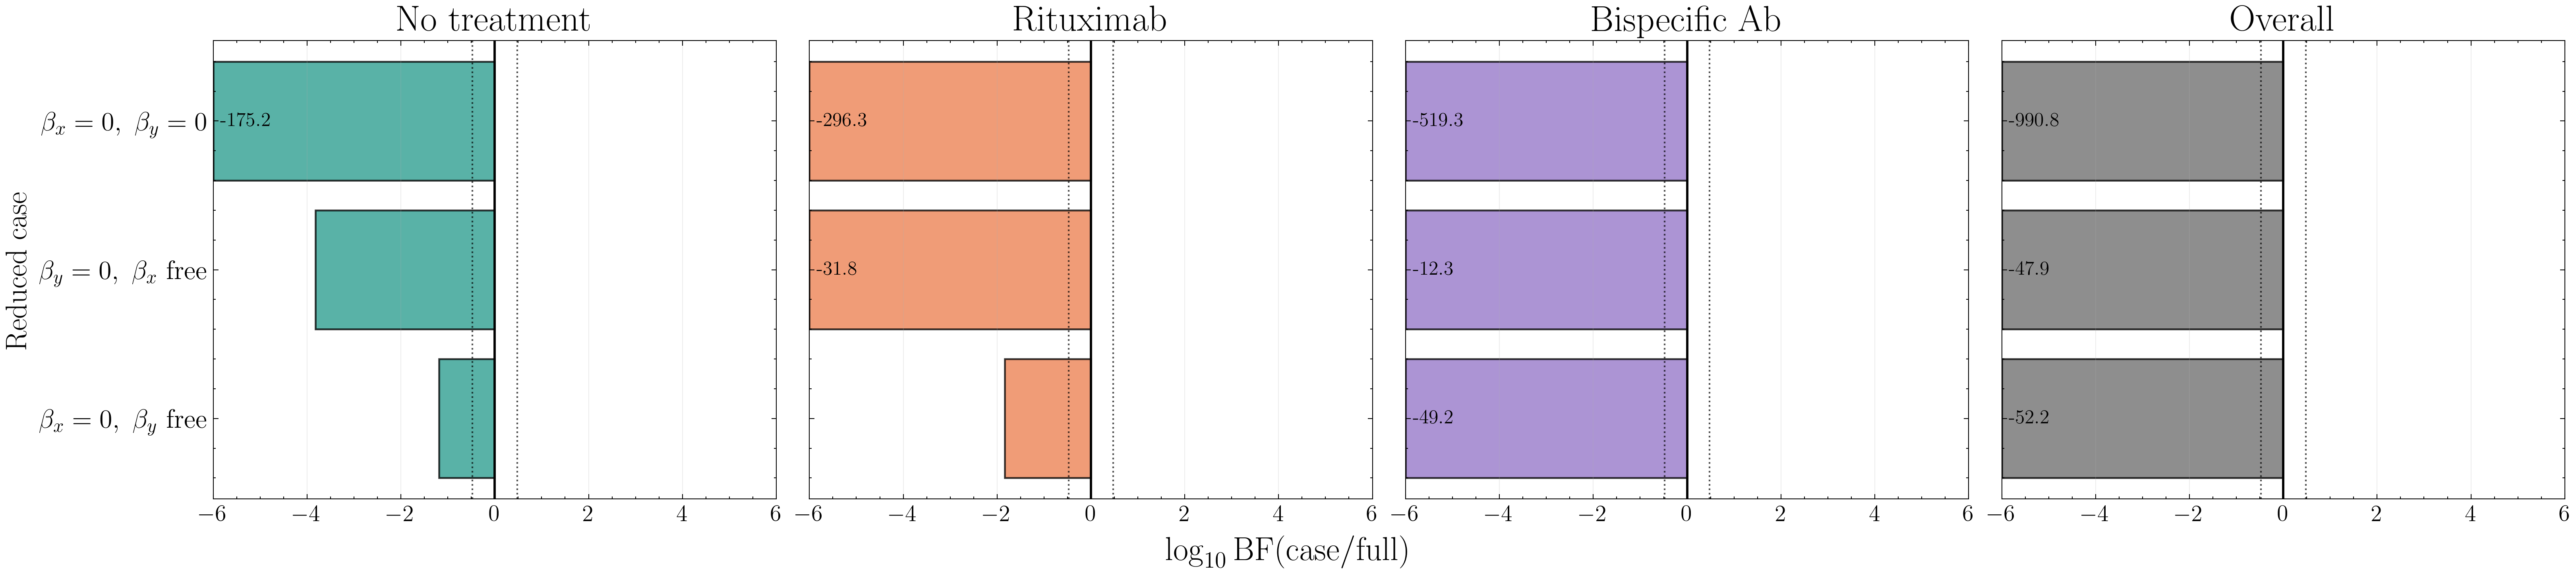

,condition,case_label,log10_case_vs_full_BF,log10_full_vs_case_BF
0,No treatment,"$\beta_x=0,\ \beta_y$ free",-1.187,1.187
1,No treatment,"$\beta_y=0,\ \beta_x$ free",-3.818,3.818
2,No treatment,"$\beta_x=0,\ \beta_y=0$",-175.152,175.152
3,Rituximab,"$\beta_x=0,\ \beta_y$ free",-1.838,1.838
4,Rituximab,"$\beta_y=0,\ \beta_x$ free",-31.830,31.830
5,Rituximab,"$\beta_x=0,\ \beta_y=0$",-296.320,296.320
6,Bispecific Ab,"$\beta_x=0,\ \beta_y$ free",-49.223,49.223
7,Bispecific Ab,"$\beta_y=0,\ \beta_x$ free",-12.263,12.263
8,Bispecific Ab,"$\beta_x=0,\ \beta_y=0$",-519.288,519.288
9,Overall,"$\beta_x=0,\ \beta_y$ free",-52.249,52.249


PosixPath('/Users/marsian/PhD_LifeSciRes/Orca/section_4/figures/analysis_1/history_effect_savage_dickey_log_bfs_with_overall.svg')

In [15]:
from scipy.stats import gaussian_kde, norm


CASE_ORDER = ["beta_x_zero", "beta_y_zero", "both_zero"]

CASE_LABELS = {
    "beta_x_zero": r"$\beta_x=0,\ \beta_y$ free",
    "beta_y_zero": r"$\beta_y=0,\ \beta_x$ free",
    "both_zero": r"$\beta_x=0,\ \beta_y=0$",
}


def _posterior_samples(idata: az.InferenceData, var_name: str) -> np.ndarray:
    values = (
        idata.posterior[var_name]
        .stack(sample=("chain", "draw"))
        .values
        .ravel()
        .astype(float)
    )
    return values[np.isfinite(values)]


def _paired_posterior_samples(
    idata: az.InferenceData,
    x_name: str,
    y_name: str,
) -> tuple[np.ndarray, np.ndarray]:
    x = _posterior_samples(idata, x_name)
    y = _posterior_samples(idata, y_name)
    n = min(len(x), len(y))
    x = x[:n]
    y = y[:n]
    keep = np.isfinite(x) & np.isfinite(y)
    return x[keep], y[keep]


def _kde_log_density_1d(samples: np.ndarray, ref: float = 0.0) -> float:
    samples = np.asarray(samples, dtype=float)
    samples = samples[np.isfinite(samples)]

    if samples.size < 3 or np.std(samples) == 0:
        return np.nan

    kde = gaussian_kde(samples)

    if hasattr(kde, "logpdf"):
        return float(kde.logpdf([ref])[0])

    density = float(kde([ref])[0])
    return float(np.log(density)) if density > 0 else -np.inf


def _kde_log_density_2d(x: np.ndarray, y: np.ndarray, ref: tuple[float, float] = (0.0, 0.0)) -> float:
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    keep = np.isfinite(x) & np.isfinite(y)
    x = x[keep]
    y = y[keep]

    if x.size < 4 or np.std(x) == 0 or np.std(y) == 0:
        return np.nan

    kde = gaussian_kde(np.vstack([x, y]))
    point = np.array([[ref[0]], [ref[1]]], dtype=float)

    if hasattr(kde, "logpdf"):
        return float(kde.logpdf(point)[0])

    density = float(kde(point)[0])
    return float(np.log(density)) if density > 0 else -np.inf


def history_effect_savage_dickey_log_bfs(
    posterior_data: dict,
    *,
    model_name: str = FULL_MODEL,
    conditions: Sequence[str] = CONDITION_ORDER,
    beta_prior_sd: float = 1.0,
) -> pd.DataFrame:
    rows = []

    log_prior_beta0 = float(norm.logpdf(0.0, loc=0.0, scale=beta_prior_sd))
    log_prior_both0 = 2.0 * log_prior_beta0

    for condition in conditions:
        key = (condition, model_name)

        if key not in posterior_data:
            continue

        idata = posterior_data[key]

        beta_x = _posterior_samples(idata, "beta_x")
        beta_y = _posterior_samples(idata, "beta_y")
        beta_x_pair, beta_y_pair = _paired_posterior_samples(idata, "beta_x", "beta_y")

        case_specs = [
            ("beta_x_zero", _kde_log_density_1d(beta_x, 0.0), log_prior_beta0),
            ("beta_y_zero", _kde_log_density_1d(beta_y, 0.0), log_prior_beta0),
            ("both_zero", _kde_log_density_2d(beta_x_pair, beta_y_pair, (0.0, 0.0)), log_prior_both0),
        ]

        for case, log_post_density, log_prior_density in case_specs:
            log10_case_vs_full = (log_post_density - log_prior_density) / np.log(10.0)

            rows.append(
                {
                    "condition": condition,
                    "case": case,
                    "case_label": CASE_LABELS[case],
                    "posterior_log_density_at_null": log_post_density,
                    "prior_log_density_at_null": log_prior_density,
                    "log10_case_vs_full_BF": log10_case_vs_full,
                    "log10_full_vs_case_BF": -log10_case_vs_full,
                }
            )

    return pd.DataFrame(rows)


def overall_history_effect_log_bfs(
    bf_df: pd.DataFrame,
    *,
    conditions: Sequence[str] = CONDITION_ORDER,
) -> pd.DataFrame:
    rows = []

    for case in CASE_ORDER:
        sub = bf_df[bf_df["case"] == case]

        rows.append(
            {
                "condition": "Overall",
                "case": case,
                "case_label": CASE_LABELS[case],
                "posterior_log_density_at_null": np.nan,
                "prior_log_density_at_null": np.nan,
                "log10_case_vs_full_BF": float(sub["log10_case_vs_full_BF"].sum()),
                "log10_full_vs_case_BF": float(sub["log10_full_vs_case_BF"].sum()),
            }
        )

    return pd.DataFrame(rows)


def plot_history_effect_savage_dickey_log_bfs(
    bf_df: pd.DataFrame,
    *,
    figure_root: Path = FIGURE_ROOT,
    conditions: Sequence[str] = CONDITION_ORDER,
    colors: dict[str, str] = CONDITION_COLORS,
    clip_log10_bf: float = 6.0,
    show: bool = False,
) -> tuple[Path | None, pd.DataFrame]:
    if bf_df.empty:
        return None, pd.DataFrame()

    overall_df = overall_history_effect_log_bfs(bf_df, conditions=conditions)
    plot_df = pd.concat([bf_df, overall_df], ignore_index=True)

    panels = list(conditions) + ["Overall"]

    fig, axes = plt.subplots(
        1,
        len(panels),
        figsize=(5.4 * len(panels), 4.8),
        dpi=300,
        sharex=True,
        sharey=True,
        constrained_layout=True,
    )
    axes = np.atleast_1d(axes)

    for ax, panel in zip(axes, panels):
        sub = (
            plot_df[plot_df["condition"] == panel]
            .set_index("case")
            .loc[CASE_ORDER]
            .reset_index()
        )

        raw_values = sub["log10_case_vs_full_BF"].to_numpy(dtype=float)
        shown_values = np.clip(raw_values, -clip_log10_bf, clip_log10_bf)
        y = np.arange(len(sub))

        color = colors.get(panel, "#6F6F6F")

        ax.barh(
            y,
            shown_values,
            color=color,
            alpha=0.78,
            edgecolor="black",
            linewidth=1.1,
        )

        for yi, raw, shown in zip(y, raw_values, shown_values):
            if np.isfinite(raw) and raw < -clip_log10_bf:
                ax.text(
                    -clip_log10_bf + 0.15,
                    yi,
                    f"{raw:.1f}",
                    va="center",
                    ha="left",
                    fontsize=12,
                    color="black",
                )
            elif np.isfinite(raw) and raw > clip_log10_bf:
                ax.text(
                    clip_log10_bf - 0.15,
                    yi,
                    f"{raw:.1f}",
                    va="center",
                    ha="right",
                    fontsize=12,
                    color="black",
                )

        ax.axvline(0, color="black", linewidth=1.4)
        ax.axvline(np.log10(3), color="black", linestyle=":", linewidth=1.0, alpha=0.7)
        ax.axvline(-np.log10(3), color="black", linestyle=":", linewidth=1.0, alpha=0.7)

        ax.set_title(panel, fontsize=22)
        ax.set_yticks(y)
        ax.set_yticklabels(sub["case_label"], fontsize=16)
        ax.invert_yaxis()
        ax.set_xlim(-clip_log10_bf, clip_log10_bf)
        ax.tick_params(axis="x", labelsize=14)
        ax.grid(axis="x", alpha=0.22)

    axes[0].set_ylabel("Reduced case", fontsize=18)

    fig.supxlabel(
        r"$\log_{10}\mathrm{BF}(\mathrm{case}/\mathrm{full})$",
        fontsize=20,
    )

    figure_root.mkdir(parents=True, exist_ok=True)
    out_path = figure_root / "history_effect_savage_dickey_log_bfs_with_overall.svg"
    fig.savefig(out_path, format="svg", bbox_inches="tight", transparent=True)

    if show:
        plt.show()
    else:
        plt.close(fig)

    return out_path, overall_df


history_bf_df = history_effect_savage_dickey_log_bfs(
    posterior_data,
    beta_prior_sd=1.0,
)

history_bf_path, history_bf_overall_df = plot_history_effect_savage_dickey_log_bfs(
    history_bf_df,
    clip_log10_bf=6.0,
    show=True,
)

history_bf_display = pd.concat([history_bf_df, history_bf_overall_df], ignore_index=True)

display(
    history_bf_display[
        [
            "condition",
            "case_label",
            "log10_case_vs_full_BF",
            "log10_full_vs_case_BF",
        ]
    ].round(3)
)

history_bf_path